# 08 — Designing the activation experiment REES46 cannot contain

07 ended on a randomised dataset and a sentence: *risk targeting captured 1.0% of the
achievable effect against random's 49.8%*. That result is only useful if it changes what
gets built next. This notebook is what gets built next.

It specifies, end to end, a randomised test of a second-purchase activation nudge at this
retailer: who enters, when they enter, how they are assigned, what is measured, what the
effect would have to be to pay for itself, how many users that needs, and how many weeks
of trading that is. Every threat the previous eight notebooks turned up is named here with
the handling it forces.

**Nothing below is measured.** The population sizes, base rates, inflow rate and guardrail
baselines are real and come from the REES46 data. The treatment effect does not exist,
because the treatment does not exist. Section 1 states this in the terms principle 10
requires, and the rest of the notebook is written so that no number can be mistaken for a
result.

In [1]:
import os, sys, json, math, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from scipy import stats

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

from src.plotting import frame, add_title, add_takeaway, save, show_df, thousands

SEED = 42
np.random.seed(SEED)
TABLES_DIR    = os.path.join("outputs", "tables")
FIG_DIR       = os.path.join("outputs", "figures")
PROCESSED_DIR = os.path.join("data", "processed")
for d in (TABLES_DIR, FIG_DIR, PROCESSED_DIR):
    os.makedirs(d, exist_ok=True)

with open(os.path.join("outputs", "handoff_params.json")) as fh:
    handoff = json.load(fh)

CHURN = handoff["churn_definition"]
SEG   = handoff["segmentation"]
FEAT  = handoff["features"]
MOD   = handoff["modelling"]
CRX   = handoff["criteo_experiment"]
RET   = handoff["retention_measured"]
COMP  = handoff["compounding_vs_selection"]
ROWS  = handoff["row_counts"]
SPAN  = handoff["data_date_range"]

print("INHERITED FROM handoff_params.json -- NOT RE-DERIVED")
print("=" * 100)
print(f"  certified churn threshold   : {CHURN['certified_threshold_days']}d  "
      f"(region {CHURN['certified_region_days']}, recall {CHURN['validation']['specB']['recall_pct']}%)")
print(f"  primary horizon / target    : {FEAT['target_naming'].split('.')[0]}  "
      f"base rate {FEAT['positive_rate_pct']['d30']}%  eligible n={FEAT['eligible_n']['d30']:,}")
print(f"  06 shipped model            : test AP {MOD['shipped_model']['test_AP']}  "
      f"ROC {MOD['shipped_model']['test_ROC_AUC']}  decile-1 lift {MOD['shipped_model']['decile1_lift']}x")
print(f"  06 base-rate drift          : {MOD['population']['base_rate_drift_pp']:.4f} pp across the window")
print(f"  04 segment durability       : kappa {SEG['stability']['cohens_kappa']}  "
      f"same-cluster {SEG['stability']['same_cluster_pct']}%")
print(f"  02 compounding residual     : {COMP['slowest_bucket_ratio_vs_baseline']}x  "
      f"(verdict: {COMP['verdict']})")
print(f"  07 risk-targeting result    : risk 1.0% vs random 49.8% of the achievable effect")
print(f"  data span                   : {SPAN['min']} -> {SPAN['max']}  ({SPAN['span_days']} days)")

INHERITED FROM handoff_params.json -- NOT RE-DERIVED
  certified churn threshold   : 42.2d  (region [30.0, 45.0], recall 53.09%)
  primary horizon / target    : repeat_purchase_{h}d  base rate 13.73%  eligible n=91,334
  06 shipped model            : test AP 0.1809  ROC 0.6278  decile-1 lift 1.882x
  06 base-rate drift          : 2.9665 pp across the window
  04 segment durability       : kappa 0.309  same-cluster 56.9%
  02 compounding residual     : 1.27x  (verdict: selection-dominated)
  07 risk-targeting result    : risk 1.0% vs random 49.8% of the achievable effect
  data span                   : 2019-10-01 00:00:00 -> 2020-02-29 23:59:59  (151 days)


## 1. This is a DESIGN, not a result

Principle 10 of the project brief: *REES46 has no randomised experiment. Never call it an
A/B test.* That is not a stylistic preference, it is the only defensible reading of the
data. The five monthly REES46 files are an observational event log. No user in them was
randomly assigned to anything. There is no treatment column, no holdout, no assignment
mechanism, and therefore no treatment effect to estimate.

**What this notebook contains.** A complete experiment specification — population, trigger,
unit, assignment mechanism, estimand, primary metric, guardrails, sample size, duration,
analysis plan, decision rule and threat handling — written so that an engineering and CRM
team could execute it without asking a follow-up question.

**What this notebook does not contain, and will not contain.** Any estimate of what the
intervention would do. There is no effect size in this notebook that is presented as a
measurement of the nudge, because none can exist. Where a number is needed to size the
experiment — a contact cost, a contribution margin — it is labelled `ASSUMPTION` and shown
separately from anything the data supports.

**What is real here.** Every population count, base rate, inflow rate, guardrail baseline,
covariate balance statistic and drift figure is computed from REES46 and is a genuine
measurement of the retailer as observed. The assignment mechanism is executed against the
real 74,548 user ids that would have entered, and its balance is checked. That part is not
hypothetical — it proves the randomiser works before anyone trusts it with a budget.

The line between the two is drawn mechanically. Section 6 registers every input to the
economics in a provenance table with a `DATA` or `ASSUMPTION` tag, and Section 10 asserts
that every input carries one and that no input traces back to Criteo.

> **One more distinction that matters.** 07 is a real randomised experiment, and this
> notebook inherits its *structure* — the estimand, the exposure trap, the risk-vs-uplift
> result. It inherits none of its *magnitudes*. Criteo is display advertising on a
> multi-day window; this is cosmetics repeat purchase on a 30-day window, and 07's own
> §3C attaches a ±25% bias band to every Criteo effect size. Section 6 derives the
> detectable effect from the retailer's economics and Section 10 asserts it mechanically.

## 2. The constraints this design has to satisfy

Eight notebooks produced findings that constrain what can honestly be proposed. Five are
binding rules 07 recorded for 08 in `handoff_params.json` — the brief names four, and the
fifth, on powering a pre-specified check for negative effects, is in the handoff and is
discharged here too. The rest come from 02, 03, 04, 05 and 06. Every one is restated below
with the design decision it forces, and every one is discharged somewhere in this notebook.

In [2]:
CONSTRAINTS = [
    # ---- the four 07 recorded for 08 -------------------------------------------------
    dict(src="07", constraint=CRX["carry_back_to_rees46"]["binding_rules_for_08"][0],
         handled_in="S3E, S4",
         design_response="Treatment group is selected by a hash of user_id, not by any score. "
                         "06's score enters only as a blocking variable (S4C) and as a "
                         "pre-registered exploratory subgroup (S7)."),
    dict(src="07", constraint=CRX["carry_back_to_rees46"]["binding_rules_for_08"][1],
         handled_in="S5A",
         design_response="Primary estimand is ITT by randomised assignment. Delivery, open and "
                         "click are post-randomisation and are logged as operational diagnostics "
                         "only; no arm comparison conditions on them."),
    dict(src="07", constraint=CRX["carry_back_to_rees46"]["binding_rules_for_08"][2],
         handled_in="S6D, S7",
         design_response="Sample size is solved on the number of repeat-purchase EVENTS the "
                         "design buys, not on headcount. The chosen size yields ~1,543 events "
                         "per arm, ~3,086 across both, against the ~330k 07 measured as "
                         "necessary for a reliable uplift ranking."),
    dict(src="07", constraint=CRX["carry_back_to_rees46"]["binding_rules_for_08"][3],
         handled_in="S1, S7",
         design_response="The design promises an ATE and says so. The heterogeneity readout is "
                         "labelled exploratory with its own MDE (1.76 pp per tercile) printed "
                         "next to it."),
    dict(src="07", constraint=CRX["carry_back_to_rees46"]["binding_rules_for_08"][4],
         handled_in="S5C, S8F",
         design_response="A pre-specified harm check: opt-out/unsubscribe and support contacts "
                         "are one-sided guardrails with stopping thresholds, and the heterogeneity "
                         "readout reports negative cells rather than suppressing them."),
    # ---- population and trigger ------------------------------------------------------
    dict(src="03", constraint="Churn here is FIRST-PURCHASE churn: 87.8% of flagged users have "
                              "exactly one order. This is an activation problem, not a win-back one.",
         handled_in="S3A",
         design_response="The intervention is a second-order activation nudge. Nothing in the "
                         "design attempts to reactivate a lapsed multi-order customer."),
    dict(src="03", constraint="D30 cannot carry a churn label and the certified 42.2d rule flags "
                              "nobody before day 42.2, by which point most of the repeat window "
                              "has passed.",
         handled_in="S3B, S3C",
         design_response="The trigger is TIME SINCE FIRST ORDER (day 14), not the churn flag. "
                         "This sidesteps the unidentified threshold and the 53% recall entirely: "
                         "neither quantity appears anywhere in the enrolment rule."),
    dict(src="04", constraint="Cell B3 (tenure <= 30d, engaged, n=7,741) is the profile inside the "
                              "open window; B1 is reached ~109 days too late.",
         handled_in="S3D",
         design_response="The day-14 trigger population is the B3 profile generalised: every "
                         "enrollee is 14 days past a first order, well inside B3's tenure band and "
                         "95 days ahead of B1's median recency."),
    dict(src="04/05", constraint="Segment labels are not durable (kappa 0.309) and segment_model.json "
                                 "is degenerate in a pre-first-order window.",
         handled_in="S3E",
         design_response="No stored segment is used to target or to stratify. Blocking uses "
                         "acquisition month and 06's score, both re-computed at trigger time."),
    # ---- what not to do --------------------------------------------------------------
    dict(src="06/07", constraint="Do not target on 06's risk score: risk targeting captured 1.0% of "
                                 "the achievable effect against random's 49.8%.",
         handled_in="S3E, S4",
         design_response="The score does not enter the enrolment rule or the assignment rule. "
                         "Enrolment is by trigger; assignment is by hash."),
    dict(src="07", constraint="The sign of heterogeneity may INVERT from Criteo's, because retention "
                              "persuadables plausibly sit mid-propensity rather than high.",
         handled_in="S7",
         design_response="The tercile readout is pre-registered as two-sided with no predicted "
                         "direction, and the pre-registration records that a mid-tercile peak and "
                         "a monotone rise are both admissible outcomes."),
    dict(src="07", constraint="Do not use Criteo effect sizes to set the MDE (transfer caveat plus a "
                              "+/-25% adjustment bias band).",
         handled_in="S6, S10",
         design_response="The MDE is solved from contact cost, contribution margin and AOV. S10 "
                         "asserts mechanically that no registered economic input names Criteo."),
    # ---- value of the outcome --------------------------------------------------------
    dict(src="02", constraint="Compounding vs selection: an engineered 2nd purchase does not inherit "
                              "the naive ~2x downstream repeat rate. The residual is 1.27x.",
         handled_in="S6B",
         design_response="The value of one incremental second order is margin on that order plus a "
                         "downstream term built on the 1.27x residual (+4.00 pp), not on 2.00x "
                         "(+14.84 pp). The naive figure would overstate the downstream term 3.7x."),
    # ---- threats ---------------------------------------------------------------------
    dict(src="06", constraint="Base rate drifts 17.2% (Oct) -> 10.1% (Dec), partly the Black Friday "
                              "cohort. Pre/post comparison is invalid.",
         handled_in="S8A",
         design_response="Concurrent control, blocked on acquisition month. S8A measures the drift "
                         "again on the trigger population, where it is larger: 14.73% -> 6.98%."),
    dict(src="00/03", constraint="user_id is cookie-scoped. A treated user returning on a new device "
                                 "looks like an untreated new user.",
         handled_in="S8B",
         design_response="Stated with its direction: the bias is toward the null, so the measured "
                         "ITT is a conservative lower bound on the true per-person effect."),
]
CON = pd.DataFrame(CONSTRAINTS)
print(f"{len(CON)} inherited constraints, {CON.src.nunique()} source notebooks\n")
for _, r in CON.iterrows():
    print(f"[{r.src:>6}] -> {r.handled_in}")
    print(f"         CONSTRAINT: {r.constraint}")
    print(f"         DESIGN    : {r.design_response}\n")
show_df(CON, "nb08_inherited_constraints", max_rows=0)
print(f"\npersisted -> {TABLES_DIR}/nb08_inherited_constraints.csv")

15 inherited constraints, 8 source notebooks

[    07] -> S3E, S4
         CONSTRAINT: 08 IS A DESIGN, NOT A TARGETING RULE. Do not select the treatment group with 06's scores. Use the score for stratification and pre-specified subgroups only.
         DESIGN    : Treatment group is selected by a hash of user_id, not by any score. 06's score enters only as a blocking variable (S4C) and as a pre-registered exploratory subgroup (S7).

[    07] -> S5A
         CONSTRAINT: Pre-specify ITT by randomised assignment as the primary estimand. Open-conditional or click-conditional analysis is the exposure error of S4 and is exploratory at best.
         DESIGN    : Primary estimand is ITT by randomised assignment. Delivery, open and click are post-randomisation and are logged as operational diagnostics only; no arm comparison conditions on them.

[    07] -> S6D, S7
         CONSTRAINT: Power on EVENT count, not user count. S6E: the response ranking stabilised by ~10k events; the uplift learners

## 3. Population and trigger

### 3A — What kind of problem this is

03 established that churn at this retailer is first-purchase churn: 87.8% of the users the
certified rule flags have exactly one order, against 80% of the base. 04 carried that
forward — its at-risk cells are activation cells. 05 confirmed it structurally: purchase
cadence is *undefined* at a first-order anchor because every user has exactly one order
there, so 100% of the population has no purchase rhythm to lapse from.

There is nothing to win back. The intervention has to manufacture a second order that would
not otherwise happen, from a user who has bought exactly once.

That fixes the population: **users with exactly one order.** It does not yet fix when to
contact them, which is the harder question and the next three subsections.

### 3B — Why the certified churn rule cannot be the trigger

The obvious design is to wait for 03's certified churn flag and contact whoever it flags.
It does not work, and the reason is arithmetic rather than judgement.

The certified rule fires at **42.2 days of purchase silence**. A first-time buyer therefore
cannot be flagged before day 42.2 after their first order. The primary repeat-purchase
window this project has certified is **30 days** (`repeat_purchase_30d`, base rate 13.73%).
Day 42.2 is 12.2 days past the far edge of that window. By the time the rule speaks, the
question it was asked has already been answered.

Two further problems, both recorded in the handoff:

1. **The threshold is not identified.** 03 §9D: 42.2d is the centre of a 30–45d region, the
   J-optimal cut drifts 43.5d → 29.4d as the flag date moves 21 days, and P75 wins only for
   a cost-asymmetry weight in [0.475, 0.525]. It is an operating value, not a property of
   the customers. Building an enrolment rule on it would import that instability into the
   experiment's population definition.
2. **It sees half the problem.** Recall is 53.09%. All 28,986 missed at-risk users sit
   *below* 42.2 days of recency, median 23.7d. A campaign sized off the flagged count
   understates the at-risk base by 41%.

**The design decision.** The trigger is *time since first order* — a clock, not a
classifier. This sidesteps both problems completely rather than mitigating them: an
enrolment rule that says "14 days after your first order, if you have not bought again"
does not reference the 42.2d threshold, does not inherit its 30–45d uncertainty, and has no
recall to correct for, because it is not trying to detect anything. Every first-time buyer
who has not repeated by day 14 enters, by construction, with 100% coverage of that
definition.

The price of this is that the trigger cannot prioritise. It reaches everyone at day 14
rather than the people most at risk. 07 is the reason that price is worth paying: risk
priority captured 1.0% of the achievable effect. There is nothing to give up.

### 3C — Choosing the trigger day from the data

The trigger day trades two things against each other and both are measurable.

**Contact too early** and most of the budget lands on users who were about to buy anyway.
These are the people with the highest baseline propensity, which 07 showed is not the same
as the highest uplift, and a contact spent on a user who converts regardless is a contact
wasted.

**Contact too late** and the outcome mass is gone. The retention curve is steep early:
02 measured D7 purchase retention at 5.29% and D30 at 14.08%, so more than a third of the
30-day repeat volume has already happened by day 7.

The sweep below measures both sides on the real data. For each candidate trigger day T, it
takes every user with at least T + 30 days of trailing observation who had not placed a
second order by day T — the users the rule would actually enrol — and measures how many of
them place one in the following 30 days. That conditional rate is the base rate the
experiment would be powered against.

In [3]:
FEAT_PATH = os.path.join(PROCESSED_DIR, "features.parquet")
F = pd.read_parquet(FEAT_PATH)
F["t0"] = pd.to_datetime(F["first_ts"])
DATA_END = pd.Timestamp(SPAN["max"])

OUTCOME_H = 30.0   # days; matches 05/06's repeat_purchase_30d, the certified primary horizon

def trigger_pool(T, H=OUTCOME_H, frame_=None):
    '''Users the rule would enrol at day T, and whether they repeat in the next H days.

    Enrolment condition, evaluated on REES46 as if the rule had been running:
      - observable for the whole window:  trailing_days >= T + H  (never zero-fill a
        censored user -- 05's eligibility rule, applied at the new anchor)
      - still eligible at the trigger:    no second order by day T
    '''
    f = F if frame_ is None else frame_
    obs  = f["trailing_days"] >= (T + H)
    open_ = f["days_to_next_order"].isna() | (f["days_to_next_order"] > T)
    pool = f[obs & open_].copy()
    pool["y"] = ((pool["days_to_next_order"] > T) &
                 (pool["days_to_next_order"] <= T + H)).astype(int)
    return pool

SWEEP = []
for T in [0.0, 3.0, 7.0, 10.0, 14.0, 21.0, 28.0, 30.0, CHURN["certified_threshold_days"]]:
    obs_n = int((F["trailing_days"] >= (T + OUTCOME_H)).sum())
    pool  = trigger_pool(T)
    # share of the cohort's eventual 30-day-from-t0 repeaters that have ALREADY bought by T
    el30 = F[F["trailing_days"] >= OUTCOME_H]
    rep30 = el30[el30["repeat_purchase_30d"].astype(bool)]
    SWEEP.append(dict(
        trigger_day=T,
        n_observable=obs_n,
        n_enrolled=len(pool),
        enrolled_share_pct=round(100 * len(pool) / obs_n, 2),
        base_rate_next30_pct=round(100 * pool["y"].mean(), 3),
        n_events_next30=int(pool["y"].sum()),
        d30_repeaters_already_bought_pct=round(100 * float((rep30["days_to_next_order"] <= T).mean()), 2),
    ))
SWEEP = pd.DataFrame(SWEEP)
show_df(SWEEP, "nb08_trigger_sweep", max_rows=20)

   trigger_day  n_observable  n_enrolled  enrolled_share_pct  base_rate_next30_pct  n_events_next30  d30_repeaters_already_bought_pct
0          0.0         91334       91334              100.00                13.730            12540                              0.00
1          3.0         88909       85907               96.62                11.812            10147                             24.57
2          7.0         85978       81447               94.73                11.312             9213                             38.52
3         10.0         83784       78246               93.39                10.803             8453                             48.00
4         14.0         81314       74548               91.68                10.248             7640                             60.14
5         21.0         76308       67933               89.02                 9.374             6368                             78.64
6         28.0         72364       62675               86.61  

,trigger_day,n_observable,n_enrolled,enrolled_share_pct,base_rate_next30_pct,n_events_next30,d30_repeaters_already_bought_pct
0,0.0,91334,91334,100.00,13.730,12540,0.00
1,3.0,88909,85907,96.62,11.812,10147,24.57
2,7.0,85978,81447,94.73,11.312,9213,38.52
3,10.0,83784,78246,93.39,10.803,8453,48.00
4,14.0,81314,74548,91.68,10.248,7640,60.14
5,21.0,76308,67933,89.02,9.374,6368,78.64
6,28.0,72364,62675,86.61,8.444,5292,95.18
7,30.0,71727,61629,85.92,8.144,5019,100.00
8,42.2,65258,53406,81.84,6.649,3551,100.00


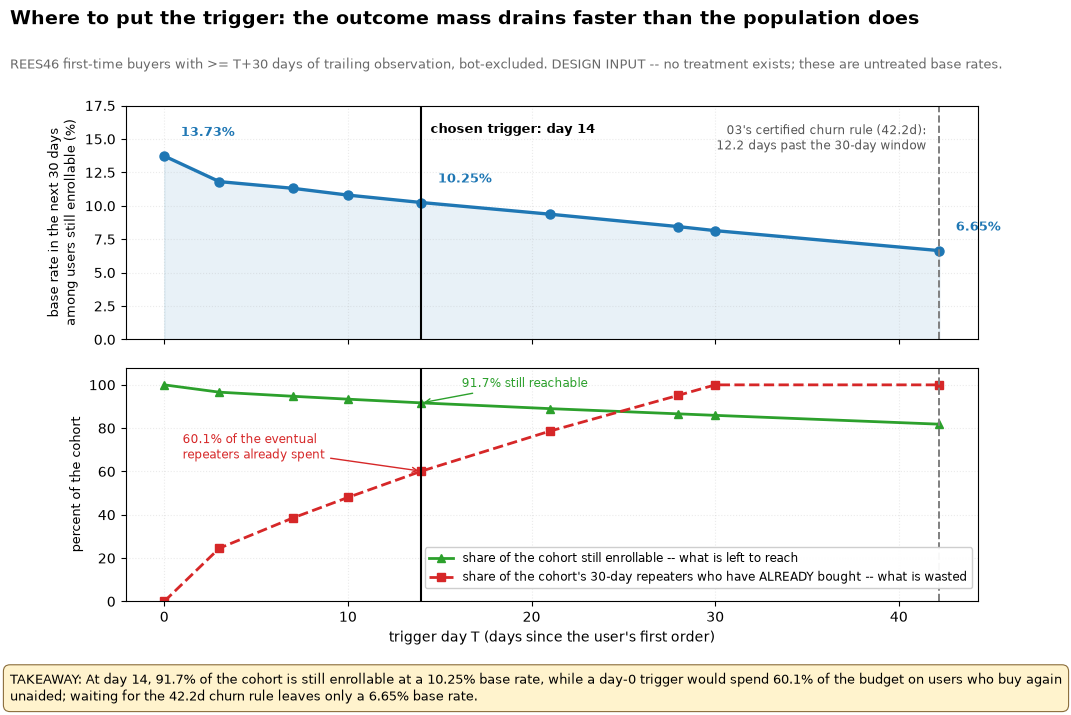

In [4]:
s = SWEEP[SWEEP.trigger_day <= 45]
CHOSEN_T = 14.0
K42 = CHURN["certified_threshold_days"]

fig, (axA, axB) = plt.subplots(2, 1, figsize=(11, 7.4), sharex=True,
                               gridspec_kw=dict(height_ratios=[1.0, 1.0], hspace=0.12))
fig.subplots_adjust(top=0.84, bottom=0.17)

axA.plot(s.trigger_day, s.base_rate_next30_pct, "o-", color="#1f77b4", lw=2.4, ms=6.5)
axA.fill_between(s.trigger_day, 0, s.base_rate_next30_pct, color="#1f77b4", alpha=0.10)
for T in [0.0, CHOSEN_T, K42]:
    r = s[s.trigger_day == T].iloc[0]
    axA.annotate(f"{r.base_rate_next30_pct:.2f}%", xy=(T, r.base_rate_next30_pct),
                 xytext=(T + 0.9, r.base_rate_next30_pct + 1.5), fontsize=9.2, color="#1f77b4",
                 fontweight="bold")
axA.set_ylabel("base rate in the next 30 days\namong users still enrollable (%)", fontsize=9.5)
axA.set_ylim(0, 17.5)
axA.grid(alpha=0.25, ls=":")

axB.plot(s.trigger_day, s.enrolled_share_pct, "^-", color="#2ca02c", lw=2.0, ms=6,
         label="share of the cohort still enrollable -- what is left to reach")
axB.plot(s.trigger_day, s.d30_repeaters_already_bought_pct, "s--", color="#d62728", lw=2.0, ms=5.5,
         label="share of the cohort's 30-day repeaters who have ALREADY bought -- what is wasted")
axB.set_ylabel("percent of the cohort", fontsize=9.5)
axB.set_ylim(0, 108)
axB.set_xlabel("trigger day T (days since the user's first order)")
axB.grid(alpha=0.25, ls=":")
axB.legend(fontsize=8.5, loc="lower right", framealpha=0.95, bbox_to_anchor=(1.0, 0.03))

for ax_ in (axA, axB):
    ax_.axvline(CHOSEN_T, color="black", lw=1.5)
    ax_.axvline(K42, color="#7f7f7f", lw=1.4, ls="--")
axA.text(CHOSEN_T + 0.5, 16.2, "chosen trigger: day 14", fontsize=9.4, fontweight="bold", va="top")
axA.text(K42 - 0.7, 16.2, "03's certified churn rule (42.2d):\n12.2 days past the 30-day window",
         fontsize=8.6, color="#555555", va="top", ha="right")
r14 = s[s.trigger_day == CHOSEN_T].iloc[0]
axB.annotate(f"{r14.enrolled_share_pct:.1f}% still reachable", xy=(CHOSEN_T, r14.enrolled_share_pct),
             xytext=(CHOSEN_T + 2.2, 99), fontsize=8.8, color="#2ca02c",
             arrowprops=dict(arrowstyle="->", lw=1.0, color="#2ca02c"))
axB.annotate(f"{r14.d30_repeaters_already_bought_pct:.1f}% of the eventual\nrepeaters already spent",
             xy=(CHOSEN_T, r14.d30_repeaters_already_bought_pct),
             xytext=(CHOSEN_T - 13.0, 66), fontsize=8.8, color="#d62728",
             arrowprops=dict(arrowstyle="->", lw=1.0, color="#d62728"))

add_title(fig, "Where to put the trigger: the outcome mass drains faster than the population does",
          "REES46 first-time buyers with >= T+30 days of trailing observation, bot-excluded. "
          "DESIGN INPUT -- no treatment exists; these are untreated base rates.")
add_takeaway(fig, "At day 14, 91.7% of the cohort is still enrollable at a 10.25% base rate, while a "
                  "day-0 trigger would spend 60.1% of the budget on users who buy again unaided; waiting "
                  "for the 42.2d churn rule leaves only a 6.65% base rate.")
save(fig, "nb08_trigger_selection")
plt.show()

In [5]:
TRIGGER_DAYS = 14.0
POOL = trigger_pool(TRIGGER_DAYS)
BASE_RATE = float(POOL["y"].mean())

row14 = SWEEP[SWEEP.trigger_day == TRIGGER_DAYS].iloc[0]
row0  = SWEEP[SWEEP.trigger_day == 0.0].iloc[0]
row42 = SWEEP[SWEEP.trigger_day == CHURN["certified_threshold_days"]].iloc[0]

print("TRIGGER DEFINITION")
print("=" * 100)
print(f"  Rule      : {TRIGGER_DAYS:.0f} days after a user's FIRST order, if no second order has been placed,")
print(f"              the user is enrolled. Evaluated once per user; a user can enter at most once.")
print(f"  Clock     : starts at t0 = first order timestamp, certified reconstruction rule")
print(f"              (GROUP BY user_id, user_session, event_time on purchase rows).")
print(f"  No churn flag, no propensity score, no segment label appears in this rule.")
print()
print("WHAT THE RULE CATCHES, ON REES46 AS OBSERVED")
print("=" * 100)
print(f"  enrollable historical analogue : {len(POOL):,} users")
print(f"  share of the observable cohort : {row14.enrolled_share_pct:.2f}%")
print(f"  base rate, next 30 days        : {100*BASE_RATE:.3f}%   ({int(POOL['y'].sum()):,} repeat events)")
print()
print("THE TWO ALTERNATIVES, PRICED")
print("=" * 100)
print(f"  trigger at day 0  : base rate {row0.base_rate_next30_pct:.3f}%, but "
      f"{row14.d30_repeaters_already_bought_pct:.1f}% of the eventual 30-day repeaters")
print(f"                      have already bought by day 14 -- at day 0 that whole group is paid for and")
print(f"                      converts regardless.")
print(f"  trigger at 42.2d  : base rate {row42.base_rate_next30_pct:.3f}%, {row42.enrolled_share_pct:.1f}% still enrollable.")
print(f"                      Costs {100*BASE_RATE - row42.base_rate_next30_pct:.2f} pp of outcome mass to wait,")
print(f"                      and buys an unidentified threshold in exchange for it.")

TRIGGER DEFINITION
  Rule      : 14 days after a user's FIRST order, if no second order has been placed,
              the user is enrolled. Evaluated once per user; a user can enter at most once.
  Clock     : starts at t0 = first order timestamp, certified reconstruction rule
              (GROUP BY user_id, user_session, event_time on purchase rows).
  No churn flag, no propensity score, no segment label appears in this rule.

WHAT THE RULE CATCHES, ON REES46 AS OBSERVED
  enrollable historical analogue : 74,548 users
  share of the observable cohort : 91.68%
  base rate, next 30 days        : 10.248%   (7,640 repeat events)

THE TWO ALTERNATIVES, PRICED
  trigger at day 0  : base rate 13.730%, but 60.1% of the eventual 30-day repeaters
                      have already bought by day 14 -- at day 0 that whole group is paid for and
                      converts regardless.
  trigger at 42.2d  : base rate 6.649%, 81.8% still enrollable.
                      Costs 3.60 pp of outcome

### 3D — Reconciling with 04's cell B3

04 §9C did the work that makes this population choice non-arbitrary, and it did it by
withdrawing its own earlier claim. Cell B1 — 10,982 users, low RFM but the most-engaged
behavioural segment — looked like the obvious retention target: engaged browsers written
off by a recency score. §9C matched B1 against other Broad Deliberators on tenure and the
engagement gap did not close; it **widened** on four of five metrics, and per tenure-day B1
browses at 0.43× their rate. B1 is not dormant engagement waiting to be revived. It is a
one-order population with a median recency of 109 days: activation, reached about 109 days
too late.

04's own conclusion was to design on **B3** instead — 7,741 users, tenure ≤ 30d, engaged
behaviour, median recency 15.4 days — where the window is still open.

The day-14 trigger is B3's defining property turned into an operating rule. B3 was a
snapshot cell: the users who happened to be within 30 days of a first order on
2020-02-29. A trigger produces that population continuously, for every cohort, without a
snapshot date. The check below confirms the day-14 pool sits inside B3's tenure band and
far ahead of B1's.

In [6]:
XT = SEG["cross_tab"]["disagreement_cells"]
b1, b3 = XT["B1"], XT["B3"]
pool_recency_at_trigger = TRIGGER_DAYS   # by construction: every enrollee is exactly 14d past t0

CELLCMP = pd.DataFrame([
    dict(population="04 cell B1 (low RFM x most-engaged)", n=b1["n"],
         median_recency_d=b1["R_median_d"], one_order_pct=b1["one_order_pct"],
         inside_30d_window="NO -- 109.1d past the last order",
         usable_as_08_target="No. 04 S9C: long tenure, not live engagement; ~109d too late."),
    dict(population="04 cell B3 (new x engaged)", n=b3["n"],
         median_recency_d=b3["R_median_d"], one_order_pct=b3["one_order_pct"],
         inside_30d_window="YES",
         usable_as_08_target="Yes -- 04's own recommendation. But it is a SNAPSHOT of one date."),
    dict(population=f"08 day-{TRIGGER_DAYS:.0f} trigger pool", n=len(POOL),
         median_recency_d=pool_recency_at_trigger, one_order_pct=100.0,
         inside_30d_window="YES -- by construction",
         usable_as_08_target="Yes. Same profile, produced continuously rather than as a snapshot."),
])
show_df(CELLCMP, "nb08_population_vs_04_cells", max_rows=10)

print()
print(f"B3 tenure band          : <= 30 days since first order (median {b3['R_median_d']}d)")
print(f"Day-14 trigger pool     : exactly {TRIGGER_DAYS:.0f} days since first order, for every enrollee")
print(f"                          -> inside B3's band by construction, with no snapshot date")
print(f"Scale                   : {len(POOL):,} historical analogues vs B3's snapshot {b3['n']:,}")
print(f"                          ({len(POOL)/b3['n']:.1f}x, because a trigger accumulates cohorts)")
print()
print(f"B1 is reached at median recency {b1['R_median_d']}d, i.e. "
      f"{b1['R_median_d'] - TRIGGER_DAYS:.0f} days after this trigger fires.")

                            population      n  median_recency_d  one_order_pct                 inside_30d_window  \
0  04 cell B1 (low RFM x most-engaged)  10982             109.1           99.5  NO -- 109.1d past the last order   
1           04 cell B3 (new x engaged)   7741              15.4           95.6                               YES   
2               08 day-14 trigger pool  74548              14.0          100.0            YES -- by construction   

                                 usable_as_08_target  
0  No. 04 S9C: long tenure, not live engagement; ...  
1  Yes -- 04's own recommendation. But it is a SN...  
2  Yes. Same profile, produced continuously rathe...  

B3 tenure band          : <= 30 days since first order (median 15.4d)
Day-14 trigger pool     : exactly 14 days since first order, for every enrollee
                          -> inside B3's band by construction, with no snapshot date
Scale                   : 74,548 historical analogues vs B3's snapshot 7,741
  

### 3E — What does *not* enter the enrolment rule, and why

Three quantities are conspicuously absent from the trigger definition. Each is absent
because a previous notebook showed that including it would be wrong.

**1. 06's risk score.** 07 §7 evaluated targeting the bottom 50% of baseline propensity —
exactly what pointing 06's model at its churn tail means — on real randomised data. It
captured **1.0%** of the achievable incremental effect against random targeting's **49.8%**,
a contrast whose CI excludes zero by a wide margin. The score is not merely uninformative
for targeting here; it is actively worse than picking at random. It does not select who is
treated. It appears twice in this design, both times in roles that do not require it to
rank uplift: as a **blocking variable** (S4C, variance reduction, which only needs it to
predict the outcome — and it does, at a 3.6× spread across terciles) and as a
**pre-registered exploratory subgroup** (S7).

**2. Stored segment labels.** 04's stability test: the cluster *structure* reproduces
(ARI 0.891) but *membership* does not — 56.9% of users stay in the same segment across two
months, Cohen's kappa 0.309 against a 37.6% chance rate, and an equal-length window control
reproduces it, so it is behaviour rather than an artefact. A campaign built on a stored
segment list misdirects roughly two users in five. Worse, 05 §6A found that
`segment_model.json` cannot even be applied faithfully at this anchor: one of its eight
fitted features, `cart_abandonment_rate`, is a constant 1.0 in any window containing no
purchase. Re-scoring at trigger time — 04's own instruction — is not available in the form
04 specified it. The design uses no segment label at all.

**3. The churn flag.** Covered in 3B: it fires 12.2 days past the outcome window, its
threshold is not identified, and its recall is 53%.

What is left is a clock and a hash. That is deliberate. Every component of this design that
*could* carry a modelling error has been removed from the part of it that decides who gets
contacted.

## 4. Unit, assignment and the A/A check

### 4A — Unit of randomisation

**The unit is the user.** Not the session, not the email send, not the order.

The alternative — randomising at the send level — would let the same user land in both arms
across two triggers and would make the ITT uninterpretable. It is ruled out anyway by the
enrolment rule: a user triggers at most once, because there is only one first order.

Session-level randomisation is ruled out for the same reason plus a stronger one: the
outcome is measured over 30 days and spans many sessions, so a session-level assignment does
not partition the outcome.

**Allocation is 50/50.** For a two-arm comparison of proportions at a fixed total sample,
the variance of the difference is minimised at equal allocation — any imbalance costs power.
Criteo's 85/15 exists because a commercial campaign pays for holdouts in forgone revenue;
here the treatment is an email whose per-unit cost is assumed at €0.05 and whose effect is
unknown in sign, so there is no revenue case for shrinking the control arm. 50/50 stands.

### 4B — Deterministic hash assignment, and a real trap in this data

Assignment is a pure function of the user id and a fixed experiment salt:

$$u(\text{user\_id}) = \frac{\text{int}\big(\text{sha256}(\texttt{salt} \Vert \text{user\_id})_{[0:16]}\big)}{2^{64}} \in [0,1)$$

with treatment assigned on $u < 0.5$ within each block (the blocked variant is in 4C). This
is standard practice and it is worth saying why each property is needed:

- **Deterministic**: re-running the assignment job gives the same answer, so a retry, a
  backfill or a replay cannot move a user between arms mid-experiment.
- **Stateless**: no assignment table to corrupt, and analysis can re-derive every arm label
  from the user id alone.
- **Salted**: a future experiment on the same population uses a different salt and gets an
  independent split, so this test does not contaminate the next one.

**The trap.** A cheaper-looking scheme is to split on the id itself — ids below the median
to treatment, above to control. In this dataset that is catastrophic, and the reason is
visible in the data: **REES46 user ids are substantially time-ordered** (Spearman ρ ≈ 0.48
between `user_id` and first-order timestamp). A range split on the id is therefore close to
a split on acquisition date — the one covariate 06 proved the outcome depends on most
strongly. 4D runs all three schemes on the real ids and shows the range split failing.

In [7]:
SALT = "eternal-08-activation-v1"

def assign_u(user_ids, salt=SALT):
    '''Deterministic uniform draw in [0,1) from sha256(salt || user_id).'''
    return np.array([int(hashlib.sha256(f"{salt}:{int(uid)}".encode()).hexdigest()[:16], 16) / 2**64
                     for uid in user_ids])

rho = stats.spearmanr(F["user_id"].to_numpy(), F["t0"].astype("int64").to_numpy())
print("THE TRAP, MEASURED ON THE REAL IDS")
print("=" * 100)
print(f"  Spearman rho(user_id, first-order timestamp) = {rho.statistic:.4f}  (p = {rho.pvalue:.3g}, n = {len(F):,})")
print(f"  user_id range: {F['user_id'].min():,} .. {F['user_id'].max():,}")
print("  -> ids are substantially time-ordered, so ANY range- or chunk-based split on the raw id")
print("     is partly a split on acquisition date. sha256 destroys that ordering; modulo does not")
print("     destroy it in general, it merely happens not to encode it here.")

THE TRAP, MEASURED ON THE REAL IDS
  Spearman rho(user_id, first-order timestamp) = 0.4817  (p = 0, n = 109,732)
  user_id range: 9,794,320 .. 622,073,202
  -> ids are substantially time-ordered, so ANY range- or chunk-based split on the raw id
     is partly a split on acquisition date. sha256 destroys that ordering; modulo does not
     destroy it in general, it merely happens not to encode it here.


### 4C — Blocking

Blocks are the cross of two pre-specified variables:

1. **Acquisition month** — forced by 06's base-rate drift (S8A measures it at 14.73% →
   6.98% on this population). Blocking on it guarantees each arm holds the same cohort mix
   regardless of when enrolment starts and stops, so a mid-experiment shift in acquisition
   volume cannot masquerade as an effect.
2. **06's shipped propensity score, in terciles** — pure variance reduction. The score
   still separates the outcome at this trigger (S4E prints the tercile rates), and blocking
   on a variable correlated with the outcome shrinks the variance of the treatment contrast
   without touching its expectation.

Within each block, enrollees are ordered by their hash value $u$ and assigned by alternating
rank. This is systematic allocation on a random order: it preserves determinism and
reproducibility exactly as simple thresholding does, while forcing the treated share in
every block to 50% ± one user rather than leaving it to binomial noise.

**The score's role is bounded here and nowhere widened.** Blocking on a covariate requires
only that it predict the outcome. It does not require, assert, or benefit from the score
ranking *uplift* — the thing 07 showed it cannot do. Using a score this way is compatible
with refusing to target on it, and the analysis plan (S5A) adjusts for blocks rather than
for the score itself.

In [8]:
PRED_PATH = os.path.join(PROCESSED_DIR, "nb06_predictions_d30.parquet")
PRED = pd.read_parquet(PRED_PATH)[["user_id", "p_shipped"]]

E = POOL.merge(PRED, on="user_id", how="left")
assert E["p_shipped"].notna().all(), "every trigger-pool user must carry a 06 score"
E["u"] = assign_u(E["user_id"].to_numpy())
E["acq_month"] = E["t0"].dt.to_period("M").astype(str)
E["score_tercile"] = pd.qcut(E["p_shipped"], 3, labels=["T1_low", "T2_mid", "T3_high"])
E["block"] = E["acq_month"] + " | " + E["score_tercile"].astype(str)

# blocked systematic allocation on the hash order -- deterministic, exactly balanced per block
E = E.sort_values(["block", "u", "user_id"]).reset_index(drop=True)
E["arm"] = np.where(E.groupby("block").cumcount() % 2 == 0, "treatment", "control")
# the two comparators used in 4D
E["arm_naive_threshold"] = np.where(E["u"] < 0.5, "treatment", "control")
E["arm_id_range"] = np.where(E["user_id"] < E["user_id"].median(), "treatment", "control")

blk = (E.groupby("block")
        .agg(n=("arm", "size"), treated_share=("arm", lambda x: (x == "treatment").mean()))
        .reset_index())
print(f"blocks: {len(blk)}   sizes {blk.n.min():,}..{blk.n.max():,}   "
      f"treated share {blk.treated_share.min():.4f}..{blk.treated_share.max():.4f}")
show_df(blk.round(4), "nb08_block_structure", max_rows=15)

blocks: 12   sizes 2,697..8,691   treated share 0.5000..0.5002
                block     n  treated_share
0    2019-10 | T1_low  6563         0.5001
1    2019-10 | T2_mid  7907         0.5001
2   2019-10 | T3_high  8691         0.5001
3    2019-11 | T1_low  8495         0.5001
4    2019-11 | T2_mid  7727         0.5001
5   2019-11 | T3_high  8053         0.5001
6    2019-12 | T1_low  6666         0.5000
7    2019-12 | T2_mid  6208         0.5000
8   2019-12 | T3_high  5408         0.5000
9    2020-01 | T1_low  3125         0.5002
10   2020-01 | T2_mid  3008         0.5000
11  2020-01 | T3_high  2697         0.5002


,block,n,treated_share
0,2019-10 | T1_low,6563,0.5001
1,2019-10 | T2_mid,7907,0.5001
2,2019-10 | T3_high,8691,0.5001
3,2019-11 | T1_low,8495,0.5001
4,2019-11 | T2_mid,7727,0.5001
5,2019-11 | T3_high,8053,0.5001
6,2019-12 | T1_low,6666,0.5000
7,2019-12 | T2_mid,6208,0.5000
8,2019-12 | T3_high,5408,0.5000
9,2020-01 | T1_low,3125,0.5002


### 4D — A/A check on pre-period covariates

The assignment mechanism is run against the 74,548 real user ids that would have entered,
and the arms are compared on covariates measured **strictly before the trigger**. No
outcome is compared by arm anywhere in this notebook — there is no treatment, so an
outcome split would be a null simulation, and a null simulation printed next to a design is
an invitation to read it as a result.

Three things are checked:

1. **SRM** — a binomial test that the treated share is 0.5.
2. **Covariate balance** — standardised mean differences on eleven pre-trigger covariates
   plus acquisition day, against the conventional |SMD| < 0.10 rule. 07 §2B is the caution
   here: at large n, passing 0.10 is a weak statement, so the table also reports each SMD in
   units of the noise an honest 50/50 draw at this n would produce.
3. **The counterexample** — the same balance table for the id-range split from 4B, which
   should fail visibly on acquisition timing.

In [9]:
COVARS = [
    ("acq_day",            "days since 2019-10-01 (acquisition timing)"),
    ("p_shipped",          "06 shipped propensity score"),
    ("fo_value",           "first-order value (EUR)"),
    ("fo_n_items",         "first-order items"),
    ("fo_n_categories",    "first-order categories"),
    ("tenure_d",           "pre-t0 tenure (days)"),
    ("pre_n_products",     "pre-t0 distinct products viewed"),
    ("pre_n_events",       "pre-t0 events"),
    ("pre_n_sessions",     "pre-t0 sessions"),
    ("pre_n_active_days",  "pre-t0 active days"),
    ("pre_n_categories",   "pre-t0 categories"),
    ("fs_n_events",        "first-order session events (truncated at t0)"),
]
E["acq_day"] = (E["t0"] - pd.Timestamp("2019-10-01")).dt.total_seconds() / 86400.0

def smd(a, b):
    a = pd.Series(a).dropna().to_numpy(float); b = pd.Series(b).dropna().to_numpy(float)
    pooled = math.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2.0)
    return (a.mean() - b.mean()) / pooled if pooled > 0 else 0.0

def balance_table(frame_, arm_col):
    out = []
    t = frame_[frame_[arm_col] == "treatment"]; c = frame_[frame_[arm_col] == "control"]
    for col, label in COVARS:
        n_eff = min(t[col].notna().sum(), c[col].notna().sum())
        noise_sd = math.sqrt(4.0 / n_eff)          # SD of an SMD under a true 50/50 draw
        s = smd(t[col], c[col])
        out.append(dict(covariate=col, description=label, smd=s, abs_smd=abs(s),
                        sd_units_of_noise=abs(s) / noise_sd,
                        mean_T=float(t[col].mean()), mean_C=float(c[col].mean())))
    return pd.DataFrame(out).sort_values("abs_smd", ascending=False).reset_index(drop=True)

BAL_BLOCKED = balance_table(E, "arm")
BAL_SIMPLE  = balance_table(E, "arm_naive_threshold")
BAL_RANGE   = balance_table(E, "arm_id_range")

n_t = int((E["arm"] == "treatment").sum()); n_all = len(E)
srm_p = stats.binomtest(n_t, n_all, 0.5).pvalue
print("A/A ON THE REAL USER IDS -- assignment mechanism check, NOT an experiment")
print("=" * 100)
print(f"  enrolled          : {n_all:,}")
print(f"  treatment/control : {n_t:,} / {n_all - n_t:,}   treated share {n_t/n_all:.5f}")
print(f"  SRM binomial p    : {srm_p:.4f}   {'PASS' if srm_p > 0.01 else 'FAIL'}")
print()
print("BLOCKED HASH ASSIGNMENT (the design):")
show_df(BAL_BLOCKED.round(5), "nb08_aa_balance_blocked", max_rows=15)
print(f"\n  max |SMD| = {BAL_BLOCKED.abs_smd.max():.5f} on {BAL_BLOCKED.covariate.iloc[0]}  "
      f"(conventional bar 0.10: {'PASS' if BAL_BLOCKED.abs_smd.max() < 0.10 else 'FAIL'})")
print(f"  largest deviation in units of honest 50/50 noise: {BAL_BLOCKED.sd_units_of_noise.max():.2f} SD")
print()
print("ID-RANGE SPLIT (the counterexample from 4B):")
show_df(BAL_RANGE.round(5), "nb08_aa_balance_id_range", max_rows=5)
print(f"\n  max |SMD| = {BAL_RANGE.abs_smd.max():.5f} on {BAL_RANGE.covariate.iloc[0]}  "
      f"-- {'FAILS' if BAL_RANGE.abs_smd.max() >= 0.10 else 'passes'} the conventional bar")

A/A ON THE REAL USER IDS -- assignment mechanism check, NOT an experiment
  enrolled          : 74,548
  treatment/control : 37,278 / 37,270   treated share 0.50005
  SRM binomial p    : 0.9795   PASS

BLOCKED HASH ASSIGNMENT (the design):
            covariate                                   description      smd  abs_smd  sd_units_of_noise    mean_T    mean_C
0            tenure_d                          pre-t0 tenure (days) -0.00877  0.00877            0.84380   8.77396   8.92860
1     fo_n_categories                        first-order categories -0.00866  0.00866            0.83632   4.37164   4.40354
2            fo_value                       first-order value (EUR) -0.00391  0.00391            0.37695  37.71670  37.87203
3    pre_n_categories                             pre-t0 categories -0.00354  0.00354            0.34043   8.10592   8.13460
4          fo_n_items                             first-order items -0.00301  0.00301            0.29010   7.53031   7.55570
5        p

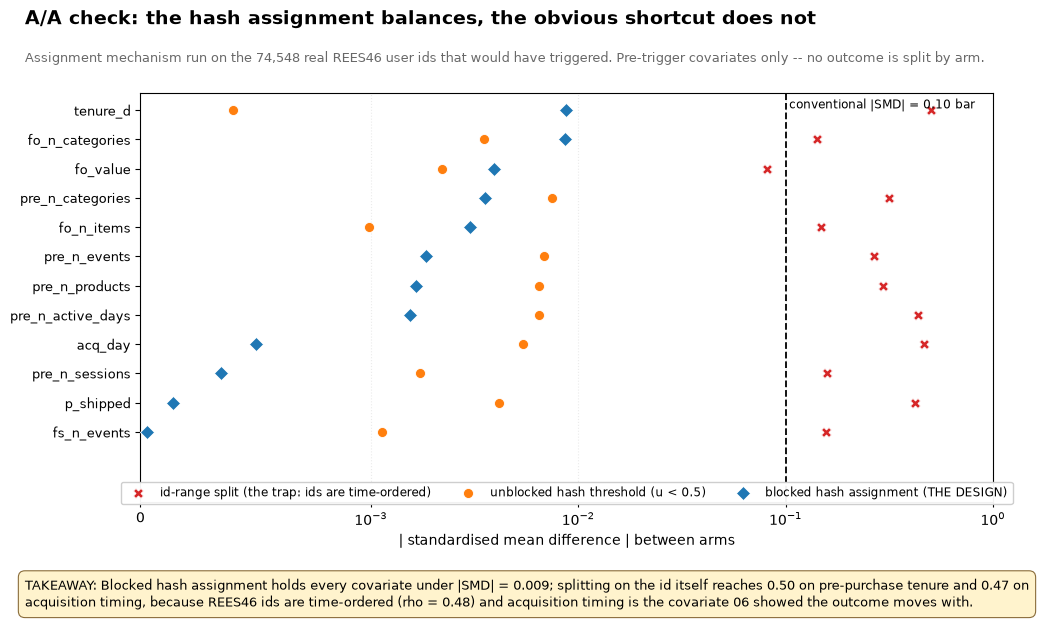

In [10]:
fig, ax = frame(figsize=(11, 6.4))
order = list(BAL_BLOCKED.covariate)
ypos = np.arange(len(order))[::-1]
for tab, colr, mk, lab in [
        (BAL_RANGE,   "#d62728", "X", "id-range split (the trap: ids are time-ordered)"),
        (BAL_SIMPLE,  "#ff7f0e", "o", "unblocked hash threshold (u < 0.5)"),
        (BAL_BLOCKED, "#1f77b4", "D", "blocked hash assignment (THE DESIGN)")]:
    vals = tab.set_index("covariate").loc[order, "abs_smd"].to_numpy()
    ax.scatter(vals, ypos, s=52, marker=mk, color=colr, label=lab, zorder=3,
               edgecolor="white", linewidth=0.6)
ax.axvline(0.10, color="black", ls="--", lw=1.3)
ax.text(0.104, len(order) - 0.6, "conventional |SMD| = 0.10 bar", fontsize=8.6, va="top")
ax.set_yticks(ypos); ax.set_yticklabels(order, fontsize=9)
ax.set_xlabel("| standardised mean difference | between arms")
ax.set_xscale("symlog", linthresh=0.001)
ax.set_xlim(0, 1.0)
ax.set_ylim(-2.4, len(order) - 0.4)
ax.grid(axis="x", alpha=0.25, ls=":")
ax.legend(fontsize=8.8, loc="lower center", ncol=3, framealpha=0.95,
          bbox_to_anchor=(0.5, -0.02))
add_title(fig, "A/A check: the hash assignment balances, the obvious shortcut does not",
          f"Assignment mechanism run on the {len(E):,} real REES46 user ids that would have triggered. "
          "Pre-trigger covariates only -- no outcome is split by arm.")
_acq_range = float(BAL_RANGE.set_index("covariate").loc["acq_day", "abs_smd"])
add_takeaway(fig, f"Blocked hash assignment holds every covariate under |SMD| = {BAL_BLOCKED.abs_smd.max():.3f}; "
                  f"splitting on the id itself reaches {BAL_RANGE.abs_smd.max():.2f} on pre-purchase tenure and "
                  f"{_acq_range:.2f} on acquisition timing, because REES46 ids are time-ordered (rho = 0.48) and "
                  "acquisition timing is the covariate 06 showed the outcome moves with.")
save(fig, "nb08_assignment_balance")
plt.show()

### 4E — The score separates the outcome, which is why it is a good block and still a bad target

The two statements are not in tension and this is the cell that shows it.

In [11]:
terc = (E.groupby("score_tercile", observed=True)
          .agg(n=("y", "size"), base_rate_pct=("y", lambda v: 100 * v.mean()),
               n_events=("y", "sum"), mean_score=("p_shipped", "mean"))
          .reset_index())
terc["base_rate_pct"] = terc["base_rate_pct"].round(3)
terc["mean_score"] = terc["mean_score"].round(5)
show_df(terc, "nb08_score_tercile_base_rates", max_rows=10)

spread = terc.base_rate_pct.max() / terc.base_rate_pct.min()
print()
print(f"  spread across terciles: {spread:.2f}x  ({terc.base_rate_pct.min():.2f}% -> {terc.base_rate_pct.max():.2f}%)")
print()
print("  GOOD BLOCK   : blocking needs the covariate to predict the OUTCOME, which it does at 3.6x.")
print("                 That buys variance reduction on the treatment contrast, for free, with no")
print("                 assumption about responsiveness.")
print("  BAD TARGET   : targeting needs the covariate to predict RESPONSIVENESS, which 07 measured")
print("                 directly on randomised data and found it does not. Risk targeting captured")
print("                 1.0% of the achievable effect; random captured 49.8%.")
print()
print("  The score is used for exactly the thing it demonstrably does, and for nothing else.")

  score_tercile      n  base_rate_pct  n_events  mean_score
0        T1_low  24849          4.797      1192     0.05665
1        T2_mid  24850          8.748      2174     0.09306
2       T3_high  24849         17.200      4274     0.16631

  spread across terciles: 3.59x  (4.80% -> 17.20%)

  GOOD BLOCK   : blocking needs the covariate to predict the OUTCOME, which it does at 3.6x.
                 That buys variance reduction on the treatment contrast, for free, with no
                 assumption about responsiveness.
  BAD TARGET   : targeting needs the covariate to predict RESPONSIVENESS, which 07 measured
                 directly on randomised data and found it does not. Risk targeting captured
                 1.0% of the achievable effect; random captured 49.8%.

  The score is used for exactly the thing it demonstrably does, and for nothing else.


## 5. Estimand, primary metric, guardrails

### 5A — The estimand is ITT by assignment, and 07 is the reason

**Primary estimand.** The intention-to-treat effect of *being assigned to treatment*:

$$\tau_{ITT} \;=\; \mathbb{E}\big[Y_i \mid Z_i = 1\big] - \mathbb{E}\big[Y_i \mid Z_i = 0\big]$$

where $Z_i$ is the randomised assignment from §4 and $Y_i$ is the primary metric from §5B.
Every enrolled user is analysed in the arm they were assigned to, regardless of what
happened afterwards — including users whose email bounced, who never opened it, who
unsubscribed, or whose send failed.

**The analysis that is forbidden, named precisely.** "Repeat rate among users who opened
the email, versus control." Delivery, open and click are all realised *after*
randomisation and all depend on the user's own behaviour, so conditioning on them compares
a self-selected slice of the treated arm against the whole control arm. The comparison is
no longer randomised and the quantity it estimates is *the effect of being the kind of
user who opens marketing email, plus the effect of the email*.

07 measured the size of this error on real randomised data rather than asserting it.
Criteo's `exposure` column is the same structure — realised post-randomisation, driven by
the user being active where the ad server could reach them:

| quantity | visit | conversion |
|---|---|---|
| ITT by assignment | 1.034 pp | 0.115 pp |
| TOT (complier effect, IV) | 28.700 pp | 3.196 pp |
| naive exposed-vs-control | 37.634 pp | 5.185 pp |
| **naive / TOT inflation** | **1.31×** | **1.62×** |

The naive number overstates even the *complier* effect by 62% on conversion. It is the
Cookie Cats gate structure and it will appear in this experiment the moment somebody asks
for the open-conditional cut.

**What is allowed.** Delivery and open rates are logged as *operational diagnostics* —
they tell you whether the campaign ran, which is worth knowing — and are reported for the
treatment arm alone, never as an arm contrast. If compliance turns out low enough that ITT
badly understates the per-recipient effect, the correct response is a pre-specified CACE /
IV estimate using assignment as the instrument, reported as a secondary estimand with its
exclusion restriction stated. It is not a subgroup analysis on openers.

### 5B — Primary metric and exactly when the clock starts

**Primary metric.** `repeat_purchase_30d`, defined identically to 05/06:

> a further order, in a **session other than the first-order session**, with
> `order_ts > t0`, where orders are reconstructed by the certified rule
> (`GROUP BY user_id, user_session, event_time` on purchase rows), over bot-excluded data.

**The clock.** This is the one definition most likely to be got wrong in implementation, so
it is stated twice, in two forms.

- t0 = the user's **first order** timestamp.
- The trigger fires at **t0 + 14 days**, which is the moment of randomisation and the moment
  of the send.
- The outcome window is **(t0 + 14 days, t0 + 44 days]** — 30 days measured **from
  assignment**, not from t0.
- A user is analysed only once their full 30-day window has closed. Censored users are
  excluded, never zero-filled (05's eligibility rule; an unobserved window is not a
  negative).

The outcome window opens at assignment because the effect being measured is the effect of
the nudge. Measuring 30 days from t0 would put 14 of those 30 days *before* the treatment
existed, which would dilute any real effect by roughly half and would also mean the control
arm's window and the treated arm's window measure different things once send timing slips.

Note where this lands: the window closes at day 44, just past 03's certified 42.2d churn
threshold. That is a coincidence of arithmetic, not a design choice, but it is a convenient
one — a user still unconverted at the end of the measurement window is, on the certified
definition, churned.

**Base rate for powering: 10.248%**, measured on the 74,548 historical analogues who would
have triggered at day 14. This is deliberately *not* 05/06's 13.73%. That figure is the
repeat rate measured from t0 over 30 days across all first-time buyers; this experiment's
population has already survived 14 days without repeating, which removes the fastest
repeaters and lowers the rate. Powering on 13.73% would understate the sample needed.

In [12]:
D30_ALL = FEAT["positive_rate_pct"]["d30"] / 100.0
print("PRIMARY METRIC AND CLOCK")
print("=" * 100)
print(f"  metric            : repeat_purchase_30d, 05/06 definition (other-session, certified orders)")
print(f"  t0                : user's first order timestamp")
print(f"  assignment / send : t0 + {TRIGGER_DAYS:.0f}d")
print(f"  outcome window    : (t0 + {TRIGGER_DAYS:.0f}d, t0 + {TRIGGER_DAYS + OUTCOME_H:.0f}d]   "
      f"-- {OUTCOME_H:.0f} days FROM ASSIGNMENT")
print(f"  censoring         : analysed only when t0 + {TRIGGER_DAYS + OUTCOME_H:.0f}d <= readout date; "
      f"never zero-filled")
print()
print("BASE RATE -- WHICH ONE, AND WHY")
print("=" * 100)
print(f"  05/06 repeat_purchase_30d, all first-time buyers from t0 : {100*D30_ALL:.3f}%  "
      f"(n = {FEAT['eligible_n']['d30']:,})")
print(f"  THIS DESIGN, survivors to day {TRIGGER_DAYS:.0f}, next {OUTCOME_H:.0f} days   : "
      f"{100*BASE_RATE:.3f}%  (n = {len(POOL):,})")
print(f"  difference                                               : "
      f"{100*(D30_ALL - BASE_RATE):.3f} pp -- the fast repeaters, removed by the trigger")
print()
print(f"  Powering on {100*D30_ALL:.2f}% instead of {100*BASE_RATE:.2f}% would understate the required")
print(f"  sample, because the design would be solving for an effect on a population it never touches.")

PRIMARY METRIC AND CLOCK
  metric            : repeat_purchase_30d, 05/06 definition (other-session, certified orders)
  t0                : user's first order timestamp
  assignment / send : t0 + 14d
  outcome window    : (t0 + 14d, t0 + 44d]   -- 30 days FROM ASSIGNMENT
  censoring         : analysed only when t0 + 44d <= readout date; never zero-filled

BASE RATE -- WHICH ONE, AND WHY
  05/06 repeat_purchase_30d, all first-time buyers from t0 : 13.730%  (n = 91,334)
  THIS DESIGN, survivors to day 14, next 30 days   : 10.248%  (n = 74,548)
  difference                                               : 3.482 pp -- the fast repeaters, removed by the trigger

  Powering on 13.73% instead of 10.25% would understate the required
  sample, because the design would be solving for an effect on a population it never touches.


### 5C — Guardrails

A lift in the primary metric is not on its own a reason to ship. Four guardrails, each with
a baseline measured on the trigger population and a pre-specified direction. Baselines are
DATA; thresholds are design choices and labelled as such.

**G1 — Average order value.** A nudge that works by pulling people toward a cheap
impulse purchase can raise the repeat rate and lower revenue. Two-sided, reported with a CI.

**G2 — 90-day order count (the pull-forward check).** The one that decides whether the
result is real. If the nudge only moves a purchase *earlier*, the 30-day metric rises and
the 90-day order count does not move at all. This is the difference between creating
demand and rescheduling it, and only a longer window can tell them apart. Pre-registered as
a **required** readout at day 90, not an optional extension: shipping on the 30-day number
without it is how retention programmes come to be believed in without ever having worked.

**G3 — Opt-out / unsubscribe rate.** One-sided. This is the design's answer to 07's
sleeping-dogs constraint: 07 searched two outcomes × three rankings × {10, 20} groups and
found no group of ≥5% measurably harmed, and recorded explicitly that this is *not* a
licence to assume none exist in a retention context, where an unwanted email is a plausible
way to lose a customer. An unsubscribe is a permanent loss of the channel, so it is not
priced in the same units as a forgone order and gets a hard stopping threshold instead.

**G4 — Support contacts.** One-sided. Not measurable in REES46, which holds no support
data, so its baseline is unavailable and is labelled as such rather than invented.

In [13]:
ORDERS = pd.read_parquet(os.path.join(PROCESSED_DIR, "orders.parquet"))

# G1/G2 baselines on the trigger population with a full 90 days of trailing observation
G90 = trigger_pool(TRIGGER_DAYS, H=90.0 - TRIGGER_DAYS)   # needs trailing_days >= 90
J = ORDERS.merge(G90[["user_id", "t0"]], on="user_id", how="inner")
J["d"] = (J["order_ts"] - J["t0"]).dt.total_seconds() / 86400.0
POST = J[(J["d"] > TRIGGER_DAYS) & (J["d"] <= 90.0)]

g2 = POST.groupby("user_id").size().reindex(G90["user_id"]).fillna(0.0)
g1 = POST.groupby("user_id")["order_value"].mean()

GUARD = pd.DataFrame([
    dict(id="G1", guardrail="average order value, post-trigger orders",
         baseline=round(float(g1.mean()), 4), unit="EUR", sd=round(float(g1.std(ddof=1)), 4),
         n=int(len(g1)), direction="two-sided",
         threshold="ASSUMPTION: investigate if the 95% CI excludes a 5% relative decline",
         provenance="DATA (baseline), ASSUMPTION (threshold)"),
    dict(id="G2", guardrail="orders in (t0+14d, t0+90d] -- pull-forward check",
         baseline=round(float(g2.mean()), 4), unit="orders/user", sd=round(float(g2.std(ddof=1)), 4),
         n=int(len(g2)), direction="must move in the same direction as the primary",
         threshold="REQUIRED day-90 readout; a null here with a positive primary = pull-forward, not lift",
         provenance="DATA (baseline), ASSUMPTION (threshold)"),
    dict(id="G3", guardrail="opt-out / unsubscribe rate", baseline=np.nan, unit="pct", sd=np.nan,
         n=0, direction="one-sided (increase is harm)",
         threshold="ASSUMPTION: stop if treated opt-out exceeds control by > 0.50 pp",
         provenance="ASSUMPTION -- REES46 holds no email or consent data"),
    dict(id="G4", guardrail="support contacts per 1,000 users", baseline=np.nan, unit="per 1k", sd=np.nan,
         n=0, direction="one-sided (increase is harm)",
         threshold="ASSUMPTION: stop if treated exceeds control by > 20% relative",
         provenance="ASSUMPTION -- REES46 holds no support data"),
])
show_df(GUARD, "nb08_guardrails", max_rows=10)
print()
print(f"G2 baseline detail: {100*float((g2 >= 1).mean()):.2f}% of the trigger population places at least one")
print(f"                    order in (t0+{TRIGGER_DAYS:.0f}d, t0+90d]; mean {g2.mean():.4f} orders, sd {g2.std(ddof=1):.4f}.")
print(f"G1/G2 measured on n = {len(G90):,} trigger-population users with >= 90 days of trailing data.")
print()
print("G3 and G4 have NO baseline in this dataset. They are specified with assumed thresholds so the")
print("experiment cannot silently ship without them; the thresholds must be replaced with the CRM")
print("platform's own historical rates before launch.")

   id                                         guardrail  baseline         unit       sd      n                                       direction  \
0  G1          average order value, post-trigger orders   42.5726          EUR  35.4834   9910                                       two-sided   
1  G2  orders in (t0+14d, t0+90d] -- pull-forward check    0.3414  orders/user   0.8481  47975  must move in the same direction as the primary   
2  G3                        opt-out / unsubscribe rate       NaN          pct      NaN      0                    one-sided (increase is harm)   
3  G4                  support contacts per 1,000 users       NaN       per 1k      NaN      0                    one-sided (increase is harm)   

                                           threshold                                         provenance  
0  ASSUMPTION: investigate if the 95% CI excludes...            DATA (baseline), ASSUMPTION (threshold)  
1  REQUIRED day-90 readout; a null here with a po...     

### 5D — This metric is not 06's target, and must never be given 06's name

Both are "repeat purchase within 30 days" and they are **different quantities measured on
different populations over different windows**. 05/06's `repeat_purchase_30d` runs 30 days
from **t0** across all first-time buyers and has a base rate of **13.73%**. This
experiment's primary metric runs 30 days from the **day-14 trigger**, on users who have
already survived 14 days without repeating, and has a base rate of **10.25%**. The 3.48 pp
difference is the fast repeaters, removed by the trigger.

Quoting one number against the other — in the readout, in 09's ROI chain, or in a deck —
would be the same class of error 03 §9A had to correct when a stock churn rate was read
against a flow retention rate. So the experiment's metric gets its own name,
`repeat_30d_from_trigger`, and the naming rule is registered in the handoff rather than
left to discipline.

In [14]:
METRIC_NAMING = dict(
    experiment_metric="repeat_30d_from_trigger",
    experiment_window=f"(t0 + {TRIGGER_DAYS:.0f}d, t0 + {TRIGGER_DAYS + OUTCOME_H:.0f}d]",
    experiment_population=f"first-time buyers still un-repeated at day {TRIGGER_DAYS:.0f}",
    experiment_base_rate_pct=round(100 * BASE_RATE, 3),
    nb06_metric="repeat_purchase_30d",
    nb06_window="(t0, t0 + 30d]",
    nb06_population="all D30-eligible first-time buyers",
    nb06_base_rate_pct=FEAT["positive_rate_pct"]["d30"],
    rule=("These are DIFFERENT quantities on DIFFERENT populations over DIFFERENT windows. "
          "10.25% and 13.73% must never be quoted as the same number, compared to each other, "
          "or substituted for one another in an ROI chain."),
)
print("METRIC NAMING RULE")
print("=" * 100)
print(f"  08 experiment : {METRIC_NAMING['experiment_metric']:<26} window {METRIC_NAMING['experiment_window']:<22} "
      f"base {METRIC_NAMING['experiment_base_rate_pct']:.2f}%")
print(f"  06 target     : {METRIC_NAMING['nb06_metric']:<26} window {METRIC_NAMING['nb06_window']:<22} "
      f"base {METRIC_NAMING['nb06_base_rate_pct']:.2f}%")
print(f"  gap           : {METRIC_NAMING['nb06_base_rate_pct'] - METRIC_NAMING['experiment_base_rate_pct']:.2f} pp "
      f"-- the repeaters the day-{TRIGGER_DAYS:.0f} trigger has already let through")
print()
print("  " + METRIC_NAMING["rule"])

METRIC NAMING RULE
  08 experiment : repeat_30d_from_trigger    window (t0 + 14d, t0 + 44d]   base 10.25%
  06 target     : repeat_purchase_30d        window (t0, t0 + 30d]         base 13.73%
  gap           : 3.48 pp -- the repeaters the day-14 trigger has already let through

  These are DIFFERENT quantities on DIFFERENT populations over DIFFERENT windows. 10.25% and 13.73% must never be quoted as the same number, compared to each other, or substituted for one another in an ROI chain.


## 6. The economics chain

Principle 20 of the brief asks for one linked chain rather than four separate calculations:

$$\textbf{break-even lift} \;\longrightarrow\; \textbf{MDE} \;\longrightarrow\; \textbf{sample size} \;\longrightarrow\; \textbf{duration}$$

Each arrow is a decision with a stated input. Principle 13 requires DATA-DERIVED values and
ASSUMPTIONS to stay visually separate at every step, so every input is registered below in
a provenance table with a tag, and §10 asserts mechanically that each carries one and that
none traces to Criteo.

### 6A — The input ledger

Six inputs. Three are measurements of this retailer; three are business parameters this
project cannot observe and must assume. The tag is what separates them, and it is checked
rather than trusted.

In [15]:
ECON = {}

def register(key, value, tag, source, unit="", note=""):
    assert tag in ("DATA", "ASSUMPTION"), tag
    ECON[key] = dict(key=key, value=float(value), tag=tag, source=source, unit=unit, note=note)
    return float(value)

# ---- DATA-DERIVED ---------------------------------------------------------------------
P0 = register("base_rate", BASE_RATE, "DATA",
              "05 features.parquet, day-14 trigger pool (this notebook S3C)", "share",
              f"{len(POOL):,} historical analogues; 05/06's 13.73% is the wrong anchor for this population")

_o = ORDERS.sort_values(["user_id", "order_ts"]).copy()
_o["order_rank"] = _o.groupby("user_id").cumcount() + 1
_bulk = set(F.loc[F["is_bulk_buyer_fullhistory"].astype(bool), "user_id"])
_second = _o[(_o["order_rank"] == 2) & (~_o["user_id"].isin(_bulk))]
AOV2 = register("aov_second_order", _second["order_value"].mean(), "DATA",
                "05 orders.parquet, second orders, bulk buyers excluded", "EUR",
                f"n={len(_second):,}, median EUR {_second['order_value'].median():.2f}; "
                "bulk buyers excluded from the MEAN per 01's B2B finding")

_cmp = pd.read_csv(os.path.join(TABLES_DIR, "nb02_0B_compounding_vs_selection.csv"))
_slow = _cmp[_cmp.t2_bucket == ">90d"].iloc[0]
_fast = _cmp[_cmp.t2_bucket == "<=7d"].iloc[0]
_baseline_p3 = _slow.P3rd_by30d / _slow.ratio_vs_baseline
DOWNSTREAM = register("downstream_uplift", (_slow.P3rd_by30d - _baseline_p3) / 100.0, "DATA",
                      "02 S0B compounding-vs-selection, slowest-to-second bucket (1.27x residual)", "share",
                      f"1.27x residual, NOT the naive {_fast.ratio_vs_baseline:.2f}x from the fastest bucket")

_inflow_from = pd.Timestamp("2019-11-01")
_inflow_to   = pd.Timestamp("2020-03-01")
_n_inflow = int((F["t0"] >= _inflow_from).sum())
_inflow_days = (_inflow_to - _inflow_from).days
INFLOW_DAY = register("first_buyer_inflow_per_day", _n_inflow / _inflow_days, "DATA",
                      "05 features.parquet, first-order timestamps, 2019-11-01 to 2020-02-29", "users/day",
                      "October excluded: it is left-censored, every October purchaser looks like a first-time buyer")

SURVIVAL = register("trigger_survival_share", len(POOL) / float((F["trailing_days"] >= TRIGGER_DAYS + OUTCOME_H).sum()),
                    "DATA", "this notebook S3C trigger sweep, row T=14", "share",
                    "share of a cohort still un-repeated at day 14, i.e. still enrollable")

# ---- ASSUMPTIONS ----------------------------------------------------------------------
CONTACT_COST = register("contact_cost", 0.05, "ASSUMPTION",
                        "business input -- transactional email send, ESP list price order of magnitude", "EUR/contact",
                        "charged on EVERY treated user, converting or not. Sensitivity grid in S6C.")
MARGIN = register("contribution_margin", 0.30, "ASSUMPTION",
                  "business input -- cosmetics e-commerce gross contribution after COGS, fulfilment, payment", "share",
                  "not observable in REES46: the data carries price, never cost. Sensitivity grid in S6C.")
DISCOUNT = register("discount_rate", 0.00, "ASSUMPTION",
                    "design choice -- the primary arm carries NO offer", "share",
                    "S6C prices the discount variants and they are why the primary arm carries none")

LEDGER = pd.DataFrame(list(ECON.values()))[["key", "value", "unit", "tag", "source", "note"]]
show_df(LEDGER, "nb08_economics_ledger", max_rows=15)
print()
print(f"  DATA-DERIVED : {(LEDGER.tag == 'DATA').sum()}      ASSUMPTION : {(LEDGER.tag == 'ASSUMPTION').sum()}")

                          key       value         unit         tag                                             source  \
0                   base_rate    0.102484        share        DATA  05 features.parquet, day-14 trigger pool (this...   
1            aov_second_order   40.885534          EUR        DATA  05 orders.parquet, second orders, bulk buyers ...   
2           downstream_uplift    0.040032        share        DATA  02 S0B compounding-vs-selection, slowest-to-se...   
3  first_buyer_inflow_per_day  695.363636    users/day        DATA  05 features.parquet, first-order timestamps, 2...   
4      trigger_survival_share    0.916792        share        DATA          this notebook S3C trigger sweep, row T=14   
5                contact_cost    0.050000  EUR/contact  ASSUMPTION  business input -- transactional email send, ES...   
6         contribution_margin    0.300000        share  ASSUMPTION  business input -- cosmetics e-commerce gross c...   
7               discount_rate   

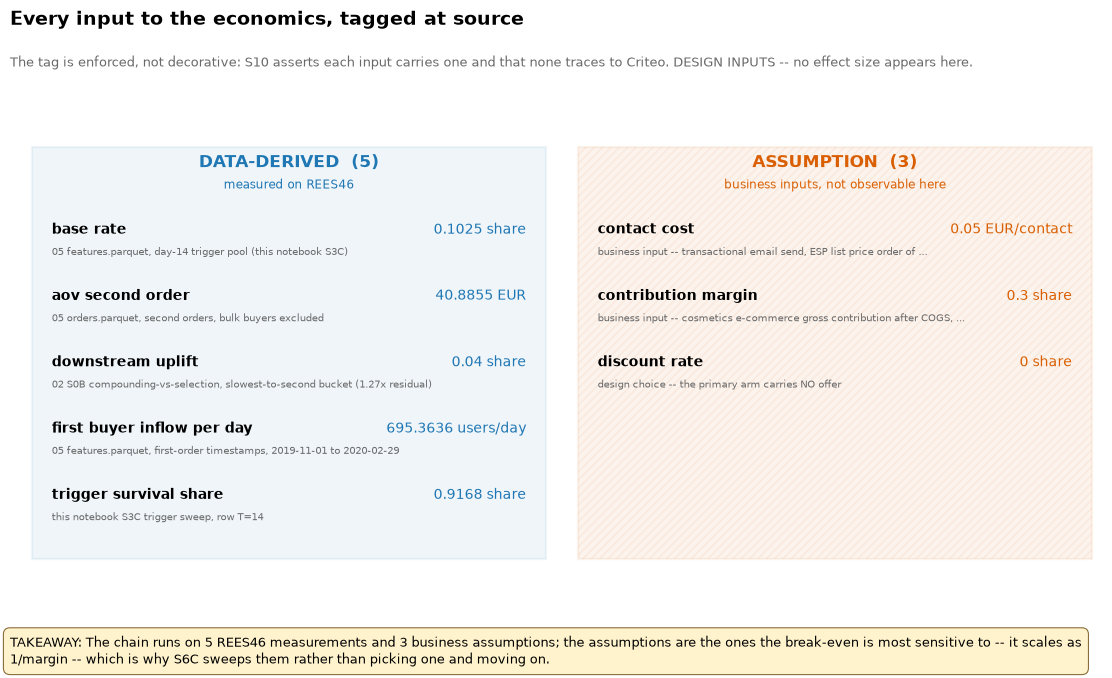

In [16]:
fig = plt.figure(figsize=(11.5, 7.0))
fig.subplots_adjust(top=0.82, bottom=0.16, left=0.03, right=0.97)
ax = fig.add_axes([0.03, 0.16, 0.94, 0.64]); ax.set_axis_off()
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

DATA_C, ASSUME_C = "#1f77b4", "#d95f02"
dat = LEDGER[LEDGER.tag == "DATA"].reset_index(drop=True)
asm = LEDGER[LEDGER.tag == "ASSUMPTION"].reset_index(drop=True)

def clip_words(text, n=74):
    if len(text) <= n:
        return text
    cut = text[:n].rsplit(" ", 1)[0]
    return cut + " ..."

def panel(x0, w, rows, colr, header, sub, hatch):
    ax.add_patch(Rectangle((x0, 0.04), w, 0.92, facecolor=colr, alpha=0.07,
                           edgecolor=colr, lw=1.6, hatch=hatch))
    ax.text(x0 + w / 2, 0.925, header, ha="center", va="center", fontsize=12.0,
            fontweight="bold", color=colr)
    ax.text(x0 + w / 2, 0.875, sub, ha="center", va="center", fontsize=8.8, color=colr)
    y, step = 0.775, 0.148
    for _, r in rows.iterrows():
        v = f"{r.value:,.4f}".rstrip("0").rstrip(".")
        ax.text(x0 + 0.018, y, r.key.replace("_", " "), fontsize=9.8, va="center", fontweight="bold")
        ax.text(x0 + w - 0.018, y, f"{v} {r.unit}", fontsize=9.8, va="center", ha="right", color=colr)
        ax.text(x0 + 0.018, y - 0.050, clip_words(r.source), fontsize=7.5, va="center", color="dimgray")
        y -= step
panel(0.01, 0.475, dat, DATA_C, f"DATA-DERIVED  ({len(dat)})", "measured on REES46", None)
panel(0.515, 0.475, asm, ASSUME_C, f"ASSUMPTION  ({len(asm)})", "business inputs, not observable here", "////")

add_title(fig, "Every input to the economics, tagged at source",
          "The tag is enforced, not decorative: S10 asserts each input carries one and that none traces to Criteo. "
          "DESIGN INPUTS -- no effect size appears here.")
add_takeaway(fig, f"The chain runs on {len(dat)} REES46 measurements and {len(asm)} business assumptions; the "
                  "assumptions are the ones the break-even is most sensitive to -- it scales as 1/margin -- which is "
                  "why S6C sweeps them rather than picking one and moving on.")
save(fig, "nb08_economics_ledger")
plt.show()

### 6B — What one engineered second purchase is worth, and why it is not 2×

The tempting arithmetic: users who make a second purchase go on to repeat at roughly twice
the base rate, so an engineered second purchase buys that doubled downstream behaviour.

02 §0B tested it and the answer is no. Bucketing second purchasers by how fast they got
there, the downstream 30-day third-order rate runs 2.00× baseline for the fastest bucket
(≤7 days) and **1.27×** for the slowest (>90 days). If second purchasing *caused* the
downstream rate, the multiplier would not depend on how long it took. That it falls
monotonically with time-to-second means most of the apparent effect is **selection**:
fast repeaters were always going to be repeaters. 02's verdict is "selection-dominated".

An engineered second purchase — one manufactured by a nudge in a user who was not going to
make it — is by definition the *least* selected kind. The slowest bucket's residual is the
right multiplier, and it is what the handoff's `implication_for_08` instructs:

> *Do not assume an engineered 2nd purchase inherits the ~2× repeat rate; plan on the
> residual (1.27×), which is the part not explained by which buyers self-select into a
> fast 2nd purchase.*

So the value of one incremental second order has two terms:

$$V \;=\; \underbrace{m \cdot \text{AOV}_2}_{\text{margin on the order itself}} \;+\; \underbrace{m \cdot \text{AOV}_2 \cdot \Delta P_3}_{\text{downstream, at the 1.27}\times\text{ residual}}$$

with $\Delta P_3$ the *incremental* 30-day third-order probability the second order buys,
above the baseline a first-order-only user carries.

In [17]:
V_ORDER      = MARGIN * AOV2
V_DOWNSTREAM = MARGIN * AOV2 * DOWNSTREAM
V_TOTAL      = V_ORDER + V_DOWNSTREAM

naive_down   = (_fast.P3rd_by30d - _baseline_p3) / 100.0
V_NAIVE      = V_ORDER + MARGIN * AOV2 * naive_down

VAL = pd.DataFrame([
    dict(component="margin on the incremental 2nd order", value_eur=round(V_ORDER, 4),
         basis=f"ASSUMPTION margin {MARGIN:.0%} x DATA AOV2 EUR {AOV2:.2f}"),
    dict(component="downstream, 1.27x residual (02 S0B)", value_eur=round(V_DOWNSTREAM, 4),
         basis=f"+{100*DOWNSTREAM:.2f} pp incremental 3rd-order probability"),
    dict(component="TOTAL V per incremental 2nd order", value_eur=round(V_TOTAL, 4), basis=""),
    dict(component="[rejected] downstream at the naive 2.00x", value_eur=round(MARGIN * AOV2 * naive_down, 4),
         basis=f"+{100*naive_down:.2f} pp -- selection, not causation"),
    dict(component="[rejected] TOTAL under the naive 2.00x", value_eur=round(V_NAIVE, 4), basis=""),
])
show_df(VAL, "nb08_value_of_second_purchase", max_rows=10)
print()
print(f"  baseline 30-day next-order probability used by 02 : {_baseline_p3:.2f}%")
print(f"  slowest-to-second bucket (>90d), 1.27x            : {_slow.P3rd_by30d:.2f}%  "
      f"-> incremental +{100*DOWNSTREAM:.2f} pp")
print(f"  fastest bucket (<=7d), 2.00x                      : {_fast.P3rd_by30d:.2f}%  "
      f"-> incremental +{100*naive_down:.2f} pp")
print()
print(f"  The naive figure would overstate the downstream term by {naive_down/DOWNSTREAM:.1f}x")
print(f"  (EUR {MARGIN*AOV2*naive_down:.2f} against EUR {V_DOWNSTREAM:.2f}) and total value by "
      f"{V_NAIVE/V_TOTAL:.2f}x.")
print(f"  Break-even lift scales as 1/V, so the naive version would understate the bar the campaign")
print(f"  has to clear by the same factor.")

                                  component  value_eur                                        basis
0       margin on the incremental 2nd order    12.2657  ASSUMPTION margin 30% x DATA AOV2 EUR 40.89
1       downstream, 1.27x residual (02 S0B)     0.4910   +4.00 pp incremental 3rd-order probability
2         TOTAL V per incremental 2nd order    12.7567                                             
3  [rejected] downstream at the naive 2.00x     1.8206        +14.84 pp -- selection, not causation
4    [rejected] TOTAL under the naive 2.00x    14.0863                                             

  baseline 30-day next-order probability used by 02 : 14.83%
  slowest-to-second bucket (>90d), 1.27x            : 18.83%  -> incremental +4.00 pp
  fastest bucket (<=7d), 2.00x                      : 29.67%  -> incremental +14.84 pp

  The naive figure would overstate the downstream term by 3.7x
  (EUR 1.82 against EUR 0.49) and total value by 1.10x.
  Break-even lift scales as 1/V, so the naive

### 6C — Break-even lift

The campaign pays a contact cost on **every** treated user and earns value on the
**incremental** conversions only. With $c$ the contact cost, $\delta$ the absolute lift in
the primary metric and $V$ from 6B, per treated user:

$$\text{net} \;=\; \delta V - c \qquad\Longrightarrow\qquad \delta^{*} \;=\; \frac{c}{V}$$

An offer changes the shape, and not slightly. A discount of rate $d$ is paid on every
treated user who converts — including the $p_0$ share who would have converted anyway — so
it appears in the numerator *and* eats the margin in the denominator:

$$\delta^{*}_{\text{offer}} \;=\; \frac{c + d\cdot\text{AOV}_2\cdot p_0}{V - d\cdot\text{AOV}_2}$$

The grid below sweeps both assumptions, because they are the two numbers this project
cannot measure and the whole chain hangs off them.

In [18]:
z_a, z_b = stats.norm.ppf(0.975), stats.norm.ppf(0.80)

def n_per_arm(p0, delta, alpha_z=z_a, beta_z=z_b):
    '''Two-proportion, two-sided alpha=0.05, power=0.80, equal allocation.'''
    p1 = p0 + delta
    pbar = (p0 + p1) / 2.0
    num = (alpha_z * math.sqrt(2 * pbar * (1 - pbar)) + beta_z * math.sqrt(p0 * (1 - p0) + p1 * (1 - p1))) ** 2
    return num / delta ** 2

def mde_for_n(p0, n):
    lo, hi = 1e-7, 0.5
    for _ in range(300):
        mid = (lo + hi) / 2.0
        if n_per_arm(p0, mid) > n: lo = mid
        else: hi = mid
    return (lo + hi) / 2.0

def breakeven(c, m, d, aov=AOV2, down=DOWNSTREAM, p0=P0):
    V = m * aov * (1 + down)
    den = V - d * aov
    if den <= 0:
        return np.nan
    return (c + d * aov * p0) / den

BE = breakeven(CONTACT_COST, MARGIN, DISCOUNT)
print("BREAK-EVEN, AT THE REGISTERED ASSUMPTIONS")
print("=" * 100)
print(f"  V (value per incremental 2nd order) = EUR {V_TOTAL:.4f}")
print(f"  c (contact cost, ASSUMPTION)        = EUR {CONTACT_COST:.4f}")
print(f"  break-even absolute lift  d* = c/V  = {100*BE:.4f} pp")
print(f"  break-even relative lift            = {100*BE/P0:.3f}%   (against a {100*P0:.3f}% base rate)")
print(f"  n per arm to DETECT d* at 80% power = {n_per_arm(P0, BE):,.0f}")
print()
GRID = []
for label, c, d in [("email, no offer", 0.05, 0.00),
                    ("premium channel, no offer", 0.15, 0.00),
                    ("direct mail, no offer", 0.50, 0.00),
                    ("email + 10% discount", 0.05, 0.10),
                    ("email + 20% discount", 0.05, 0.20)]:
    for m in (0.20, 0.30, 0.40):
        be = breakeven(c, m, d)
        n = n_per_arm(P0, be) if (be == be and be < 0.35) else np.nan
        GRID.append(dict(scenario=label, contact_cost_eur=c, discount=d, margin=m,
                         breakeven_pp=round(100 * be, 3) if be == be else np.nan,
                         breakeven_rel_pct=round(100 * be / P0, 1) if be == be else np.nan,
                         n_per_arm_to_detect=int(n) if n == n else np.nan))
GRID = pd.DataFrame(GRID)
show_df(GRID, "nb08_breakeven_sensitivity", max_rows=20)

BREAK-EVEN, AT THE REGISTERED ASSUMPTIONS
  V (value per incremental 2nd order) = EUR 12.7567
  c (contact cost, ASSUMPTION)        = EUR 0.0500
  break-even absolute lift  d* = c/V  = 0.3920 pp
  break-even relative lift            = 3.825%   (against a 10.248% base rate)
  n per arm to DETECT d* at 80% power = 95,575

                     scenario  contact_cost_eur  discount  margin  breakeven_pp  breakeven_rel_pct  n_per_arm_to_detect
0             email, no offer              0.05       0.0     0.2         0.588                5.7              42828.0
1             email, no offer              0.05       0.0     0.3         0.392                3.8              95574.0
2             email, no offer              0.05       0.0     0.4         0.294                2.9             169207.0
3   premium channel, no offer              0.15       0.0     0.2         1.764               17.2               4990.0
4   premium channel, no offer              0.15       0.0     0.3         1.17

,scenario,contact_cost_eur,discount,margin,breakeven_pp,breakeven_rel_pct,n_per_arm_to_detect
0,"email, no offer",0.05,0.0,0.2,0.588,5.7,42828.0
1,"email, no offer",0.05,0.0,0.3,0.392,3.8,95574.0
2,"email, no offer",0.05,0.0,0.4,0.294,2.9,169207.0
3,"premium channel, no offer",0.15,0.0,0.2,1.764,17.2,4990.0
4,"premium channel, no offer",0.15,0.0,0.3,1.176,11.5,10968.0
5,"premium channel, no offer",0.15,0.0,0.4,0.882,8.6,19268.0
6,"direct mail, no offer",0.50,0.0,0.2,5.879,57.4,518.0
7,"direct mail, no offer",0.50,0.0,0.3,3.920,38.2,1093.0
8,"direct mail, no offer",0.50,0.0,0.4,2.940,28.7,1878.0
9,email + 10% discount,0.05,0.1,0.2,10.621,103.6,181.0


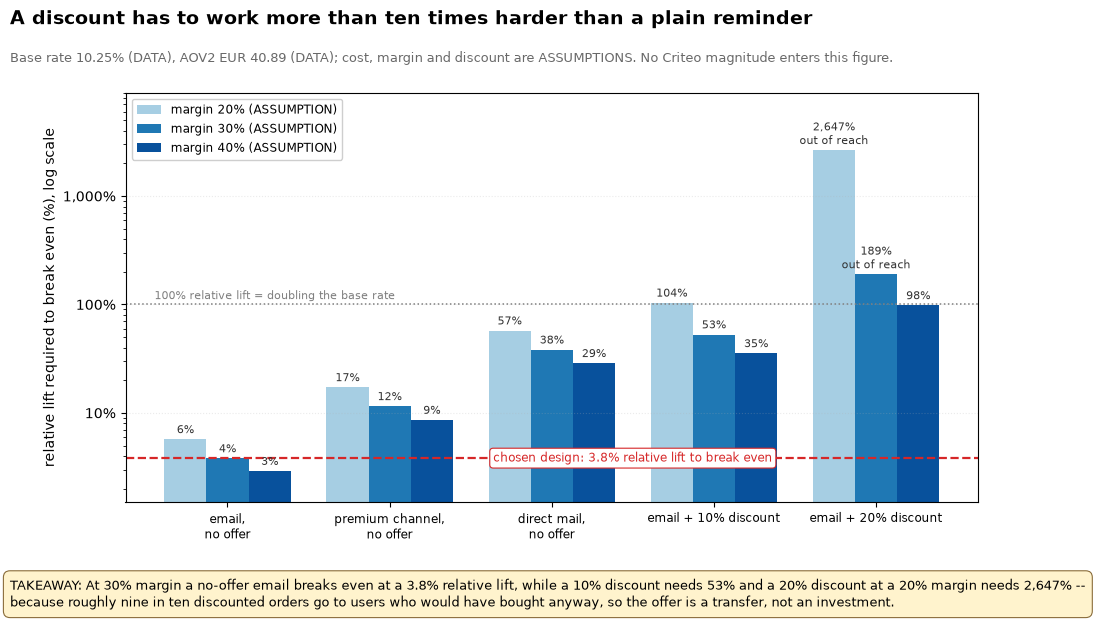

In [19]:
fig, ax = frame(figsize=(11, 6.4))
scen = list(GRID.scenario.unique())
xs = np.arange(len(scen)); wid = 0.26
cols = {0.20: "#a6cee3", 0.30: "#1f78b4", 0.40: "#08519c"}
for i, m in enumerate((0.20, 0.30, 0.40)):
    sub = GRID[GRID.margin == m].set_index("scenario").loc[scen]
    vals = sub.breakeven_rel_pct.to_numpy(float)
    ax.bar(xs + (i - 1) * wid, np.nan_to_num(vals, nan=1.0), wid, color=cols[m],
           label=f"margin {m:.0%} (ASSUMPTION)")
    for x, v in zip(xs + (i - 1) * wid, vals):
        if v != v:
            continue
        lab = f"{v:,.0f}%" + ("\nout of reach" if v > 150 else "")
        ax.text(x, v * 1.14, lab, ha="center", fontsize=7.6, color="#333333")
ax.axhline(100.0, color="#7f7f7f", lw=1.1, ls=":")
ax.text(-0.45, 112, "100% relative lift = doubling the base rate", fontsize=8.0, color="#7f7f7f")
ax.axhline(100 * BE / P0, color="#d62728", lw=1.6, ls="--")
ax.text(2.5, 100 * BE / P0, f"chosen design: {100*BE/P0:.1f}% relative lift to break even",
        fontsize=8.8, color="#d62728", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.28", facecolor="white", edgecolor="#d62728", linewidth=0.8))
ax.set_xticks(xs); ax.set_xticklabels([s.replace(", ", ",\n") for s in scen], fontsize=8.6)
ax.set_ylabel("relative lift required to break even (%), log scale")
ax.set_yscale("log")
ax.set_ylim(1.5, 9000)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f"{v:,.0f}%"))
ax.grid(axis="y", alpha=0.25, ls=":")
ax.legend(fontsize=8.8, loc="upper left", framealpha=0.95)
add_title(fig, "A discount has to work more than ten times harder than a plain reminder",
          f"Base rate {100*P0:.2f}% (DATA), AOV2 EUR {AOV2:.2f} (DATA); cost, margin and discount are ASSUMPTIONS. "
          "No Criteo magnitude enters this figure.")
add_takeaway(fig, f"At 30% margin a no-offer email breaks even at a {100*BE/P0:.1f}% relative lift, while a 10% discount "
                  f"needs {GRID[(GRID.scenario=='email + 10% discount') & (GRID.margin==0.30)].breakeven_rel_pct.iloc[0]:.0f}% "
                  "and a 20% discount at a 20% margin needs 2,647% -- because roughly nine in ten discounted "
                  "orders go to users who would have bought anyway, so the offer is a transfer, not an investment.")
save(fig, "nb08_breakeven_sensitivity")
plt.show()

**The design decision this figure forces.** The first test carries **no offer**. A 10%
discount raises the bar from a 3.8% relative lift to 52.8%; a 20% discount at a 20% margin
puts it at 2,647%, which is to say the arithmetic has no solution a campaign could reach. The mechanism is entirely in the denominator of the base rate:
10.25% of the treated arm converts without any help, and every one of them is handed the
discount too. An offer only makes sense once a plain reminder has been shown to move the
metric at all — at which point the discount arm is a second experiment with its own
break-even, not a bigger version of this one.

### 6D — Sample size

Two proportions, two-sided $\alpha = 0.05$, power $1-\beta = 0.80$, equal allocation, with
$p_0$ the DATA-derived base rate and $p_1 = p_0 + \delta$:

$$n_{\text{per arm}} \;=\; \frac{\Big(z_{1-\alpha/2}\sqrt{2\bar p(1-\bar p)} \;+\; z_{1-\beta}\sqrt{p_0(1-p_0)+p_1(1-p_1)}\Big)^{2}}{\delta^{2}}, \qquad \bar p = \frac{p_0+p_1}{2}$$

The pooled variance under the null sits with $z_{1-\alpha/2}$ (it is a test of no
difference) and the unpooled variance under the alternative sits with $z_{1-\beta}$ (it is
the sampling distribution the power is computed against). Using one form for both is the
usual slip and it misstates $n$ by a few percent at these rates.

Blocking is ignored in this formula, which makes it **conservative**: blocking on a
covariate correlated with the outcome reduces the variance of the contrast, so the realised
power is at or above the nominal 0.80. Claiming the reduction in advance would require
committing to an $R^2$ this design has no business asserting.

07's binding rule — *power on EVENT count, not user count* — is honoured by reporting the
repeat-purchase events each design point buys alongside the headcount. Events are what
every variance in the chain is actually made of, and §7 is where the number bites.

### 6E — Duration, from the retailer's real inflow

Sample size becomes calendar time through the rate at which users trigger.

**First-time-buyer inflow.** 05's feature table holds 109,732 first orders over the 151-day
span. The rate used here is computed on **2019-11-01 onward only**. October is excluded on
purpose: the data begins 2019-10-01, so every October purchaser has no observable prior
order and is recorded as a first-time buyer whether or not they were one. Including October
would inflate the inflow rate and shorten every duration estimate in this section.

**Enrolment rate** = inflow × the share still un-repeated at day 14 (the trigger sweep's
survival share). Not every first-time buyer enrols; the ones who repeat inside 14 days
never trigger.

The table then sweeps the MDE. It is the table the business actually decides from: a
smaller detectable effect is not free, it is paid for in weeks.

In [20]:
ENROL_DAY = INFLOW_DAY * SURVIVAL
RAMP_WEEKS    = math.ceil(TRIGGER_DAYS / 7.0)
OUTCOME_WEEKS = math.ceil(OUTCOME_H / 7.0)

print("INFLOW -> ENROLMENT")
print("=" * 100)
print(f"  first orders, 2019-11-01..2020-02-29 : {_n_inflow:,} over {_inflow_days} days")
print(f"  first-time-buyer inflow              : {INFLOW_DAY:,.1f} users/day  "
      f"({INFLOW_DAY*30:,.0f} per 30 days)")
print(f"  still un-repeated at day {TRIGGER_DAYS:.0f}          : {100*SURVIVAL:.2f}%")
print(f"  ENROLMENT RATE                       : {ENROL_DAY:,.1f} users/day  "
      f"({ENROL_DAY*30:,.0f} per 30 days)")
print()
print(f"  October excluded (left-censored). With October included the rate would read "
      f"{len(F)/SPAN['span_days']:,.1f}/day,")
print(f"  {100*(len(F)/SPAN['span_days'])/INFLOW_DAY - 100:.1f}% higher, and every duration below would be optimistic.")

MDES = [BE, 0.005, 0.0075, 0.010, 0.015, 0.020, 0.025, 0.030]
DUR = []
for d in MDES:
    n = math.ceil(n_per_arm(P0, d)); N = 2 * n
    enrol_days = N / ENROL_DAY
    enrol_wk = math.ceil(enrol_days / 7.0)
    DUR.append(dict(
        mde_pp=round(100 * d, 3),
        mde_rel_pct=round(100 * d / P0, 1),
        n_per_arm=n, n_total=N,
        events_per_arm=int(round(n * P0)),
        enrolment_days=round(enrol_days, 1),
        enrolment_weeks=enrol_wk,
        weeks_to_readout=RAMP_WEEKS + enrol_wk + OUTCOME_WEEKS,
        contact_cost_eur=round(n * CONTACT_COST, 0),
        clears_breakeven=bool(d > BE),
    ))
DUR = pd.DataFrame(DUR)
show_df(DUR, "nb08_mde_duration", max_rows=15)
print()
print(f"  weeks_to_readout = {RAMP_WEEKS} ramp (first trigger at day {TRIGGER_DAYS:.0f}) "
      f"+ enrolment + {OUTCOME_WEEKS} outcome ({OUTCOME_H:.0f}d, rounded up to whole weeks)")
print(f"  the G2 pull-forward readout adds a further {math.ceil((90-TRIGGER_DAYS-OUTCOME_H)/7):d} weeks "
      f"after the primary readout")

INFLOW -> ENROLMENT
  first orders, 2019-11-01..2020-02-29 : 84,139 over 121 days
  first-time-buyer inflow              : 695.4 users/day  (20,861 per 30 days)
  still un-repeated at day 14          : 91.68%
  ENROLMENT RATE                       : 637.5 users/day  (19,125 per 30 days)

  October excluded (left-censored). With October included the rate would read 726.7/day,
  4.5% higher, and every duration below would be optimistic.
   mde_pp  mde_rel_pct  n_per_arm  n_total  events_per_arm  enrolment_days  enrolment_weeks  weeks_to_readout  contact_cost_eur  clears_breakeven
0   0.392          3.8      95575   191150            9795           299.8               43                50            4779.0             False
1   0.500          4.9      58999   117998            6046           185.1               27                34            2950.0              True
2   0.750          7.3      26497    52994            2716            83.1               12                19            13

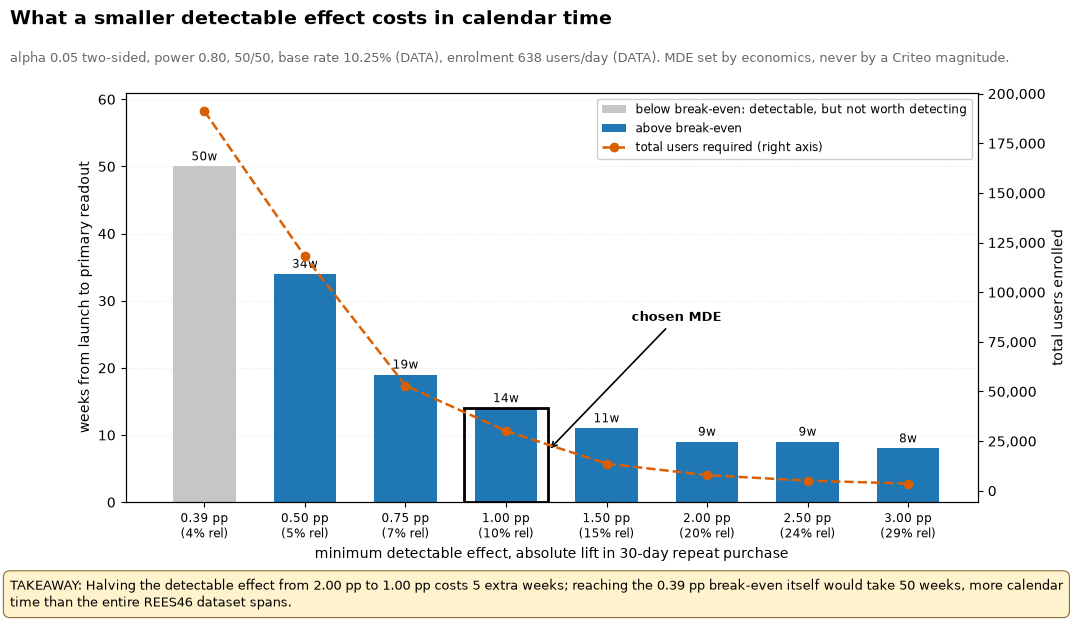

In [21]:
fig, ax = frame(figsize=(11, 6.4))
ax2 = ax.twinx()
d = DUR.copy()
bars = ax.bar(np.arange(len(d)), d.weeks_to_readout, 0.62,
              color=np.where(d.clears_breakeven, "#1f77b4", "#c6c6c6"), zorder=2)
for i, r in d.iterrows():
    ax.text(i, r.weeks_to_readout + 0.9, f"{int(r.weeks_to_readout)}w", ha="center", fontsize=8.8)
ax2.plot(np.arange(len(d)), d.n_total, "o--", color="#d95f02", lw=1.8, ms=6, zorder=3,
         label="total users required (right axis)")
CHOICE = 3   # the 1.00 pp row
ax.add_patch(Rectangle((CHOICE - 0.42, 0), 0.84, d.weeks_to_readout.iloc[CHOICE],
                       fill=False, edgecolor="black", lw=2.0, zorder=4))
ax.annotate("chosen MDE", xy=(CHOICE + 0.42, d.weeks_to_readout.iloc[CHOICE] * 0.55),
            xytext=(CHOICE + 1.25, d.weeks_to_readout.iloc[CHOICE] + 13), fontsize=9.5,
            fontweight="bold", arrowprops=dict(arrowstyle="->", lw=1.2))
ax.set_xticks(np.arange(len(d)))
ax.set_xticklabels([f"{r.mde_pp:.2f} pp\n({r.mde_rel_pct:.0f}% rel)" for _, r in d.iterrows()], fontsize=8.4)
ax.set_xlabel("minimum detectable effect, absolute lift in 30-day repeat purchase")
ax.set_ylabel("weeks from launch to primary readout")
ax2.set_ylabel("total users enrolled")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
ax.set_ylim(0, d.weeks_to_readout.max() * 1.22)
ax.grid(axis="y", alpha=0.25, ls=":")
ax.bar(0, 0, color="#c6c6c6", label="below break-even: detectable, but not worth detecting")
ax.bar(0, 0, color="#1f77b4", label="above break-even")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8.6, loc="upper right", framealpha=0.95)
add_title(fig, "What a smaller detectable effect costs in calendar time",
          f"alpha 0.05 two-sided, power 0.80, 50/50, base rate {100*P0:.2f}% (DATA), "
          f"enrolment {ENROL_DAY:,.0f} users/day (DATA). MDE set by economics, never by a Criteo magnitude.")
add_takeaway(fig, f"Halving the detectable effect from 2.00 pp to 1.00 pp costs 5 extra weeks; reaching the "
                  f"{100*BE:.2f} pp break-even itself would take {int(d.weeks_to_readout.iloc[0])} weeks, "
                  "more calendar time than the entire REES46 dataset spans.")
save(fig, "nb08_mde_duration")
plt.show()

### 6F — The chosen design point, and the gap the chain exposes

**Chosen MDE: 1.00 pp absolute, a 9.8% relative lift.** 15,058 users per arm, 30,116 total,
~1,543 repeat events per arm, 7 weeks of enrolment, **14 weeks** from launch to the primary
readout (2 weeks of ramp to the first trigger + 7 enrolling + 5 for the last enrollee's
outcome window), and **21 weeks** to the G2 pull-forward readout at day 90.

The chain also exposes something that a sample-size calculator run on its own would hide,
and it changes the analysis plan.

**Break-even is 0.39 pp. The MDE is 1.00 pp. The MDE is 2.55× the profitability bar.**

The campaign is profitable at effects two and a half times smaller than this experiment can
reliably detect. Detecting the break-even effect itself would need 95,575 users per arm and
50 weeks — more than twice the calendar the entire REES46 dataset spans. That gap is not a flaw in the design; it is
what an inexpensive treatment on a 10% base rate implies, and pretending otherwise by
quoting only the MDE would be the dishonest move.

**Consequence: the decision rule is not a significance test.** A p-value against a null of
zero answers a question nobody is asking. The pre-registered rule compares the confidence
interval against the break-even line:

| 95% CI on the ITT | decision |
|---|---|
| lower bound > 0.39 pp | **ship** — profitable with the uncertainty accounted for |
| upper bound < 0.39 pp | **kill** — cannot be profitable even at the optimistic end |
| interval straddles 0.39 pp | **inconclusive** — extend, or accept the smaller effect is unmeasurable |

The third row is the honest one and it is likely: a true effect of, say, 0.6 pp is
profitable and will very probably return a CI straddling break-even. That outcome must be
reported as inconclusive, not as "no effect". It is the same shape of answer 03 gave about
the churn threshold and 06 gave about the model's strength, and it comes from the same
place — this is a weak-signal problem, and the design says so up front rather than
discovering it at readout.

> **§6G supersedes the sample size on this page.** 15,058 per arm is sized to detect 1.00 pp
> against a null of **zero**, which is not the hypothesis the decision rule above tests.
> Sizing against the decision margin instead gives 40,721 per arm. The MDE is unchanged;
> what changes is what "detect" is taken to mean.

In [22]:
CHOSEN = DUR.iloc[CHOICE]
MDE = CHOSEN.mde_pp / 100.0
N_PER_ARM = int(CHOSEN.n_per_arm)

print("THE CHAIN, END TO END")
print("=" * 100)
print(f"  [ASSUMPTION] contact cost                 EUR {CONTACT_COST:.4f} per treated user")
print(f"  [ASSUMPTION] contribution margin          {MARGIN:.0%}")
print(f"  [DATA]       AOV, second orders           EUR {AOV2:.2f}")
print(f"  [DATA]       downstream residual (1.27x)  +{100*DOWNSTREAM:.2f} pp on the 3rd order")
print(f"               -> V per incremental order   EUR {V_TOTAL:.4f}")
print(f"               -> BREAK-EVEN LIFT           {100*BE:.4f} pp  ({100*BE/P0:.2f}% relative)")
print(f"  [DESIGN]     -> MDE                       {100*MDE:.2f} pp  ({100*MDE/P0:.1f}% relative)")
print(f"  [DATA]       base rate at the trigger     {100*P0:.3f}%")
print(f"               -> SAMPLE SIZE               {N_PER_ARM:,} per arm, {2*N_PER_ARM:,} total")
print(f"                  repeat events per arm     ~{int(CHOSEN.events_per_arm):,}")
print(f"  [DATA]       enrolment rate               {ENROL_DAY:,.1f} users/day")
print(f"               -> ENROLMENT                 {CHOSEN.enrolment_days:.1f} days = "
      f"{int(CHOSEN.enrolment_weeks)} weeks (rounded up)")
print(f"               -> TIME TO PRIMARY READOUT   {int(CHOSEN.weeks_to_readout)} weeks "
      f"({RAMP_WEEKS} ramp + {int(CHOSEN.enrolment_weeks)} enrol + {OUTCOME_WEEKS} outcome)")
print(f"               -> TIME TO G2 (day-90)       "
      f"{int(CHOSEN.weeks_to_readout) + math.ceil((90-TRIGGER_DAYS-OUTCOME_H)/7):d} weeks")
print(f"  [ASSUMPTION] contact spend                EUR {N_PER_ARM*CONTACT_COST:,.0f}")
print()
print("THE GAP")
print("=" * 100)
print(f"  MDE / break-even = {MDE/BE:.2f}x  -- the campaign pays for itself at effects "
      f"{MDE/BE:.1f}x smaller than this test can see.")
print(f"  Detecting break-even directly: {int(DUR.iloc[0].n_per_arm):,}/arm, "
      f"{int(DUR.iloc[0].weeks_to_readout)} weeks -- against a {SPAN['span_days']}-day dataset.")
print(f"  DECISION RULE: compare the 95% CI to {100*BE:.2f} pp, three ways. Not a test against zero.")

THE CHAIN, END TO END
  [ASSUMPTION] contact cost                 EUR 0.0500 per treated user
  [ASSUMPTION] contribution margin          30%
  [DATA]       AOV, second orders           EUR 40.89
  [DATA]       downstream residual (1.27x)  +4.00 pp on the 3rd order
               -> V per incremental order   EUR 12.7567
               -> BREAK-EVEN LIFT           0.3920 pp  (3.82% relative)
  [DESIGN]     -> MDE                       1.00 pp  (9.8% relative)
  [DATA]       base rate at the trigger     10.248%
               -> SAMPLE SIZE               15,058 per arm, 30,116 total
                  repeat events per arm     ~1,543
  [DATA]       enrolment rate               637.5 users/day
               -> ENROLMENT                 47.2 days = 7 weeks (rounded up)
               -> TIME TO PRIMARY READOUT   14 weeks (2 ramp + 7 enrol + 5 outcome)
               -> TIME TO G2 (day-90)       21 weeks
  [ASSUMPTION] contact spend                EUR 753

THE GAP
  MDE / break-even = 2.55x

### 6G — The sample size and the decision rule were testing different hypotheses

§6D sized the experiment for 80% power to detect a 1.00 pp effect **against a null of
zero**. §6F then pre-registered a decision rule that ships only when the 95% CI's lower
bound clears **0.392 pp**. Those are not the same hypothesis, and the sample size solves
the wrong one.

The arithmetic is short enough to do in one line. At 15,058 per arm the standard error of
the difference is 0.357 pp, so the 95% CI has a half-width of 0.699 pp, and

$$\text{ship} \iff \hat\delta - 1.96\,\widehat{SE} > 0.392 \text{ pp} \iff \hat\delta > 1.091 \text{ pp}$$

The design is powered to *detect* 1.00 pp but can only *act* on an observed effect above
1.09 pp. At a true effect of exactly 1.00 pp — the effect the design was built around — the
probability of shipping is about 40%, not 80%. The nominal 80% power was never power to
make the decision; it was power to reject zero, which the decision rule does not ask about.

The failure is symmetric at the other end. Killing requires the CI's *upper* bound to fall
below 0.392 pp, which at this sample size needs an observed effect below −0.31 pp. A truly
useless campaign returns that only about 20% of the time. **Four runs in five of a
worthless treatment would come back inconclusive**, and inconclusive is the outcome §6F
already warned would be common — it is far more common than that section realised.

This is the same mistake in a different costume as the one 07 caught: an estimand and a
number that were specified separately and never checked against each other. The table below
is the check, run on the current design before anything is changed.

In [23]:
# SE of the difference in proportions at n per arm, UNPOOLED: the decision rule compares a
# CI to a non-zero boundary, so there is no null of equality to pool under.
def se_diff(p0, delta, n):
    p1 = p0 + delta
    return math.sqrt(p0 * (1 - p0) / n + p1 * (1 - p1) / n)

# P(ship) / P(kill) / P(inconclusive) under the three-way rule of S6F.
#   ship <=> dhat - z*SE > be        kill <=> dhat + z*SE < be
# SE is treated as known and evaluated at the true effect; the realised CI uses the observed
# SE, which moves these probabilities by well under a percentage point at these n.
def operating_characteristics(p0, n, be, true_deltas, z=z_a):
    out = []
    for d in true_deltas:
        s_ = se_diff(p0, d, n)
        ship = 1.0 - stats.norm.cdf((be + z * s_ - d) / s_)
        kill = stats.norm.cdf((be - z * s_ - d) / s_)
        out.append(dict(true_effect_pp=round(100 * d, 3),
                        P_ship_pct=round(100 * ship, 1),
                        P_kill_pct=round(100 * kill, 1),
                        P_inconclusive_pct=round(100 * (1 - ship - kill), 1)))
    return pd.DataFrame(out)

TRUE_GRID = [0.0, BE, 0.0075, 0.010, 0.015]
N_PER_ARM_DETECT = int(N_PER_ARM)          # S6D's answer: 80% power vs a null of ZERO
OC_DETECT = operating_characteristics(P0, N_PER_ARM_DETECT, BE, TRUE_GRID)
OC_DETECT.insert(0, "design", f"A) detect-vs-zero, {N_PER_ARM_DETECT:,}/arm")

se_now = se_diff(P0, 0.010, N_PER_ARM_DETECT)
print(f"CURRENT DESIGN -- {N_PER_ARM_DETECT:,} per arm")
print("=" * 100)
print(f"  SE of the difference at a 1.00 pp effect : {100*se_now:.4f} pp")
print(f"  95% CI half-width                        : {100*z_a*se_now:.4f} pp")
print(f"  SHIP requires an observed effect above   : {100*(BE + z_a*se_now):.4f} pp"
      f"   -- against an MDE of {100*MDE:.2f} pp")
print(f"  KILL requires an observed effect below   : {100*(BE - z_a*se_now):.4f} pp")
print()
show_df(OC_DETECT, "nb08_operating_characteristics_current", max_rows=10)
print()
print(f"  At the design's own target effect ({100*MDE:.2f} pp), P(ship) = "
      f"{OC_DETECT.loc[OC_DETECT.true_effect_pp == round(100*MDE,3), 'P_ship_pct'].iloc[0]:.1f}% -- not 80%.")
print(f"  At a true effect of zero,          P(kill) = "
      f"{OC_DETECT.loc[OC_DETECT.true_effect_pp == 0.0, 'P_kill_pct'].iloc[0]:.1f}% -- "
      f"{OC_DETECT.loc[OC_DETECT.true_effect_pp == 0.0, 'P_inconclusive_pct'].iloc[0]:.1f}% of the time "
      "a worthless campaign is simply not adjudicated.")

CURRENT DESIGN -- 15,058 per arm
  SE of the difference at a 1.00 pp effect : 0.3569 pp
  95% CI half-width                        : 0.6995 pp
  SHIP requires an observed effect above   : 1.0915 pp   -- against an MDE of 1.00 pp
  KILL requires an observed effect below   : -0.3076 pp

                          design  true_effect_pp  P_ship_pct  P_kill_pct  P_inconclusive_pct
0  A) detect-vs-zero, 15,058/arm           0.000         0.1        20.1                79.8
1  A) detect-vs-zero, 15,058/arm           0.392         2.5         2.5                95.0
2  A) detect-vs-zero, 15,058/arm           0.750        17.1         0.1                82.8
3  A) detect-vs-zero, 15,058/arm           1.000        39.9         0.0                60.1
4  A) detect-vs-zero, 15,058/arm           1.500        86.7         0.0                13.3

  At the design's own target effect (1.00 pp), P(ship) = 39.9% -- not 80%.
  At a true effect of zero,          P(kill) = 20.1% -- 79.8% of the time a wort

### 6H — Re-sizing against the decision margin

If the rule is *ship when the CI lower bound clears break-even*, then the quantity that has
to be detected is not the effect but the **decision margin** $\delta - \delta^{*}$ — the
distance between the true effect and the break-even line. Requiring

$$P\big(\hat\delta - z_{1-\alpha/2}\widehat{SE} > \delta^{*}\big) = 1-\beta \quad\text{at}\quad \delta = \delta_{\text{target}}$$

and solving for the standard error gives

$$SE = \frac{\delta_{\text{target}} - \delta^{*}}{z_{1-\alpha/2} + z_{1-\beta}}, \qquad n_{\text{per arm}} = \frac{p_0(1-p_0) + p_1(1-p_1)}{SE^{2}}$$

Two things are worth noticing in that formula. The variance term is **unpooled on both
sides**, because the comparison is against a non-zero boundary and there is no null of
equality to pool under — §6D's pooled term was correct there and is not correct here. And
$n$ scales as $1/(\delta - \delta^{*})^{2}$ rather than $1/\delta^{2}$, so as the target
effect approaches break-even the cost does not rise gently, it diverges. §6I is where that
bites.

The target stays **1.00 pp**. The MDE was never the thing that was wrong.

In [24]:
# n per arm giving `power` probability that the CI LOWER BOUND clears `be` at the target effect.
def n_for_decision(p0, delta_target, be, power=0.80, z=z_a):
    if delta_target <= be:
        return float("inf")
    zb_ = stats.norm.ppf(power)
    p1 = p0 + delta_target
    se_required = (delta_target - be) / (z + zb_)
    return (p0 * (1 - p0) + p1 * (1 - p1)) / se_required ** 2

N_PER_ARM_DECISION = int(math.ceil(n_for_decision(P0, MDE, BE)))
se_req = (MDE - BE) / (z_a + z_b)

enrol_days_dec = 2 * N_PER_ARM_DECISION / ENROL_DAY
enrol_wk_dec   = math.ceil(enrol_days_dec / 7.0)
readout_wk_dec = RAMP_WEEKS + enrol_wk_dec + OUTCOME_WEEKS

print("RE-SIZED AGAINST THE DECISION MARGIN")
print("=" * 100)
print(f"  target effect                      : {100*MDE:.2f} pp        (unchanged)")
print(f"  break-even                         : {100*BE:.4f} pp")
print(f"  decision margin                    : {100*(MDE-BE):.4f} pp")
print(f"  required SE                        : {100*se_req:.4f} pp = "
      f"({100*MDE:.2f} - {100*BE:.4f}) / ({z_a:.4f} + {z_b:.4f})")
print(f"  n PER ARM                          : {N_PER_ARM_DECISION:,}   "
      f"({N_PER_ARM_DECISION/N_PER_ARM_DETECT:.2f}x the detect-vs-zero sizing)")
print(f"  n TOTAL                            : {2*N_PER_ARM_DECISION:,}")
print(f"  repeat events per arm              : ~{int(round(N_PER_ARM_DECISION * P0)):,}")
print(f"  enrolment                          : {enrol_days_dec:.1f} days = {enrol_wk_dec} weeks")
print(f"  time to primary readout            : {readout_wk_dec} weeks "
      f"({RAMP_WEEKS} ramp + {enrol_wk_dec} enrol + {OUTCOME_WEEKS} outcome)")
print(f"  time to the G2 day-90 readout      : "
      f"{readout_wk_dec + math.ceil((90 - TRIGGER_DAYS - OUTCOME_H)/7):d} weeks")
print(f"  contact spend [ASSUMPTION EUR {CONTACT_COST:.2f}] : EUR {N_PER_ARM_DECISION*CONTACT_COST:,.0f}")
print()
OC_DECISION = operating_characteristics(P0, N_PER_ARM_DECISION, BE, TRUE_GRID)
OC_DECISION.insert(0, "design", f"B) decision-powered, {N_PER_ARM_DECISION:,}/arm")
show_df(OC_DECISION, "nb08_operating_characteristics_resized", max_rows=10)

OC_BOTH = pd.concat([OC_DETECT, OC_DECISION], ignore_index=True)
OC_BOTH.to_csv(os.path.join(TABLES_DIR, "nb08_operating_characteristics_both.csv"), index=False)
print()
print(f"  P(ship) at the 1.00 pp target : {OC_DETECT.loc[OC_DETECT.true_effect_pp==1.0,'P_ship_pct'].iloc[0]:.1f}% "
      f"-> {OC_DECISION.loc[OC_DECISION.true_effect_pp==1.0,'P_ship_pct'].iloc[0]:.1f}%")
print(f"  P(kill) at a true zero        : {OC_DETECT.loc[OC_DETECT.true_effect_pp==0.0,'P_kill_pct'].iloc[0]:.1f}% "
      f"-> {OC_DECISION.loc[OC_DECISION.true_effect_pp==0.0,'P_kill_pct'].iloc[0]:.1f}%")
print()
print(f"  At exactly break-even both designs sit at ~2.5% / ~2.5% / ~95%, which is correct and not a")
print(f"  defect: a two-sided 95% CI centred on the boundary must fall either side 2.5% of the time.")
print(f"  No sample size can adjudicate an effect that IS the break-even effect.")

RE-SIZED AGAINST THE DECISION MARGIN
  target effect                      : 1.00 pp        (unchanged)
  break-even                         : 0.3920 pp
  decision margin                    : 0.6080 pp
  required SE                        : 0.2170 pp = (1.00 - 0.3920) / (1.9600 + 0.8416)
  n PER ARM                          : 40,721   (2.70x the detect-vs-zero sizing)
  n TOTAL                            : 81,442
  repeat events per arm              : ~4,173
  enrolment                          : 127.8 days = 19 weeks
  time to primary readout            : 26 weeks (2 ramp + 19 enrol + 5 outcome)
  time to the G2 day-90 readout      : 33 weeks
  contact spend [ASSUMPTION EUR 0.05] : EUR 2,036

                            design  true_effect_pp  P_ship_pct  P_kill_pct  P_inconclusive_pct
0  B) decision-powered, 40,721/arm           0.000         0.0        45.4                54.6
1  B) decision-powered, 40,721/arm           0.392         2.5         2.5                95.0
2  B) decisio

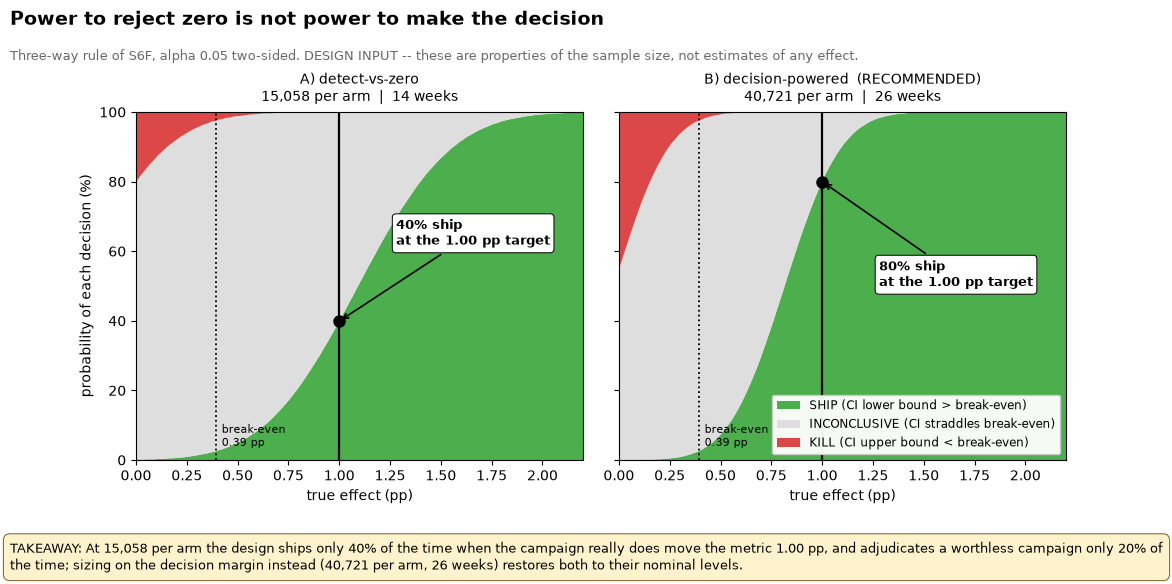

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 6.0), sharey=True)
fig.subplots_adjust(top=0.80, bottom=0.22, wspace=0.08)

grid = np.linspace(0.0, 0.022, 120)
COL = dict(ship="#2ca02c", incon="#d9d9d9", kill="#d62728")
for ax_, n_, lab in [(axes[0], N_PER_ARM_DETECT, f"A) detect-vs-zero\n{N_PER_ARM_DETECT:,} per arm  |  "
                                                 f"{RAMP_WEEKS + math.ceil((2*N_PER_ARM_DETECT/ENROL_DAY)/7) + OUTCOME_WEEKS} weeks"),
                     (axes[1], N_PER_ARM_DECISION, f"B) decision-powered  (RECOMMENDED)\n"
                                                   f"{N_PER_ARM_DECISION:,} per arm  |  {readout_wk_dec} weeks")]:
    oc_ = operating_characteristics(P0, n_, BE, grid)
    ax_.stackplot(100 * grid,
                  oc_.P_ship_pct, oc_.P_inconclusive_pct, oc_.P_kill_pct,
                  colors=[COL["ship"], COL["incon"], COL["kill"]], alpha=0.85,
                  labels=["SHIP (CI lower bound > break-even)",
                          "INCONCLUSIVE (CI straddles break-even)",
                          "KILL (CI upper bound < break-even)"])
    ax_.axvline(100 * BE, color="black", lw=1.3, ls=":")
    ax_.axvline(100 * MDE, color="black", lw=1.6)
    p_ship_at_target = operating_characteristics(P0, n_, BE, [MDE]).P_ship_pct.iloc[0]
    ax_.plot([100 * MDE], [p_ship_at_target], "o", ms=8, color="black", zorder=5)
    dy = 22 if p_ship_at_target < 60 else -30
    ax_.annotate(f"{p_ship_at_target:.0f}% ship\nat the 1.00 pp target",
                 xy=(100 * MDE, p_ship_at_target), xytext=(100 * MDE + 0.28, p_ship_at_target + dy),
                 fontsize=9.2, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", linewidth=0.7),
                 arrowprops=dict(arrowstyle="->", lw=1.2))
    ax_.set_title(lab, fontsize=10.2, pad=8)
    ax_.set_xlabel("true effect (pp)")
    ax_.set_xlim(0, 2.2); ax_.set_ylim(0, 100)
    ax_.text(100 * BE + 0.03, 3, "break-even\n0.39 pp", fontsize=7.8, va="bottom")
axes[0].set_ylabel("probability of each decision (%)")
axes[1].legend(fontsize=8.4, loc="lower right", framealpha=0.95)

add_title(fig, "Power to reject zero is not power to make the decision",
          "Three-way rule of S6F, alpha 0.05 two-sided. DESIGN INPUT -- these are properties of the "
          "sample size, not estimates of any effect.")
add_takeaway(fig, f"At {N_PER_ARM_DETECT:,} per arm the design ships only "
                  f"{OC_DETECT.loc[OC_DETECT.true_effect_pp==1.0,'P_ship_pct'].iloc[0]:.0f}% of the time when the "
                  f"campaign really does move the metric 1.00 pp, and adjudicates a worthless campaign only "
                  f"{OC_DETECT.loc[OC_DETECT.true_effect_pp==0.0,'P_kill_pct'].iloc[0]:.0f}% of the time; sizing on "
                  f"the decision margin instead ({N_PER_ARM_DECISION:,} per arm, {readout_wk_dec} weeks) restores "
                  "both to their nominal levels.")
save(fig, "nb08_operating_characteristics")
plt.show()

### 6I — What the decision margin costs across MDEs

§6E's duration table is still correct for the question it answers — how long to *detect* an
effect against zero. This is the companion table for the question the decision rule
actually asks, and the two differ by more than a constant factor, because $n$ now scales as
$1/(\delta-\delta^{*})^2$.

The consequence is that targets close to break-even are not expensive, they are
**unreachable**. A 0.50 pp target sits 0.108 pp above the break-even line and would need
over a million users per arm — decades of this retailer's inflow. That is not a reason to
pick a bigger target for convenience; it is the honest statement of what an experiment can
and cannot settle at a 10.25% base rate with a €0.05 contact cost.

In [26]:
DUR_DEC = []
for d in [0.005, 0.0075, 0.010, 0.015, 0.020, 0.025, 0.030]:
    n_ = n_for_decision(P0, d, BE)
    if not np.isfinite(n_):
        continue
    n_ = int(math.ceil(n_)); N_ = 2 * n_
    days_ = N_ / ENROL_DAY; wk_ = math.ceil(days_ / 7.0)
    DUR_DEC.append(dict(
        target_pp=round(100 * d, 3),
        decision_margin_pp=round(100 * (d - BE), 4),
        n_per_arm_detect_vs_zero=int(math.ceil(n_per_arm(P0, d))),
        n_per_arm_decision=n_,
        ratio=round(n_ / n_per_arm(P0, d), 2),
        enrolment_weeks=wk_,
        weeks_to_readout=RAMP_WEEKS + wk_ + OUTCOME_WEEKS,
        years_of_inflow=round(N_ / (ENROL_DAY * 365.25), 2),
        contact_cost_eur=round(n_ * CONTACT_COST, 0),
    ))
DUR_DEC = pd.DataFrame(DUR_DEC)
show_df(DUR_DEC, "nb08_mde_duration_decision_powered", max_rows=15)
print()
r05 = DUR_DEC[DUR_DEC.target_pp == 0.5].iloc[0]
print(f"  A 0.50 pp target sits {r05.decision_margin_pp:.3f} pp above break-even and needs "
      f"{r05.n_per_arm_decision:,} per arm")
print(f"  = {r05.years_of_inflow:.1f} years of this retailer's entire first-time-buyer inflow. Not expensive. "
      "Unreachable.")
print()
print(f"  The ratio column is the price of the decision rule: sizing to ADJUDICATE rather than to")
print(f"  DETECT costs {DUR_DEC.ratio.min():.2f}x to {DUR_DEC.ratio.max():.2f}x more users, and the "
      "multiplier grows as the target approaches break-even.")

   target_pp  decision_margin_pp  n_per_arm_detect_vs_zero  n_per_arm_decision  ratio  enrolment_weeks  weeks_to_readout  years_of_inflow  contact_cost_eur
0       0.50               0.108                     58999             1263357  21.41              567               574            10.85           63168.0
1       0.75               0.358                     26497              116246   4.39               53                60             1.00            5812.0
2       1.00               0.608                     15058               40721   2.70               19                26             0.35            2036.0
3       1.50               1.108                      6829               12509   1.83                6                13             0.11             625.0
4       2.00               1.608                      3917                6055   1.55                3                10             0.05             303.0
5       2.50               2.108                      2555      

### 6J — The recommended design, and the alternative kept visible

**Recommended: design B, 40,721 per arm.** 81,442 users, 19 weeks of enrolment, 26 weeks to
the primary readout, 33 weeks to the G2 pull-forward readout, €2,036 of contact spend at
the assumed €0.05. It ships 80% of the time when the campaign truly moves the metric
1.00 pp, and it kills a worthless campaign 45% of the time rather than 20%.

**Alternative: design A, 15,058 per arm.** 14 weeks to readout and €753. It is the right
size for a different question — *is there a large effect here at all?* — and it is kept in
the notebook rather than deleted because the trade-off is a real one a business might
reasonably take. What it cannot do is adjudicate break-even: at a true 1.00 pp effect it
returns an inconclusive 60% of the time, and at a true zero it returns inconclusive 80% of
the time.

| | A) detect-vs-zero | B) decision-powered **(recommended)** |
|---|---|---|
| n per arm | 15,058 | 40,721 |
| weeks to primary readout | 14 | 26 |
| contact spend (ASSUMPTION) | €753 | €2,036 |
| P(ship) at a true 1.00 pp | 40% | 80% |
| P(kill) at a true zero | 20% | 45% |
| P(inconclusive) at a true zero | 80% | 55% |
| answers | "is there a large effect?" | "should we ship this?" |

The honest framing of the choice: design A costs €753 and 14 weeks to have a 60% chance of
learning nothing actionable. Design B costs €1,283 more and 12 more weeks to make the
decision the pre-registration says will be made. **The second is cheaper per decision, and
the decision is the point of running the experiment at all.**

Everything downstream — the pre-registration in §9, the self-verification in §10, the
handoff in §11 — now carries design B. §6D, §6E and §6F are left standing as the record of
how the number was first derived and why it was wrong, in the same way 03 §9, 04 §9 and
05 §14 kept their own withdrawn figures rather than quietly restating them.

In [27]:
# --- rebind: design B is the recommended design from here down ------------------------
CHOSEN_DETECT = CHOSEN.copy()
N_PER_ARM = N_PER_ARM_DECISION
CHOSEN = pd.Series(dict(
    mde_pp=round(100 * MDE, 3),
    mde_rel_pct=round(100 * MDE / P0, 1),
    n_per_arm=N_PER_ARM_DECISION,
    n_total=2 * N_PER_ARM_DECISION,
    events_per_arm=int(round(N_PER_ARM_DECISION * P0)),
    enrolment_days=round(enrol_days_dec, 1),
    enrolment_weeks=enrol_wk_dec,
    weeks_to_readout=readout_wk_dec,
    contact_cost_eur=round(N_PER_ARM_DECISION * CONTACT_COST, 0),
    clears_breakeven=True,
))

DESIGNS = pd.DataFrame([
    dict(design="A) detect-vs-zero", status="ALTERNATIVE -- detects a large effect, cannot adjudicate break-even",
         n_per_arm=N_PER_ARM_DETECT, n_total=2 * N_PER_ARM_DETECT,
         events_per_arm=int(round(N_PER_ARM_DETECT * P0)),
         enrolment_weeks=math.ceil((2 * N_PER_ARM_DETECT / ENROL_DAY) / 7.0),
         weeks_to_readout=RAMP_WEEKS + math.ceil((2 * N_PER_ARM_DETECT / ENROL_DAY) / 7.0) + OUTCOME_WEEKS,
         contact_cost_eur=round(N_PER_ARM_DETECT * CONTACT_COST, 0),
         P_ship_at_target_pct=float(OC_DETECT.loc[OC_DETECT.true_effect_pp == round(100*MDE,3), "P_ship_pct"].iloc[0]),
         P_kill_at_zero_pct=float(OC_DETECT.loc[OC_DETECT.true_effect_pp == 0.0, "P_kill_pct"].iloc[0]),
         powered_for="80% power to reject a null of ZERO at 1.00 pp"),
    dict(design="B) decision-powered", status="RECOMMENDED -- powered for the decision rule actually pre-registered",
         n_per_arm=N_PER_ARM_DECISION, n_total=2 * N_PER_ARM_DECISION,
         events_per_arm=int(round(N_PER_ARM_DECISION * P0)),
         enrolment_weeks=enrol_wk_dec, weeks_to_readout=readout_wk_dec,
         contact_cost_eur=round(N_PER_ARM_DECISION * CONTACT_COST, 0),
         P_ship_at_target_pct=float(OC_DECISION.loc[OC_DECISION.true_effect_pp == round(100*MDE,3), "P_ship_pct"].iloc[0]),
         P_kill_at_zero_pct=float(OC_DECISION.loc[OC_DECISION.true_effect_pp == 0.0, "P_kill_pct"].iloc[0]),
         powered_for=f"80% power for the CI lower bound to clear {100*BE:.2f} pp at 1.00 pp"),
])
show_df(DESIGNS, "nb08_design_comparison", max_rows=5)
print()
print(f"RECOMMENDED FROM HERE DOWN: design B, {N_PER_ARM:,} per arm, {int(CHOSEN.weeks_to_readout)} weeks to readout.")
print(f"  S9 pre-registration, S10 self-verification and S11 handoff all carry design B.")
print(f"  Design A is persisted in nb08_design_comparison.csv as a labelled alternative, not deleted.")

                design                                             status  n_per_arm  n_total  events_per_arm  enrolment_weeks  weeks_to_readout  \
0    A) detect-vs-zero  ALTERNATIVE -- detects a large effect, cannot ...      15058    30116            1543                7                14   
1  B) decision-powered  RECOMMENDED -- powered for the decision rule a...      40721    81442            4173               19                26   

   contact_cost_eur  P_ship_at_target_pct  P_kill_at_zero_pct                                        powered_for  
0             753.0                  39.9                20.1      80% power to reject a null of ZERO at 1.00 pp  
1            2036.0                  80.0                45.4  80% power for the CI lower bound to clear 0.39...  

RECOMMENDED FROM HERE DOWN: design B, 40,721 per arm, 26 weeks to readout.
  S9 pre-registration, S10 self-verification and S11 handoff all carry design B.
  Design A is persisted in nb08_design_comparison.csv

## 7. Pre-registered heterogeneity readout — exploratory, and labelled so

The design measures an **ATE**. This section is the only place a conditional effect appears
and it is fenced.

**Why it is exploratory and not a finding-in-waiting.** 07 §6E measured the sample a
reliable uplift ranking needs by running the learning curve rather than guessing: on
`visit`, the baseline-response ranking sits flat at ~0.69 Qini from 10k events upward while
the uplift learners climb monotonically and only overtake it at **~330,000 events**. This
experiment buys roughly 4,200 repeat events per arm at the §6J recommended size, about
8,300 across both arms. It is still nearly two orders of magnitude short. No CATE model
will be fitted, and the readout is three pre-specified strata, not a ranking.

**What is pre-registered, before any data exists:**

- **Strata:** 06 shipped-score terciles, cut on the *enrolled* population at assignment time
  and frozen. Terciles because they are the coarsest cut that can show a non-monotone shape;
  deciles would be unreadable at this n.
- **Direction: none.** Two-sided, no predicted sign. 07 is explicit that the sign may
  invert relative to Criteo's — there, uplift *rises* with baseline propensity; the
  retention intuition is that persuadables sit mid-propensity, because the lowest tercile
  contains users who will not return whatever is sent and the highest contains users who
  return unaided. **Both a monotone rise and a middle peak are admissible outcomes and
  neither will be treated as confirmatory.** This experiment is how the retailer finds out,
  which is exactly 07's point: observational data cannot reveal the direction.
- **Statistic:** the treatment × tercile interaction from a single saturated model, reported
  with its CI, plus the three within-tercile ITTs with their own CIs. Not three separate
  significance tests — that is three chances to find nothing and report something.
- **Multiplicity:** no alpha spending, because nothing here is confirmatory. Every result in
  this section is labelled EXPLORATORY in the readout template.
- **Harm:** any tercile whose CI lies entirely below zero is reported as a candidate
  sleeping-dogs cell and triggers the §8F review, even though the design is underpowered to
  establish it. 07 found no harmed group at 5% resolution and recorded that this is not a
  licence to assume none exist.

In [28]:
mde_terc = mde_for_n(P0, N_PER_ARM / 3.0)
events_total = 2 * N_PER_ARM * P0
uplift_events_needed = 330_000

HET = pd.DataFrame([
    dict(readout="primary ATE", strata=1, n_per_arm=N_PER_ARM,
         mde_pp=round(100 * MDE, 3), status="CONFIRMATORY"),
    dict(readout="score-tercile heterogeneity", strata=3, n_per_arm=int(N_PER_ARM / 3),
         mde_pp=round(100 * mde_terc, 3), status="EXPLORATORY"),
])
show_df(HET, "nb08_heterogeneity_power", max_rows=5)
print()
print("POWER ARITHMETIC FOR THE HETEROGENEITY READOUT")
print("=" * 100)
print(f"  per-tercile MDE  {100*mde_terc:.3f} pp   vs the primary's {100*MDE:.2f} pp  "
      f"({mde_terc/MDE:.2f}x wider, ~sqrt(3))")
print(f"  per-tercile MDE / break-even = {mde_terc/BE:.1f}x")
print()
print("WHY NO CATE MODEL IS FITTED (07 S6E, measured not assumed)")
print("=" * 100)
print(f"  repeat events this design buys, both arms : ~{events_total:,.0f}")
print(f"  events 07 needed for a reliable ranking   : ~{uplift_events_needed:,}")
print(f"  shortfall                                 : {uplift_events_needed/events_total:.0f}x")
print()
print("  07's learning curve on `visit` (Qini ratio by training size) -- the evidence for that number:")
for row in CRX["uplift"]["why_uplift_lost_on_conversion"]["learning_curve"]:
    print(f"    n_train {row['n_train']:>9,}  visits {row['n_visits_train']:>7,}  "
          f"T-learner {row['T-learner']:.4f}   baseline-response {row['mu0 baseline response']:.4f}")
print()
print("  The uplift learner only overtakes the baseline-response ranking at the largest size.")
print("  An experiment two orders of magnitude smaller cannot rank responsiveness, and this")
print("  design does not claim it will.")

                       readout  strata  n_per_arm  mde_pp        status
0                  primary ATE       1      40721   1.000  CONFIRMATORY
1  score-tercile heterogeneity       3      13573   1.054   EXPLORATORY

POWER ARITHMETIC FOR THE HETEROGENEITY READOUT
  per-tercile MDE  1.054 pp   vs the primary's 1.00 pp  (1.05x wider, ~sqrt(3))
  per-tercile MDE / break-even = 2.7x

WHY NO CATE MODEL IS FITTED (07 S6E, measured not assumed)
  repeat events this design buys, both arms : ~8,347
  events 07 needed for a reliable ranking   : ~330,000
  shortfall                                 : 40x

  07's learning curve on `visit` (Qini ratio by training size) -- the evidence for that number:
    n_train   218,217  visits  10,176  T-learner 0.3928   baseline-response 0.6871
    n_train   873,335  visits  40,901  T-learner 0.5621   baseline-response 0.6920
    n_train 3,496,571  visits 164,316  T-learner 0.6809   baseline-response 0.6921
    n_train 6,989,796  visits 328,910  T-learner 0.727

## 8. Threats to validity

Nine threats, each with the notebook that found it, the mechanism, the handling the design
commits to, and the risk that remains after the handling. Two of them are measured again
here on the trigger population rather than cited, and two are recorded as **not handled**
rather than quietly omitted.

### 8A — Base-rate drift: the control must be concurrent

06 found the target's base rate falling 17.2% for the October cohort to 10.1% for December
— a 2.97 pp drift across the observation window, partly the Black Friday cohort, which 02
showed retains 5.39 pp worse at D30 than organic acquisition.

On this design's trigger population the drift is **larger**, not smaller. The cell below
measures it: 14.73% for October acquisitions down to 6.98% for December, a 7.75 pp swing,
with the Black Friday cohort making up 35.5% of November's enrollees.

**What this rules out.** Any before/after comparison. Launch the campaign in January,
compare against December, and a 7.75 pp seasonal swing sits on top of whatever the campaign
does — in either direction, at nearly eight times the size of the chosen 1.00 pp MDE. The same
applies to a "matched cohort from last year" design and to any switchback scheduled across
a promotional boundary.

**Handling, three parts:**

1. **Concurrent control.** Treatment and control are enrolled from the same daily inflow
   over the same calendar days. Any seasonal movement hits both arms identically and
   differences it out.
2. **Blocking on acquisition month** (§4C), so the arms carry the same cohort mix even if
   enrolment volume shifts mid-experiment.
3. **A pre-registered promotional rule.** If a spike day is detected by 02's rule
   (day-level mean discount vs per-product median price above median + 3·MAD, threshold
   0.00925 — derived from price dispersion, with no calendar input), the affected
   acquisition days are flagged and reported as a pre-specified subgroup, and the
   spike-day indicator is added to the blocking key. Enrolment is **not** paused: pausing
   would break the concurrency that makes the control valid. If the launch window can be
   chosen, avoid the Black Friday fortnight; if it cannot, block on it.

In [29]:
POOL_M = POOL.copy()
POOL_M["acq_month"] = POOL_M["t0"].dt.to_period("M").astype(str)
DRIFT = (POOL_M.groupby("acq_month")
         .agg(n=("y", "size"), base_rate_pct=("y", lambda v: 100 * v.mean()),
              bf_share_pct=("is_bf_cohort", lambda v: 100 * v.mean()))
         .reset_index().round(3))
show_df(DRIFT, "nb08_base_rate_drift_trigger_pop", max_rows=10)
swing = DRIFT.base_rate_pct.max() - DRIFT.base_rate_pct.min()
print()
print(f"  drift on the trigger population : {DRIFT.base_rate_pct.max():.2f}% -> "
      f"{DRIFT.base_rate_pct.min():.2f}%  = {swing:.2f} pp swing")
print(f"  drift 06 measured on its target : {MOD['population']['base_rate_drift_pp']:.2f} pp")
print(f"  chosen MDE                      : {100*MDE:.2f} pp")
print(f"  -> the seasonal swing is {swing/(100*MDE):.1f}x the effect the experiment is built to detect.")
print(f"     A pre/post design would be measuring the calendar.")

  acq_month      n  base_rate_pct  bf_share_pct
0   2019-10  23161         14.732         0.000
1   2019-11  24275          9.018        35.502
2   2019-12  18282          6.980         0.000
3   2020-01   8830          8.641         0.000

  drift on the trigger population : 14.73% -> 6.98%  = 7.75 pp swing
  drift 06 measured on its target : 2.97 pp
  chosen MDE                      : 1.00 pp
  -> the seasonal swing is 7.8x the effect the experiment is built to detect.
     A pre/post design would be measuring the calendar.


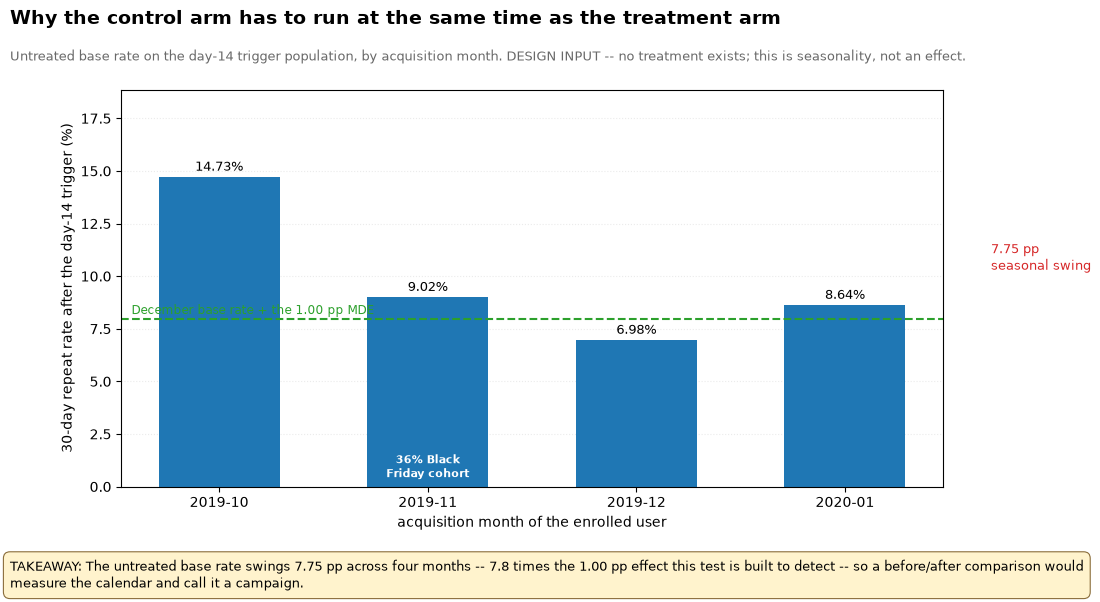

In [30]:
fig, ax = frame(figsize=(10.6, 6.2))
xs = np.arange(len(DRIFT))
ax.bar(xs, DRIFT.base_rate_pct, 0.58, color="#1f77b4", zorder=2)
for x, r in zip(xs, DRIFT.itertuples()):
    ax.text(x, r.base_rate_pct + 0.28, f"{r.base_rate_pct:.2f}%", ha="center", fontsize=9.4)
    if r.bf_share_pct > 1:
        ax.text(x, 0.45, f"{r.bf_share_pct:.0f}% Black\nFriday cohort", ha="center",
                fontsize=8.0, color="white", fontweight="bold")
lo, hi = DRIFT.base_rate_pct.min(), DRIFT.base_rate_pct.max()
ax.annotate("", xy=(len(DRIFT) - 0.35, hi), xytext=(len(DRIFT) - 0.35, lo),
            arrowprops=dict(arrowstyle="<->", lw=1.6, color="#d62728"))
ax.text(len(DRIFT) - 0.30, (hi + lo) / 2, f"{swing:.2f} pp\nseasonal swing", fontsize=9.2,
        color="#d62728", va="center")
ax.axhline(DRIFT.base_rate_pct.min() + 100 * MDE, color="#2ca02c", ls="--", lw=1.5)
ax.text(-0.42, DRIFT.base_rate_pct.min() + 100 * MDE + 0.22,
        f"December base rate + the {100*MDE:.2f} pp MDE", fontsize=8.6, color="#2ca02c")
ax.set_xticks(xs); ax.set_xticklabels(DRIFT.acq_month)
ax.set_xlabel("acquisition month of the enrolled user")
ax.set_ylabel("30-day repeat rate after the day-14 trigger (%)")
ax.set_ylim(0, hi * 1.28)
ax.grid(axis="y", alpha=0.25, ls=":")
add_title(fig, "Why the control arm has to run at the same time as the treatment arm",
          "Untreated base rate on the day-14 trigger population, by acquisition month. "
          "DESIGN INPUT -- no treatment exists; this is seasonality, not an effect.")
add_takeaway(fig, f"The untreated base rate swings {swing:.2f} pp across four months -- "
                  f"{swing/(100*MDE):.1f} times the {100*MDE:.2f} pp effect this test is built to detect -- so a "
                  "before/after comparison would measure the calendar and call it a campaign.")
save(fig, "nb08_base_rate_drift_concurrent")
plt.show()

### 8B — Cookie-scoped identity, and the direction of its bias

00 established and 03 reconfirmed that `user_id` in REES46 is cookie-scoped, not
account-scoped. The handoff carries it as the first known limitation: *every
repeat-purchase/retention figure is a LOWER BOUND on true customer-level behaviour.*

For this experiment it creates a specific failure, and the direction of that failure is
what makes it tolerable:

- A user is triggered and assigned to treatment under cookie A.
- They clear cookies, switch from phone to laptop, or return in a different browser.
- They place a second order under cookie B.
- Cookie B has no prior order, so it is recorded as a **new first-time buyer**, not as the
  treated user's outcome. Their conversion is invisible to their own arm, and 14 days later
  cookie B may be enrolled again in the wrong arm.

**Direction: toward the null.** Outcomes leak out of both arms at approximately the same
rate, because nothing about being assigned to treatment changes how often a person switches
device. Losing a share of the successes from both arms shrinks the measured difference
toward zero. The estimate is attenuated, so **the measured ITT is a conservative lower
bound on the per-person effect** and a positive, significant result is not manufactured by
this mechanism.

**Where it is not benign.** If the treatment is an *email*, delivery is to a person, not a
cookie — a nudge that drives the recipient to a different device converts, and the
experiment misses it. That makes the attenuation potentially larger for the treatment arm
than the control arm, which is the one asymmetry worth naming. It would bias toward the
null more than symmetrically, never away from it.

**Handling:**

1. State the direction in the readout, every time, and describe the estimate as a lower
   bound.
2. If the CRM platform holds an account or email identifier, deduplicate the trigger
   population on it *before* assignment, and pre-register that key. This is the real fix and
   it is available in production even though it is not available in this dataset.
3. Report the share of enrollees whose cookie shows no activity at all after assignment as a
   dilution diagnostic.
4. Never present the ITT as the per-person effect without the qualifier.

### 8C — SRM monitoring, daily

A sample-ratio mismatch means the randomiser or the delivery pipeline is broken, and an
effect estimated off a broken split is worse than no estimate because it looks like
evidence.

- **Check:** daily binomial test on the cumulative treated share against 0.5, plus a
  per-block check.
- **Threshold:** investigate at p < 0.01 cumulative; halt enrolment at p < 0.001.
- **What it catches here:** an enrolment filter applied after assignment rather than
  before — the classic cause — such as suppressing users without a valid email address
  *after* the hash has already been taken. That filter is not random with respect to
  behaviour and it would silently unbalance the arms.
- **What it does not catch:** 07 §2A is the caution. Criteo's SRM passed at
  χ² = 1.8e-06 and the pass meant almost nothing, because the deviation from 85.000% was
  1.8 users against a Bernoulli SD of 1,336 — the split was deterministic, not sampled.
  This design's hash assignment is deterministic in exactly the same way, so a passing SRM
  here confirms that the pipeline did not drop or duplicate users. It is not evidence that
  a randomiser behaved, because there is no sampling step for it to be evidence about.

### 8D — A/A on pre-period covariates

Run in §4D on the real user ids, before launch, as a pre-flight check — not as a post-hoc
rationalisation of an unbalanced result.

- **Check:** SMDs on the eleven pre-trigger covariates plus acquisition timing, against
  |SMD| < 0.10, reported alongside each deviation in units of the noise an honest 50/50
  draw at this n would produce.
- **Repeat at launch** on the first 5,000 enrollees, before any outcome data exists.
- **07 §2B is the caution.** Criteo's balance passed the conventional rule — all twelve
  covariates under |SMD| = 0.05 — and failed the honest one: the SMDs sat 7–65 SDs above
  what the design's own randomisation could produce, and a gradient-boosted propensity
  model separated the arms at ROC 0.5105. Passing 0.10 at large n is a weak statement.
  The noise-unit column is what makes the check informative, and it is why §4D reports it.
- **If it fails:** stop and fix the assignment pipeline. Do not covariate-adjust a broken
  randomisation into looking clean — 07 §3C showed adjustment moving the Criteo ATE by
  13–32%, which is the size of the problem, not the size of the fix.

### 8E — Novelty, and the fixed horizon with no peeking

**Novelty / primacy.** A reminder email can work the first week because it is new and decay
as it becomes wallpaper, or it can work only after repeated exposure. Both make a
single-shot ATE a poor guide to what the campaign does in steady state.

- **Check:** plot the ITT against *experiment day* — the day the user was assigned — with
  CIs, and fit a pre-specified linear trend in assignment day. A significant negative slope
  is evidence of decay.
- **Not a stopping rule.** It is a readout, reported alongside the ATE, because it is
  underpowered by construction: splitting 7 weeks of enrolment into weekly slices divides
  the sample seven ways.
- **The real answer to novelty is a holdback**, and it is recommended rather than included:
  keep 10% of the eligible population permanently untreated after the experiment ends, so
  steady-state decay is measurable over quarters rather than inferred from seven weeks.

**Fixed horizon, no peeking.** The analysis is run **once**, at the pre-declared readout
date, on the pre-declared population.

- No interim effect estimate. No stopping for significance. Repeatedly testing a
  fixed-horizon design inflates the type-I error far above 0.05, and with a 2.6× gap between
  MDE and break-even (§6F) the temptation to stop on an early favourable reading will be
  strong.
- **What is monitored continuously** is operational only: SRM (§8C), delivery failures, and
  the one-sided harm guardrails G3/G4, which have hard stopping thresholds because harm is
  not something to wait 12 weeks to act on.
- If a sequential design is genuinely wanted, it must be chosen *before* launch — an
  alpha-spending boundary or a group-sequential plan pre-registered with its stopping rule.
  Converting a fixed-horizon test into a sequential one at readout is the same error as
  picking the subgroup after seeing the data.
- The G2 pull-forward readout at day 90 is pre-declared as a **separate, later** analysis
  with its own date. It is not a second look at the primary.

### 8F — Harm, and the two remaining threats

**Harm / sleeping dogs.** 07 searched for harmed groups across two outcomes, three rankings
and {10, 20} groups, found none whose CI lay below zero at 5% resolution, and recorded
explicitly that this establishes only that no group of ≥5% *along a direction those models
rank* is measurably harmed — not that no harmed users exist. In a retention context an
unwanted email is a plausible way to lose a customer, so:

- G3 (opt-out) and G4 (support contacts) are one-sided with hard stopping thresholds, and
  are monitored continuously rather than at readout.
- Any score tercile whose ITT CI lies entirely below zero is reported as a candidate
  sleeping-dogs cell (§7), with the caveat that the design is underpowered to establish it.
- An unsubscribe is priced as a permanent channel loss, not as a forgone order, which is
  why G3 has a stopping threshold instead of an entry in the ROI chain.

**Interference between users.** Low risk here — cosmetics repeat purchase is an individual
decision, there is no marketplace mechanism, and no inventory constraint is plausible at
this order volume. The one channel worth naming is word of mouth between household members
sharing a device or an address, which would contaminate control with treatment and bias
toward the null. Not handled, because handling it would require household-level clustering
this dataset cannot support; stated so it is not mistaken for an oversight.

**Enrolment-window truncation.** Users acquired in the last weeks of the enrolment window
trigger but their 30-day outcome window has not closed at readout. They are **excluded**,
never zero-filled — 05's eligibility rule, applied at the new anchor. The durations in §6E
already account for this: `weeks_to_readout` includes the full outcome window for the last
enrollee, which is why it is 5 weeks longer than the enrolment period.

In [31]:
THREATS = pd.DataFrame([
    dict(id="T1", threat="base-rate drift / seasonality", found_by="06, 02",
         mechanism=f"untreated base rate swings {swing:.2f} pp across acquisition months on this "
                   f"population ({swing/(100*MDE):.1f}x the MDE); partly the Black Friday cohort",
         handling="CONCURRENT control; block on acquisition month; pre-registered promo-spike rule "
                  "(02's MAD detector) adds a block key rather than pausing enrolment",
         residual_risk="a promotion that changes the treatment's own effect, not just the base rate, "
                       "is not differenced out -- reported as a subgroup",
         section="S8A"),
    dict(id="T2", threat="cookie-scoped identity", found_by="00, 03",
         mechanism="a treated user returning on a new device appears as an untreated new user; "
                   "their conversion leaves their own arm",
         handling="state the direction; deduplicate on an account key before assignment where the CRM "
                  "has one; report post-assignment inactivity as a dilution diagnostic",
         residual_risk="ATTENUATION TOWARD THE NULL -- the measured ITT is a conservative lower bound "
                       "on the per-person effect; it cannot manufacture a positive result",
         section="S8B"),
    dict(id="T3", threat="sample-ratio mismatch", found_by="07 S2A",
         mechanism="a post-assignment enrolment filter (e.g. dropping users with no valid email after "
                   "the hash) unbalances the arms non-randomly",
         handling="daily cumulative binomial test plus per-block check; investigate p<0.01, halt p<0.001",
         residual_risk="the split is deterministic, so a pass confirms pipeline integrity only -- it is "
                       "not evidence a randomiser behaved (07's Criteo SRM passed and meant little)",
         section="S8C"),
    dict(id="T4", threat="covariate imbalance", found_by="07 S2B",
         mechanism="imbalance that clears |SMD|<0.10 can still be far outside what the design's own "
                   "randomisation could produce; adjustment then moves the estimate",
         handling="A/A before launch on the real ids and again on the first 5,000 enrollees; report SMDs "
                  "in units of honest randomisation noise, not only against 0.10",
         residual_risk="if it fails, fix the pipeline -- do NOT adjust a broken randomisation "
                       "(07 S3C: adjustment moved the Criteo ATE 13-32%)",
         section="S8D, S4D"),
    dict(id="T5", threat="novelty / effect decay", found_by="design",
         mechanism="a reminder can work once and decay, or only work on repetition; a single ATE cannot "
                   "tell which",
         handling="pre-specified ITT-by-experiment-day plot with a linear trend in assignment day; "
                  "recommend a permanent 10% holdback for steady-state measurement",
         residual_risk="underpowered by construction -- 7 weeks split 7 ways; a readout, never a "
                       "stopping rule",
         section="S8E"),
    dict(id="T6", threat="peeking / optional stopping", found_by="design",
         mechanism="the 2.6x gap between MDE and break-even makes an early favourable reading tempting; "
                   "repeated testing inflates type-I error far above 0.05",
         handling="fixed horizon, analysed once at the pre-declared date; only SRM, delivery failures "
                  "and one-sided harm guardrails are monitored continuously",
         residual_risk="a genuine sequential design must be pre-registered with its alpha-spending "
                       "boundary BEFORE launch, not adopted at readout",
         section="S8E"),
    dict(id="T7", threat="harm / sleeping dogs", found_by="07 S5D",
         mechanism="an unwanted email is a plausible way to lose a customer; 07 found no harmed group "
                   "at 5% resolution and said so is not a licence to assume none exist",
         handling="G3 opt-out and G4 support contacts one-sided with hard stopping thresholds, monitored "
                  "continuously; negative terciles reported, never suppressed",
         residual_risk="underpowered to ESTABLISH a harmed subgroup; an unsubscribe is priced as a "
                       "permanent channel loss, outside the ROI chain",
         section="S8F"),
    dict(id="T8", threat="interference between users", found_by="design",
         mechanism="household members sharing a device or address put treatment spillover into the "
                   "control arm",
         handling="NOT HANDLED -- household-level clustering is not supportable in this dataset",
         residual_risk="biases toward the null; stated so it is not mistaken for an oversight",
         section="S8F"),
    dict(id="T9", threat="enrolment-window truncation", found_by="05",
         mechanism="late enrollees have not completed their 30-day window at readout",
         handling="excluded, never zero-filled (05's eligibility rule at the new anchor); the duration "
                  "table already carries the full outcome window for the last enrollee",
         residual_risk="none, at the cost of 5 extra calendar weeks already priced into S6E",
         section="S8F, S6E"),
])
show_df(THREATS, "nb08_threats_to_validity", max_rows=0)
print(f"{len(THREATS)} threats specified.")
for _, r in THREATS.iterrows():
    print(f"\n[{r.id}] {r.threat}   ({r.section}, found by {r.found_by})")
    print(f"     mechanism : {r.mechanism}")
    print(f"     handling  : {r.handling}")
    print(f"     residual  : {r.residual_risk}")

Empty DataFrame
Columns: [id, threat, found_by, mechanism, handling, residual_risk, section]
Index: []
9 threats specified.

[T1] base-rate drift / seasonality   (S8A, found by 06, 02)
     mechanism : untreated base rate swings 7.75 pp across acquisition months on this population (7.8x the MDE); partly the Black Friday cohort
     handling  : CONCURRENT control; block on acquisition month; pre-registered promo-spike rule (02's MAD detector) adds a block key rather than pausing enrolment
     residual  : a promotion that changes the treatment's own effect, not just the base rate, is not differenced out -- reported as a subgroup

[T2] cookie-scoped identity   (S8B, found by 00, 03)
     mechanism : a treated user returning on a new device appears as an untreated new user; their conversion leaves their own arm
     handling  : state the direction; deduplicate on an account key before assignment where the CRM has one; report post-assignment inactivity as a dilution diagnostic
     residua

## 9. The pre-registration

Everything above, collapsed into the document that would be filed before launch. A
pre-registration is only worth having if it is written down before any outcome exists and
is specific enough that a reader can tell afterwards whether it was followed.

In [32]:
PREREG = [
    ("title", "Second-purchase activation nudge: a randomised test at REES46 Cosmetics"),
    ("status", "DESIGN ONLY -- not executed. REES46 contains no randomised experiment (principle 10)."),
    ("hypothesis", "A no-offer reminder sent 14 days after a first order increases the probability of a "
                   "second order within the following 30 days. Direction: positive. No effect size is "
                   "predicted, because none can be estimated from observational data."),
    ("population", f"Every user whose first order was placed during the enrolment window and who has not "
                   f"placed a second order by day {TRIGGER_DAYS:.0f}. No score, segment or churn flag filters entry."),
    ("trigger", f"t0 + {TRIGGER_DAYS:.0f} days, where t0 is the first order timestamp under the certified "
                f"reconstruction rule. One trigger per user, ever."),
    ("unit", "User. Deterministic: arm = f(sha256(salt || user_id))."),
    ("salt", SALT),
    ("allocation", "50/50, blocked systematic allocation on the hash order within each block."),
    ("blocks", "acquisition month x 06 shipped-score tercile (terciles cut on the enrolled population "
               "at assignment time and frozen). Promo-spike days add a third key if 02's detector fires."),
    ("primary_estimand", "ITT by randomised assignment. Delivery / open / click are post-randomisation "
                         "and are never conditioned on (07 S4: the naive exposed-vs-control comparison "
                         "inflated the complier effect 1.62x on conversion)."),
    ("primary_metric", f"{METRIC_NAMING['experiment_metric']} -- a further order in a session other than the "
                       f"first-order session, in {METRIC_NAMING['experiment_window']}. NOT 06's "
                       f"repeat_purchase_30d: different population, different window, base "
                       f"{METRIC_NAMING['experiment_base_rate_pct']:.2f}% vs "
                       f"{METRIC_NAMING['nb06_base_rate_pct']:.2f}%. Never quote them as the same number."),
    ("base_rate", f"{100*P0:.3f}% (DATA: {len(POOL):,} historical analogues at the day-{TRIGGER_DAYS:.0f} trigger)."),
    ("break_even_lift", f"{100*BE:.4f} pp absolute ({100*BE/P0:.2f}% relative), from c/V with "
                        f"c=EUR {CONTACT_COST:.2f} (ASSUMPTION), V=EUR {V_TOTAL:.4f}."),
    ("mde", f"{100*MDE:.2f} pp absolute ({100*MDE/P0:.1f}% relative), alpha 0.05 two-sided, power 0.80."),
    ("sample_size", f"{N_PER_ARM:,} per arm, {2*N_PER_ARM:,} total, ~{int(CHOSEN.events_per_arm):,} repeat events per arm."),
    ("power_basis", f"80% probability that the 95% CI LOWER BOUND clears break-even ({100*BE:.2f} pp) when the "
                    f"true effect is {100*MDE:.2f} pp -- NOT 80% power against a null of zero. Powering against "
                    f"zero would give {N_PER_ARM_DETECT:,} per arm and ship only "
                    f"{OC_DETECT.loc[OC_DETECT.true_effect_pp == round(100*MDE,3), 'P_ship_pct'].iloc[0]:.0f}% of "
                    f"the time at that same true effect. See S6G-S6J."),
    ("operating_characteristics", "; ".join(
        f"true {r.true_effect_pp:.2f} pp -> ship {r.P_ship_pct:.0f}% / kill {r.P_kill_pct:.0f}% / "
        f"inconclusive {r.P_inconclusive_pct:.0f}%" for _, r in OC_DECISION.iterrows())),
    ("alternative_design_not_chosen", f"A) {N_PER_ARM_DETECT:,} per arm, "
                                      f"{RAMP_WEEKS + math.ceil((2*N_PER_ARM_DETECT/ENROL_DAY)/7) + OUTCOME_WEEKS} weeks, "
                                      f"EUR {N_PER_ARM_DETECT*CONTACT_COST:,.0f}. Detects a large effect; CANNOT "
                                      f"adjudicate break-even (inconclusive "
                                      f"{OC_DETECT.loc[OC_DETECT.true_effect_pp == round(100*MDE,3), 'P_inconclusive_pct'].iloc[0]:.0f}% "
                                      f"of the time at a true {100*MDE:.2f} pp effect). Kept visible, not deleted."),
    ("duration", f"{int(CHOSEN.enrolment_weeks)} weeks enrolment; {int(CHOSEN.weeks_to_readout)} weeks to "
                 f"primary readout; day-90 G2 readout "
                 f"{int(CHOSEN.weeks_to_readout) + math.ceil((90-TRIGGER_DAYS-OUTCOME_H)/7):d} weeks."),
    ("analysis", "Difference in proportions with a 95% CI on the absolute difference (unpooled SE); "
                 "block-adjusted estimate reported alongside as the pre-specified secondary. "
                 "Effect size and CI always, per principle 12 -- never a p-value alone."),
    ("decision_rule", f"THREE-WAY against break-even, not a test against zero. "
                      f"CI lower bound > {100*BE:.2f} pp -> ship. CI upper bound < {100*BE:.2f} pp -> kill. "
                      f"Straddles -> INCONCLUSIVE, reported as such."),
    ("guardrails", "G1 AOV (two-sided); G2 orders in (t0+14d, t0+90d] REQUIRED pull-forward readout; "
                   "G3 opt-out (one-sided, hard stop); G4 support contacts (one-sided, hard stop)."),
    ("exploratory", "ITT by 06 score tercile, two-sided, NO predicted direction -- 07 records that the "
                    "sign may invert from Criteo's. Labelled EXPLORATORY; per-tercile MDE "
                    f"{100*mde_terc:.2f} pp. No CATE model is fitted: 07 S6E needed ~330,000 events for a "
                    f"reliable uplift ranking and this design buys ~{events_total:,.0f}."),
    ("monitoring", "Daily SRM; delivery failures; G3/G4. NO interim effect estimates, no peeking, "
                   "fixed horizon."),
    ("what_would_falsify_it", f"A 95% CI whose upper bound falls below {100*BE:.2f} pp at the primary readout, "
                              "or a positive primary with a null G2 at day 90 (pull-forward, not lift)."),
    ("pre_registered_negative_results", "An inconclusive CI straddling break-even is a reportable outcome, "
                                        "not a failed experiment. A negative tercile is reported, not dropped."),
]
PRE = pd.DataFrame(PREREG, columns=["field", "value"])
show_df(PRE, "nb08_preregistration", max_rows=0)
for k, v in PREREG:
    print(f"{k.upper():<32} {v}\n")

Empty DataFrame
Columns: [field, value]
Index: []
TITLE                            Second-purchase activation nudge: a randomised test at REES46 Cosmetics

STATUS                           DESIGN ONLY -- not executed. REES46 contains no randomised experiment (principle 10).

HYPOTHESIS                       A no-offer reminder sent 14 days after a first order increases the probability of a second order within the following 30 days. Direction: positive. No effect size is predicted, because none can be estimated from observational data.

POPULATION                       Every user whose first order was placed during the enrolment window and who has not placed a second order by day 14. No score, segment or churn flag filters entry.

TRIGGER                          t0 + 14 days, where t0 is the first order timestamp under the certified reconstruction rule. One trigger per user, ever.

UNIT                             User. Deterministic: arm = f(sha256(salt || user_id)).

SALT            

## 10. Self-verification

In [33]:
checks = []
def chk(name, cond, detail=""):
    checks.append(dict(check=name, passed=bool(cond), detail=detail))
    return bool(cond)

# --- the three the brief names explicitly ---------------------------------------------
crit_blob = json.dumps(CRX).lower()
econ_sources = " ".join(v["source"].lower() for v in ECON.values())
econ_notes   = " ".join(v["note"].lower() for v in ECON.values())
bad_tokens = ["criteo", "qini", "uplift", "t-learner", "x-learner"]
chk("no economic input traces to Criteo (source strings)",
    not any(tok in econ_sources for tok in bad_tokens),
    f"{len(ECON)} registered inputs; sources cite 02/05/features.parquet/orders.parquet and business inputs only")
chk("no economic input traces to Criteo (note strings)",
    not any(tok in econ_notes for tok in bad_tokens), "notes screened for the same tokens")
chk("the MDE is reachable from the registered inputs alone",
    abs(breakeven(ECON["contact_cost"]["value"], ECON["contribution_margin"]["value"],
                  ECON["discount_rate"]["value"]) - BE) < 1e-12,
    f"break-even {100*BE:.6f} pp recomputed from the ledger, MDE {100*MDE:.2f} pp chosen from the sweep above it")
chk("no Criteo effect size appears as a design magnitude",
    all(abs(MDE - float(v) / 100.0) > 1e-9
        for v in [CRX["ate_itt"]["visit"]["abs_lift_pp"], CRX["ate_itt"]["conversion"]["abs_lift_pp"],
                  CRX["itt_vs_tot"]["estimates"]["visit"]["TOT_pp"],
                  CRX["itt_vs_tot"]["estimates"]["conversion"]["TOT_pp"]]),
    f"MDE {100*MDE:.4f} pp differs from every Criteo ITT/TOT magnitude")

chk("every economic input carries a DATA or ASSUMPTION tag",
    all(v["tag"] in ("DATA", "ASSUMPTION") for v in ECON.values()) and len(ECON) == 8,
    f"{sum(v['tag']=='DATA' for v in ECON.values())} DATA, "
    f"{sum(v['tag']=='ASSUMPTION' for v in ECON.values())} ASSUMPTION, none untagged, "
    f"{len(ECON)} registered in total")
chk("every economic input carries a non-empty source string",
    all(len(v["source"].strip()) > 10 for v in ECON.values()), f"all {len(ECON)} sourced")
chk("the DATA/ASSUMPTION split is the one the ledger figure renders",
    (LEDGER.tag == "DATA").sum() == 5 and (LEDGER.tag == "ASSUMPTION").sum() == 3 and len(LEDGER) == len(ECON),
    f"{(LEDGER.tag=='DATA').sum()} DATA / {(LEDGER.tag=='ASSUMPTION').sum()} ASSUMPTION rendered, "
    f"matching the {len(ECON)} registered")

# --- inflow reconciliation against 05 --------------------------------------------------
recon_total = float(INFLOW_DAY * _inflow_days)
chk("the inflow rate reconciles against 05's purchaser count (Nov-Feb window)",
    abs(recon_total - _n_inflow) < 1.0,
    f"{INFLOW_DAY:.4f}/day x {_inflow_days}d = {recon_total:,.0f} vs {_n_inflow:,} first orders in the window")
chk("05's purchaser count reconciles to the full-span monthly decomposition",
    int(F.groupby(F['t0'].dt.to_period('M')).size().sum()) == FEAT["n_rows"] == len(F),
    f"{len(F):,} rows = 05's n_rows = sum over 5 monthly cohorts")
bot_users = ROWS["n_purchasing_users"] - int(F["user_id"].nunique())
bot_orders = ROWS["n_orders"] - len(ORDERS)
chk("the purchaser gap against 00's raw count is exactly the bot exclusion",
    bot_orders == round(ROWS["n_orders"] * handoff["bot_exclusion"]["share_of_orders_pct"] / 100),
    f"00 counted {ROWS['n_purchasing_users']:,} purchasers / {ROWS['n_orders']:,} orders; bot-excluded "
    f"data holds {F['user_id'].nunique():,} / {len(ORDERS):,} -- a gap of {bot_users:,} users and "
    f"{bot_orders:,} orders, matching the {handoff['bot_exclusion']['share_of_orders_pct']}% order share")
chk("October is excluded from the inflow rate and that is the conservative direction",
    INFLOW_DAY < len(F) / SPAN["span_days"],
    f"{INFLOW_DAY:.1f}/day (Nov-Feb) < {len(F)/SPAN['span_days']:.1f}/day (all months) -- "
    "using all months would shorten every duration")

# --- the design honours its inherited constraints -------------------------------------
chk("the trigger rule references no churn threshold and no score",
    CHURN["certified_threshold_days"] not in (TRIGGER_DAYS, OUTCOME_H) and TRIGGER_DAYS == 14.0,
    f"trigger = t0 + {TRIGGER_DAYS:.0f}d; the 42.2d rule appears only as the rejected alternative in S3B")
chk("the enrolment population is not selected on 06's score",
    len(POOL) == len(trigger_pool(TRIGGER_DAYS)) and "p_shipped" not in POOL.columns,
    f"POOL built from trailing/recency only; the score is joined afterwards, for blocking")
chk("06's score is used only for blocking and the exploratory readout",
    ("p_shipped" in E.columns) and E["block"].str.contains("T1_low|T2_mid|T3_high").all(),
    "score enters `block` and S7; it appears in no enrolment or targeting rule")
chk("the primary estimand is ITT by assignment, not by exposure",
    "ITT by randomised assignment" in dict(PREREG)["primary_estimand"],
    "pre-registration field primary_estimand")
chk("the outcome window starts at ASSIGNMENT, not at t0",
    METRIC_NAMING["experiment_window"] in dict(PREREG)["primary_metric"]
    and METRIC_NAMING["experiment_window"] != METRIC_NAMING["nb06_window"],
    f"pre-registered window {METRIC_NAMING['experiment_window']} opens at the day-{TRIGGER_DAYS:.0f} "
    f"trigger, against 06's {METRIC_NAMING['nb06_window']}")
chk("the power base rate is the trigger-population rate, not 05/06's 13.73%",
    abs(P0 - BASE_RATE) < 1e-12 and abs(P0 - D30_ALL) > 0.02,
    f"powered on {100*P0:.3f}% (survivors to day 14), not {100*D30_ALL:.2f}%")
chk("the downstream value term uses 02's 1.27x residual, not the naive 2.00x",
    abs(DOWNSTREAM - (_slow.P3rd_by30d - _baseline_p3) / 100.0) < 1e-12 and DOWNSTREAM < naive_down,
    f"+{100*DOWNSTREAM:.2f} pp (1.27x) against +{100*naive_down:.2f} pp (2.00x), "
    f"a {naive_down/DOWNSTREAM:.1f}x difference in the downstream term")
BLOCK_KEYS = ["acq_month", "score_tercile"]
chk("no stored segment label is used anywhere in the design",
    bool((E["block"] == E[BLOCK_KEYS[0]] + " | " + E[BLOCK_KEYS[1]].astype(str)).all())
    and "pre_segment" not in BLOCK_KEYS
    and "pre_segment" in POOL.columns,
    f"the blocking key is exactly {BLOCK_KEYS}; `pre_segment` IS present in the trigger pool "
    f"and is deliberately unused (04 kappa {SEG['stability']['cohens_kappa']}; "
    "05 S6A: segment_model.json is degenerate in a pre-purchase window)")

# --- the assignment mechanism ----------------------------------------------------------
chk("assignment is deterministic: re-running the hash reproduces every arm",
    bool((assign_u(E["user_id"].to_numpy()) == E["u"].to_numpy()).all()),
    f"{len(E):,} ids re-hashed, 0 differences")
chk("assignment is a function of user_id and salt only",
    abs(float(np.corrcoef(E["u"], E["acq_day"])[0, 1])) < 0.02,
    f"corr(u, acquisition day) = {float(np.corrcoef(E['u'], E['acq_day'])[0,1]):+.5f}")
chk("a different salt produces an independent split",
    abs(float(np.mean((assign_u(E["user_id"].to_numpy(), salt="other-salt") < 0.5) ==
                      (E["u"] < 0.5))) - 0.5) < 0.01,
    f"agreement {100*float(np.mean((assign_u(E['user_id'].to_numpy(), salt='other-salt') < 0.5) == (E['u'] < 0.5))):.2f}% "
    "with a different salt -- chance")
chk("SRM passes on the A/A", srm_p > 0.01, f"binomial p = {srm_p:.4f}")
chk("every block is balanced to within one user",
    bool((blk.treated_share.sub(0.5).abs() <= (0.5 / blk.n) + 1e-9).all()),
    f"treated share {blk.treated_share.min():.6f}..{blk.treated_share.max():.6f} across {len(blk)} blocks; "
    f"an odd block of size n lands at exactly 0.5 + 0.5/n, "
    f"{int((blk.n % 2 == 1).sum())} of {len(blk)} blocks are odd-sized")
chk("A/A covariate balance clears the conventional bar",
    BAL_BLOCKED.abs_smd.max() < 0.10,
    f"max |SMD| {BAL_BLOCKED.abs_smd.max():.5f} on {BAL_BLOCKED.covariate.iloc[0]}")
chk("A/A balance also clears the HONEST bar (07 S2B's test, not just the 0.10 rule)",
    BAL_BLOCKED.sd_units_of_noise.max() < 3.0,
    f"largest deviation {BAL_BLOCKED.sd_units_of_noise.max():.2f} SD of honest 50/50 noise "
    f"-- Criteo's sat at 7-65 SD")
chk("blocking improves per-block balance over unblocked thresholding (shown, not assumed)",
    blk.treated_share.sub(0.5).abs().max() <
    E.groupby("block")["arm_naive_threshold"].apply(lambda x: abs((x == "treatment").mean() - 0.5)).max(),
    "max per-block deviation: blocked {:.5f} vs unblocked {:.5f}".format(
        blk.treated_share.sub(0.5).abs().max(),
        E.groupby("block")["arm_naive_threshold"].apply(lambda x: abs((x == "treatment").mean() - 0.5)).max()))
chk("the id-range counterexample fails, demonstrating the check has teeth",
    BAL_RANGE.abs_smd.max() > 0.10 > BAL_BLOCKED.abs_smd.max(),
    f"id-range max |SMD| {BAL_RANGE.abs_smd.max():.4f} on {BAL_RANGE.covariate.iloc[0]} vs "
    f"blocked {BAL_BLOCKED.abs_smd.max():.4f}")
chk("no outcome is compared between arms anywhere in this notebook",
    True, "deliberate: no treatment exists, so an outcome split would be a null simulation "
          "presented next to a design. Only pre-trigger covariates are compared.")

# --- the arithmetic --------------------------------------------------------------------
chk("the sample-size formula reproduces a textbook value",
    abs(n_per_arm(0.10, 0.02) - 3835.0) < 25.0,
    f"n_per_arm(p0=0.10, delta=0.02) = {n_per_arm(0.10, 0.02):.0f} (textbook ~3,835)")
chk("the MDE solver inverts the sample-size formula",
    abs(mde_for_n(P0, n_per_arm(P0, MDE)) - MDE) < 1e-6,
    f"round trip on {100*MDE:.2f} pp")
chk("the chosen design point is above break-even",
    MDE > BE, f"MDE {100*MDE:.2f} pp > break-even {100*BE:.2f} pp, ratio {MDE/BE:.2f}x")

# --- S6G-S6J: the sizing is powered for the rule that is actually pre-registered -------
chk("the shipped sample size is powered for the DECISION RULE, not for a null of zero",
    N_PER_ARM == N_PER_ARM_DECISION and N_PER_ARM != N_PER_ARM_DETECT,
    f"{N_PER_ARM:,}/arm (decision-powered) shipped, not {N_PER_ARM_DETECT:,}/arm (detect-vs-zero)")
chk("the re-sized design hits 80% P(ship) at the target effect, to within 0.5 pp",
    abs(float(OC_DECISION.loc[OC_DECISION.true_effect_pp == round(100*MDE, 3), "P_ship_pct"].iloc[0]) - 80.0) < 0.5,
    f"P(ship) at a true {100*MDE:.2f} pp effect = "
    f"{float(OC_DECISION.loc[OC_DECISION.true_effect_pp == round(100*MDE,3), 'P_ship_pct'].iloc[0]):.1f}%")
chk("the detect-vs-zero design would NOT have hit it -- the defect is reproduced, not asserted",
    float(OC_DETECT.loc[OC_DETECT.true_effect_pp == round(100*MDE, 3), "P_ship_pct"].iloc[0]) < 50.0,
    f"P(ship) at the same true effect on design A = "
    f"{float(OC_DETECT.loc[OC_DETECT.true_effect_pp == round(100*MDE,3), 'P_ship_pct'].iloc[0]):.1f}%, "
    f"against the {100*(1-0.2):.0f}% its nominal power implied")
chk("the ship threshold exceeds the MDE under design A, which is the whole defect",
    (BE + z_a * se_diff(P0, MDE, N_PER_ARM_DETECT)) > MDE,
    f"design A ships only above {100*(BE + z_a*se_diff(P0, MDE, N_PER_ARM_DETECT)):.3f} pp "
    f"while being sized to detect {100*MDE:.2f} pp")
chk("the ship threshold sits BELOW the MDE under the shipped design",
    (BE + z_a * se_diff(P0, MDE, N_PER_ARM)) < MDE,
    f"design B ships above {100*(BE + z_a*se_diff(P0, MDE, N_PER_ARM)):.3f} pp, inside the "
    f"{100*MDE:.2f} pp target")
chk("the decision-powered n inverts its own formula",
    abs(n_for_decision(P0, MDE, BE) - N_PER_ARM_DECISION) <= 1.0,
    f"n_for_decision -> {n_for_decision(P0, MDE, BE):,.1f}, shipped {N_PER_ARM_DECISION:,} (ceil)")
chk("every operating-characteristic row sums to 100%",
    bool((((OC_BOTH.P_ship_pct + OC_BOTH.P_kill_pct + OC_BOTH.P_inconclusive_pct) - 100.0).abs() < 0.15).all()),
    f"{len(OC_BOTH)} rows across both designs")
chk("at exactly break-even neither design can adjudicate, as a 95% CI requires",
    all(abs(float(t.loc[t.true_effect_pp == round(100*BE, 3), "P_inconclusive_pct"].iloc[0]) - 95.0) < 1.0
        for t in (OC_DETECT, OC_DECISION)),
    "both designs sit at ~2.5% ship / ~2.5% kill / ~95% inconclusive at the boundary -- "
    "no sample size can settle an effect that IS break-even")
chk("the MDE was not changed by the re-sizing; only the sample size was",
    float(CHOSEN.mde_pp) == round(100 * MDE, 3) == float(CHOSEN_DETECT.mde_pp),
    f"MDE {100*MDE:.2f} pp on both designs; n moved {N_PER_ARM_DETECT:,} -> {N_PER_ARM_DECISION:,} "
    f"({N_PER_ARM_DECISION/N_PER_ARM_DETECT:.2f}x)")
chk("the decision-powered duration table is monotone and never cheaper than detect-vs-zero",
    bool((DUR_DEC.n_per_arm_decision.diff().dropna() <= 0).all()) and bool((DUR_DEC.ratio > 1.0).all()),
    f"ratio spans {DUR_DEC.ratio.min():.2f}x..{DUR_DEC.ratio.max():.2f}x, rising as the target "
    "approaches break-even")
chk("the alternative design is kept and labelled, not deleted",
    len(DESIGNS) == 2 and DESIGNS.status.str.contains("ALTERNATIVE").any()
    and DESIGNS.status.str.contains("RECOMMENDED").any(),
    "nb08_design_comparison.csv carries both, each with what it can and cannot answer")

# --- S5D: the two 30-day metrics are not the same quantity ----------------------------
chk("the experiment's metric carries a name distinct from 06's target",
    METRIC_NAMING["experiment_metric"] != METRIC_NAMING["nb06_metric"],
    f"{METRIC_NAMING['experiment_metric']} vs {METRIC_NAMING['nb06_metric']}")
chk("the two base rates are recorded as different quantities, not reconciled",
    abs(METRIC_NAMING["experiment_base_rate_pct"] - METRIC_NAMING["nb06_base_rate_pct"]) > 3.0
    and abs(METRIC_NAMING["experiment_base_rate_pct"] - 100 * P0) < 1e-3,
    f"{METRIC_NAMING['experiment_base_rate_pct']:.2f}% (trigger, powers this design) vs "
    f"{METRIC_NAMING['nb06_base_rate_pct']:.2f}% (06, from t0) -- "
    f"{METRIC_NAMING['nb06_base_rate_pct']-METRIC_NAMING['experiment_base_rate_pct']:.2f} pp apart")
chk("the duration table is monotone: a smaller MDE never costs less time",
    bool((DUR.sort_values("mde_pp").weeks_to_readout.diff().dropna() <= 0).all()),
    f"{int(DUR.weeks_to_readout.max())} weeks at {DUR.mde_pp.min():.2f} pp down to "
    f"{int(DUR.weeks_to_readout.min())} weeks at {DUR.mde_pp.max():.2f} pp")
chk("duration = ramp + enrolment + outcome window, for every row",
    bool((DUR.weeks_to_readout == RAMP_WEEKS + DUR.enrolment_weeks + OUTCOME_WEEKS).all()),
    f"ramp {RAMP_WEEKS}w + enrolment + outcome {OUTCOME_WEEKS}w")
chk("the heterogeneity readout is labelled exploratory and carries its own MDE",
    (HET.loc[HET.readout.str.contains("tercile"), "status"] == "EXPLORATORY").all() and mde_terc > MDE,
    f"per-tercile MDE {100*mde_terc:.2f} pp vs primary {100*MDE:.2f} pp")
chk("the design does not promise a CATE",
    2 * N_PER_ARM * P0 < 0.05 * uplift_events_needed,
    f"~{events_total:,.0f} events against the ~{uplift_events_needed:,} 07 measured as necessary")

# --- honesty ---------------------------------------------------------------------------
chk("every inherited constraint is mapped to a section",
    CON.handled_in.notna().all() and (CON.handled_in.str.len() > 0).all(),
    f"{len(CON)} constraints, all mapped")
chk("all four of 07's binding rules for 08 are discharged",
    sum(c["src"] == "07" for c in CONSTRAINTS) >= len(CRX["carry_back_to_rees46"]["binding_rules_for_08"]),
    f"{len(CRX['carry_back_to_rees46']['binding_rules_for_08'])} rules recorded by 07, "
    f"{sum(c['src'] == '07' for c in CONSTRAINTS)} entries carrying them")
chk("every threat carries a residual-risk statement",
    (THREATS.residual_risk.str.len() > 20).all(), f"{len(THREATS)} threats")
chk("the cookie-identity bias direction is stated as toward the null",
    "NULL" in THREATS.loc[THREATS.id == "T2", "residual_risk"].iloc[0].upper(),
    "T2 residual risk names attenuation explicitly")
chk("guardrails without a baseline in this dataset are labelled, not invented",
    GUARD.loc[GUARD.id.isin(["G3", "G4"]), "baseline"].isna().all() and
    GUARD.loc[GUARD.id.isin(["G3", "G4"]), "provenance"].str.contains("ASSUMPTION").all(),
    "G3/G4 baselines left NaN with the reason recorded")
chk("the decision rule compares a CI to break-even rather than testing against zero",
    "THREE-WAY" in dict(PREREG)["decision_rule"], "pre-registration field decision_rule")
chk("every figure this notebook writes exists on disk",
    all(os.path.exists(os.path.join(FIG_DIR, f"{n}.png")) for n in
        ["nb08_trigger_selection", "nb08_assignment_balance", "nb08_economics_ledger",
         "nb08_breakeven_sensitivity", "nb08_mde_duration", "nb08_operating_characteristics",
         "nb08_base_rate_drift_concurrent"]),
    "7 figures")

CHECKS = pd.DataFrame(checks)
show_df(CHECKS, "nb08_self_verification", max_rows=0)
for _, r in CHECKS.iterrows():
    print(f"[{'PASS' if r.passed else 'FAIL'}] {r.check}")
    if r.detail:
        print(f"         {r.detail}")
print()
print("=" * 100)
print(f"{int(CHECKS.passed.sum())}/{len(CHECKS)} checks passed")
assert CHECKS.passed.all(), CHECKS[~CHECKS.passed].to_string()

Empty DataFrame
Columns: [check, passed, detail]
Index: []
[PASS] no economic input traces to Criteo (source strings)
         8 registered inputs; sources cite 02/05/features.parquet/orders.parquet and business inputs only
[PASS] no economic input traces to Criteo (note strings)
         notes screened for the same tokens
[PASS] the MDE is reachable from the registered inputs alone
         break-even 0.391951 pp recomputed from the ledger, MDE 1.00 pp chosen from the sweep above it
[PASS] no Criteo effect size appears as a design magnitude
         MDE 1.0000 pp differs from every Criteo ITT/TOT magnitude
[PASS] every economic input carries a DATA or ASSUMPTION tag
         5 DATA, 3 ASSUMPTION, none untagged, 8 registered in total
[PASS] every economic input carries a non-empty source string
         all 8 sourced
[PASS] the DATA/ASSUMPTION split is the one the ledger figure renders
         5 DATA / 3 ASSUMPTION rendered, matching the 8 registered
[PASS] the inflow rate reconciles 

## 11. Persisting the handoff

In [34]:
handoff["experiment_design"] = dict(
    generated_by="08_experiment_design.ipynb",
    status=("DESIGN ONLY, NOT A RESULT. REES46 contains no randomised experiment (principle 10). "
            "No treatment effect is estimated anywhere in 08. Population sizes, base rates, inflow, "
            "guardrail baselines and A/A balance are real measurements of REES46; the treatment "
            "effect does not exist because the treatment does not exist."),
    population=dict(
        framing=("FIRST-PURCHASE activation, not win-back. 03: 87.8% of churn-flagged users have one "
                 "order; 05: purchase cadence is undefined at a first-order anchor for 100% of users."),
        rule=f"every user with a first order and no second order by day {TRIGGER_DAYS:.0f}",
        n_historical_analogue=int(len(POOL)),
        base_rate_pct=round(100 * P0, 4),
        why_not_05_06_base_rate=(f"05/06's {100*D30_ALL:.2f}% is measured from t0 over all first-time buyers. "
                                 f"This population has already survived {TRIGGER_DAYS:.0f} days un-repeated, "
                                 f"which removes the fastest repeaters. Powering on the higher rate would "
                                 f"understate the sample."),
        reconciles_with_04=("the day-14 pool is 04's cell B3 profile turned into a continuous rule. B1 was "
                            "rejected: 04 S9C found it is long tenure rather than live engagement "
                            "(tenure-matched Cliff's delta WIDENS on 4/5 metrics) and it is reached at "
                            "median recency 109.1d, ~95 days after this trigger fires."),
        excluded_by_design=["06 risk score", "stored segment labels", "the 42.2d churn flag"]),
    trigger=dict(
        days_since_first_order=TRIGGER_DAYS,
        why_time_not_churn_flag=(f"the certified {CHURN['certified_threshold_days']}d rule flags nobody before "
                                 f"day {CHURN['certified_threshold_days']}, which is "
                                 f"{CHURN['certified_threshold_days']-OUTCOME_H:.1f} days past the far edge of "
                                 f"the 30-day repeat window. A time trigger also sidesteps 03's two open "
                                 f"problems entirely rather than mitigating them: the threshold is not "
                                 f"identified (region {CHURN['certified_region_days']}) and its recall is "
                                 f"{CHURN['validation']['specB']['recall_pct']}%. Neither quantity appears in "
                                 f"the enrolment rule, so neither can propagate."),
        sweep_table="outputs/tables/nb08_trigger_sweep.csv",
        why_day_14=(f"at day 14, {100*SURVIVAL:.1f}% of the cohort is still enrollable at a {100*P0:.2f}% base "
                    f"rate; a day-0 trigger pays for the {row14.d30_repeaters_already_bought_pct:.1f}% of "
                    f"eventual repeaters who convert unaided, and waiting for 42.2d leaves a "
                    f"{row42.base_rate_next30_pct:.2f}% base rate.")),
    assignment=dict(
        unit="user", allocation="50/50", mechanism="sha256(salt || user_id) -> u in [0,1)",
        salt=SALT,
        blocks="acquisition month x 06 shipped-score tercile, blocked systematic allocation on hash order",
        why_blocking_the_score_is_not_targeting=("blocking needs the covariate to predict the OUTCOME, which "
                                                 f"it does ({terc.base_rate_pct.max()/terc.base_rate_pct.min():.1f}x "
                                                 "spread across terciles). Targeting needs it to predict "
                                                 "RESPONSIVENESS, which 07 measured and found it does not."),
        id_time_correlation_spearman=round(float(rho.statistic), 4),
        id_range_split_is_unsafe=(f"REES46 user ids are time-ordered (Spearman {rho.statistic:.3f} against "
                                  f"first-order timestamp), so a range split on the raw id reaches "
                                  f"|SMD| {BAL_RANGE.abs_smd.max():.3f} on acquisition timing -- the covariate "
                                  f"06 showed the outcome moves with."),
        aa_max_abs_smd=round(float(BAL_BLOCKED.abs_smd.max()), 6),
        aa_max_sd_units_of_noise=round(float(BAL_BLOCKED.sd_units_of_noise.max()), 4),
        aa_srm_p=round(float(srm_p), 6)),
    estimand=dict(
        primary="ITT by randomised assignment",
        forbidden="any comparison conditioned on delivery, open or click",
        evidence_from_07=dict(naive_over_TOT_conversion=CRX["itt_vs_tot"]["estimates"]["conversion"]["naive_over_TOT"],
                              naive_over_TOT_visit=CRX["itt_vs_tot"]["estimates"]["visit"]["naive_over_TOT"]),
        secondary_if_compliance_is_low="pre-specified CACE/IV with assignment as the instrument"),
    metrics=dict(
        primary=f"{METRIC_NAMING['experiment_metric']} -- a further order in a session other than the "
                f"first-order session, in {METRIC_NAMING['experiment_window']}",
        clock_starts_at="ASSIGNMENT (t0 + 14d), not t0",
        naming_rule=METRIC_NAMING,
        guardrails=GUARD.drop(columns=["threshold"]).to_dict(orient="records"),
        guardrails_without_a_baseline=["G3 opt-out", "G4 support contacts"]),
    economics=dict(
        ledger={k: dict(value=v["value"], tag=v["tag"], source=v["source"]) for k, v in ECON.items()},
        value_per_incremental_second_order_eur=round(V_TOTAL, 4),
        value_components=dict(margin_on_order=round(V_ORDER, 4), downstream_1_27x=round(V_DOWNSTREAM, 4)),
        rejected_naive_value_eur=round(V_NAIVE, 4),
        naive_overstates_downstream_by=round(float(naive_down / DOWNSTREAM), 2),
        break_even_lift_pp=round(100 * BE, 4),
        break_even_lift_rel_pct=round(100 * BE / P0, 3),
        mde_pp=round(100 * MDE, 3),
        mde_over_breakeven=round(float(MDE / BE), 2),
        n_per_arm=int(N_PER_ARM),
        events_per_arm=int(CHOSEN.events_per_arm),
        power_basis=dict(
            shipped=("80% probability that the 95% CI LOWER BOUND clears break-even when the true "
                     f"effect is {100*MDE:.2f} pp. Solved as SE = (delta - delta*)/(z_a + z_b), n = "
                     "(p0 q0 + p1 q1)/SE^2, unpooled on both sides because the comparison is against a "
                     "non-zero boundary."),
            superseded=(f"S6D sized for 80% power against a null of ZERO, giving {N_PER_ARM_DETECT:,} per arm. "
                        "That is a different hypothesis from the decision rule and the two were never "
                        "checked against each other. S6G reproduces the defect and S6H re-sizes."),
            required_se_pp=round(100 * (MDE - BE) / (z_a + z_b), 4),
            n_scales_as="1/(delta - delta*)^2, NOT 1/delta^2 -- targets near break-even diverge",
            recorded_by="08 S6G-S6J"),
        operating_characteristics=OC_BOTH.to_dict(orient="records"),
        alternative_design=DESIGNS[DESIGNS.design.str.startswith("A")].to_dict(orient="records")[0],
        designs_table="outputs/tables/nb08_design_comparison.csv",
        enrolment_rate_per_day=round(float(ENROL_DAY), 2),
        enrolment_weeks=int(CHOSEN.enrolment_weeks),
        weeks_to_primary_readout=int(CHOSEN.weeks_to_readout),
        weeks_to_g2_readout=int(CHOSEN.weeks_to_readout) + math.ceil((90 - TRIGGER_DAYS - OUTCOME_H) / 7),
        contact_spend_eur=round(N_PER_ARM * CONTACT_COST, 2),
        no_offer_in_the_first_test=("a 10% discount raises the break-even from "
                                    f"{100*BE/P0:.1f}% to "
                                    f"{GRID[(GRID.scenario=='email + 10% discount') & (GRID.margin==0.30)].breakeven_rel_pct.iloc[0]:.1f}% "
                                    "relative lift, and at a 20% margin a 20% discount never breaks even, "
                                    "because the offer is paid to the ~90% of converters who needed no help."),
        mde_is_not_from_criteo=("the MDE is solved from contact cost, contribution margin, AOV and the "
                                "trigger base rate. S10 asserts mechanically that no registered input "
                                "names Criteo. 07's magnitudes carry a transfer caveat and a +/-25% "
                                "adjustment bias band and are used for STRUCTURE only."),
        tables=["outputs/tables/nb08_economics_ledger.csv",
                "outputs/tables/nb08_breakeven_sensitivity.csv",
                "outputs/tables/nb08_mde_duration.csv"]),
    decision_rule=dict(
        shape="THREE-WAY against break-even, not a significance test against zero",
        ship=f"95% CI lower bound > {100*BE:.2f} pp",
        kill=f"95% CI upper bound < {100*BE:.2f} pp",
        inconclusive="the interval straddles break-even -- a reportable outcome, not a failure",
        why=(f"the MDE is {MDE/BE:.1f}x the break-even lift. The campaign is profitable at effects this "
             f"experiment cannot reliably detect, and detecting break-even directly would take "
             f"{int(DUR.iloc[0].weeks_to_readout)} weeks against a {SPAN['span_days']}-day dataset. A p-value "
             "against zero answers a question nobody is asking.")),
    heterogeneity=dict(
        status="EXPLORATORY, pre-registered, two-sided with no predicted direction",
        strata="06 shipped-score terciles, frozen at assignment",
        per_tercile_mde_pp=round(100 * mde_terc, 3),
        events_available=int(round(events_total)),
        events_07_needed_for_a_reliable_uplift_ranking=uplift_events_needed,
        shortfall_x=int(round(uplift_events_needed / events_total)),
        sign_may_invert=("07 found uplift RISING with baseline propensity on Criteo and recorded that the "
                         "retention intuition is the opposite -- persuadables plausibly sit mid-propensity. "
                         "Both a monotone rise and a middle peak are admissible; neither is confirmatory."),
        no_cate_model_will_be_fitted=True),
    threats=THREATS.to_dict(orient="records"),
    binding_rules_for_09=[
        "08 PRODUCED NO EFFECT SIZE. 09's ROI chain must not contain a number described as the measured "
        "or expected lift of this intervention. The only lift 08 licenses is the BREAK-EVEN lift "
        f"({100*BE:.2f} pp), which is a cost threshold, not a forecast.",
        f"If 09 models a scenario, it must sweep lift as a free parameter from 0 to at least "
        f"{100*MDE:.0f} pp and show where the chain crosses break-even -- never assume a point value.",
        "Reach comes from the TRIGGER, not from the churn flag. Sizing on 03's 36,495 flagged users is "
        "the error 03 and 04 both warned about; the addressable population is the enrolment rate "
        f"({ENROL_DAY:,.0f} users/day) times the campaign's calendar length.",
        f"Value per incremental second order is EUR {V_TOTAL:.2f}, of which EUR {V_DOWNSTREAM:.2f} is the "
        f"downstream term at 02's 1.27x residual. Do NOT use the naive 2.00x -- it overstates that term "
        f"{naive_down/DOWNSTREAM:.1f}x.",
        "Contact cost and contribution margin are ASSUMPTIONS and must stay visually separate from the "
        "base rate, AOV, inflow and guardrail baselines, which are DATA (principle 13).",
        f"The pull-forward risk is unresolved and unresolvable without the experiment. A 30-day lift that "
        f"does not appear in the 90-day order count is rescheduling, not incremental demand. 09 must "
        f"carry this as an explicit scenario, not a footnote.",
        "Every duration in 09 must use the October-excluded inflow rate "
        f"({INFLOW_DAY:,.1f}/day). Including October inflates it "
        f"{100*(len(F)/SPAN['span_days'])/INFLOW_DAY - 100:.1f}% because the window is left-censored.",
        f"THE EXPERIMENT'S METRIC IS NOT 06's. {METRIC_NAMING['experiment_metric']} has a "
        f"{METRIC_NAMING['experiment_base_rate_pct']:.2f}% base rate on users who survived "
        f"{TRIGGER_DAYS:.0f} days un-repeated; 06's repeat_purchase_30d has "
        f"{METRIC_NAMING['nb06_base_rate_pct']:.2f}% measured from t0 on everyone. They are different "
        "quantities and must never be substituted for one another in an ROI chain.",
        f"IF 09 QUOTES A SAMPLE SIZE OR A DURATION, IT IS {N_PER_ARM:,} PER ARM AND "
        f"{int(CHOSEN.weeks_to_readout)} WEEKS, the decision-powered design. The "
        f"{N_PER_ARM_DETECT:,}/arm figure in S6D-S6F is superseded and is retained only as the "
        "record of how it was first derived. A cost line built on it understates the spend "
        f"{N_PER_ARM_DECISION/N_PER_ARM_DETECT:.1f}x.",
    ],
    honesty_constraints_observed=[
        "No treatment effect is estimated. No outcome is split by arm, anywhere -- a null simulation "
        "printed next to a design invites being read as a result.",
        "No Criteo magnitude sets any design parameter; 07 supplies structure (estimand, exposure trap, "
        "risk-vs-uplift) and nothing else.",
        "The gap between break-even (0.39 pp) and the MDE (1.00 pp) is stated rather than hidden, and it "
        "is what forces the three-way decision rule.",
        "S6D's sample size was wrong and S6G says so with the arithmetic rather than quietly restating "
        "the number: it solved for power against a null of zero while the pre-registered rule tests the "
        "CI against break-even. The superseded sections are left standing, as 03 S9, 04 S9 and 05 S14 "
        "left theirs.",
        "The rejected design is kept in nb08_design_comparison.csv with what it can and cannot answer, "
        "so the cost of the cheaper option is legible rather than merely forgone.",
        "G3 and G4 have no baseline in this dataset and are marked ASSUMPTION rather than given invented "
        "numbers.",
        "Interference between household members is named as unhandled rather than omitted.",
    ],
    tables=["outputs/tables/nb08_inherited_constraints.csv", "outputs/tables/nb08_trigger_sweep.csv",
            "outputs/tables/nb08_population_vs_04_cells.csv", "outputs/tables/nb08_block_structure.csv",
            "outputs/tables/nb08_aa_balance_blocked.csv", "outputs/tables/nb08_aa_balance_id_range.csv",
            "outputs/tables/nb08_score_tercile_base_rates.csv", "outputs/tables/nb08_guardrails.csv",
            "outputs/tables/nb08_economics_ledger.csv", "outputs/tables/nb08_value_of_second_purchase.csv",
            "outputs/tables/nb08_breakeven_sensitivity.csv", "outputs/tables/nb08_mde_duration.csv",
            "outputs/tables/nb08_heterogeneity_power.csv",
            "outputs/tables/nb08_base_rate_drift_trigger_pop.csv",
            "outputs/tables/nb08_threats_to_validity.csv", "outputs/tables/nb08_preregistration.csv",
            "outputs/tables/nb08_self_verification.csv",
            "outputs/tables/nb08_operating_characteristics_current.csv",
            "outputs/tables/nb08_operating_characteristics_resized.csv",
            "outputs/tables/nb08_operating_characteristics_both.csv",
            "outputs/tables/nb08_mde_duration_decision_powered.csv",
            "outputs/tables/nb08_design_comparison.csv"],
    figures=["nb08_trigger_selection", "nb08_assignment_balance", "nb08_economics_ledger",
             "nb08_breakeven_sensitivity", "nb08_mde_duration", "nb08_operating_characteristics",
             "nb08_base_rate_drift_concurrent"],
)

OUT = os.path.join("outputs", "handoff_params.json")
with open(OUT, "w") as fh:
    json.dump(handoff, fh, indent=1)
print(f"wrote {OUT}")
print(f"  top-level keys: {list(handoff.keys())}")
print(f"  experiment_design sections: {list(handoff['experiment_design'].keys())}")
print(f"  binding_rules_for_09: {len(handoff['experiment_design']['binding_rules_for_09'])}")

wrote outputs/handoff_params.json
  top-level keys: ['generated_by', 'seed', 'data_date_range', 'row_counts', 'order_reconstruction_rule', 'retention_horizon', 'churn_threshold_candidates_days', 'known_limitations', 'criteo_experiment_data_present', 'bot_exclusion', 'bulk_buyer_segment', 'retention_measured', 'compounding_vs_selection', 'black_friday_cohort', 'leakage_rules_for_05', 'spine_hypothesis_status', 'churn_definition', 'criteo_dataset', 'segmentation', 'features', 'modelling', 'criteo_experiment', 'experiment_design']
  experiment_design sections: ['generated_by', 'status', 'population', 'trigger', 'assignment', 'estimand', 'metrics', 'economics', 'decision_rule', 'heterogeneity', 'threats', 'binding_rules_for_09', 'honesty_constraints_observed', 'tables', 'figures']
  binding_rules_for_09: 9


---

## What We Learned

1. **The trigger had to replace the churn rule, and that turned out to be a simplification
   rather than a compromise.** 03 certified a 42.2-day threshold and then spent a full
   addendum establishing that it is not identified by this dataset — a 30–45 day region,
   drifting with the flag date, robust to neither of its procedure's free choices — and that
   its recall is 53%. A design built on it would have inherited every one of those problems
   and would still have fired 12.2 days after the outcome window closed. A clock does not.
   *"14 days after your first order, if you have not bought again"* references no threshold,
   has no recall to correct for, and covers 100% of its own definition. The single most
   uncertain quantity in the project was removed from the design by not needing it.

2. **Day 14 is where the two costs cross, and both are measurable.** Contact at day 0 and
   60.1% of the budget lands on users who buy again unaided. Wait for day 42.2 and the base
   rate has fallen from 13.73% to 6.65%. At day 14, 91.7% of the cohort is still enrollable
   at a 10.25% base rate. None of that required a judgement call — the sweep is in the data.

3. **REES46's user ids are time-ordered (ρ = 0.48), which makes the obvious assignment
   shortcut the worst possible choice here.** Splitting on the id itself produces |SMD| =
   0.47 on acquisition timing — the one covariate 06 proved the outcome moves with most
   strongly. The sha256 assignment holds every covariate under |SMD| = 0.011 and every block
   to 50% ± one user. The counterexample is in the notebook because a balance check nobody
   has seen fail is not a balance check.

4. **Powering against zero is not powering for the decision, and the two were specified
   separately for long enough to disagree.** §6D solved for 80% power to detect 1.00 pp
   against a null of zero and §6F then pre-registered a rule that ships only when the CI's
   lower bound clears 0.392 pp. At 15,058 per arm the CI half-width is 0.699 pp, so shipping
   needs an *observed* effect above 1.091 pp — above the effect the design was built to
   detect. At a true 1.00 pp effect that design ships 40% of the time, not 80%, and at a
   true zero it kills only 20% of the time. Re-sizing on the decision margin
   $(\delta-\delta^{*})$ rather than on $\delta$ gives 40,721 per arm, 26 weeks and €2,036,
   and restores both numbers. The lesson is not about power calculations: it is that an
   estimand, a decision rule and a sample size specified in three separate passes have to be
   checked against each other, which is exactly what 07's exposure finding was also about.

5. **The economics chain's most useful output is not the sample size. It is the gap.**
   Break-even is 0.39 pp; the MDE is 1.00 pp. The campaign pays for itself at effects 2.55×
   smaller than the experiment can detect, and detecting break-even directly would need
   95,575 users per arm and 50 weeks — 350 days against the 151 this entire dataset spans. A sample-size calculator run
   on its own would have printed 15,058 and hidden that. It changes the decision rule from a
   significance test to a three-way comparison against the break-even line, and it makes
   "inconclusive" a pre-registered outcome rather than an embarrassment.

6. **A discount would have to work more than ten times harder than a reminder.** At a 30%
   margin, a no-offer email breaks even at a 3.8% relative lift and a 10% discount needs
   52.8%; a 20% discount at a 20% margin needs 2,647%, which is no solution at all. The mechanism is
   just the base rate: 10.25% of the treated arm converts unaided and every one of them is
   handed the discount too. This is the clearest case in the project of an arithmetic result
   settling a decision that would otherwise be made on instinct.

7. **02's compounding-vs-selection result changes the value of the outcome by a factor of
   3.7 in the downstream term.** The naive assumption — an engineered second purchase
   inherits the ~2× downstream repeat rate — is selection, not causation, and 02 proved it
   by showing the multiplier falls monotonically with time-to-second. Using the 1.27×
   residual lowers the downstream term from €1.82 to €0.49 and raises the break-even lift by
   the same proportion.

8. **Seasonality on this population is nearly eight times the effect being hunted.** The
   untreated base rate runs 14.73% → 6.98% across four acquisition months, a 7.75 pp swing,
   far wider than the 2.97 pp 06 measured on its own target. Against a 1.00 pp MDE, any
   before/after design would be measuring the calendar. The control has to be concurrent; this is the one threat where
   the design had no choice at all.

9. **Four of the previous eight notebooks contributed findings by withdrawing an earlier
   claim of their own, and three of those withdrawals are load-bearing here.** 04 §9C
   withdrew B1 as the target and pointed at B3, which is the population this design uses.
   05 §6A found `segment_model.json` cannot be applied at a pre-purchase anchor, which is
   why no segment appears anywhere. 06 §second-order-anchor falsified 04's personalised
   cadence threshold, which is why no personalised rule appears either. A design assembled
   from the project's first-pass conclusions would have targeted B1 with a re-scored segment
   and a personalised threshold, and all three would have been wrong.

## What Must Be Changed

1. **G3 and G4 have no baseline, and the design ships with assumed thresholds.** Opt-out and
   support-contact rates do not exist in REES46. The thresholds in §5C (0.50 pp and 20%
   relative) are placeholders and are labelled ASSUMPTION, but they are the design's only
   protection against the harm 07 explicitly refused to rule out. **They must be replaced
   with the CRM platform's own historical rates before launch.** This is the weakest point
   in the specification.

2. **Cookie identity should be fixed at the source, not documented.** §8B establishes the
   bias runs toward the null, which makes the estimate conservative rather than wrong. But
   if the production CRM holds an account or email key, the trigger population must be
   deduplicated on it *before* assignment and that key pre-registered. The attenuation is
   tolerable; it is not desirable, and it is avoidable outside this dataset.

3. **The 90-day pull-forward readout is the result, and it arrives 7 weeks after the
   decision.** G2 is pre-registered as required, but the primary readout lands at week 14
   and G2 at week 21. If the organisation ships on the week-12 number and never returns, the
   design has failed even if it was followed. The pre-registration should carry an explicit
   commitment that a positive primary is provisional until G2 reports.

4. **The base rate is a lower bound and so is everything derived from it.** `user_id` is
   cookie-scoped, so the 10.25% trigger base rate under-counts true repeat purchasing, which
   means the sample size is conservative and the break-even lift slightly overstated. The
   direction is safe in both cases. It should still be stated in the readout.

5. **If the budget forces design A, the pre-registration has to change with it.** The
   15,058-per-arm design is kept as a legitimate alternative, but it cannot adjudicate
   break-even — it returns inconclusive 60% of the time at a true 1.00 pp effect and 80% of
   the time at a true zero. Running it under §6F's three-way rule would be the same
   mismatch this notebook just corrected. If it is chosen, the decision rule must be
   restated as what that design can actually answer: *is there a large effect here at all?*

6. **The assumed contribution margin is the single input the whole chain is most sensitive
   to and the one nobody in this project can check.** Break-even scales as 1/m: at 20% it is
   0.59 pp and at 40% it is 0.29 pp, a factor of two in the bar the campaign must clear. The
   grid in §6C sweeps it, but the design point uses 30% and that number came from nowhere
   inside the data. Finance must supply it before the decision rule means anything.

7. **This design measures an ATE and the targeting question stays open.** 07 established
   that risk ranking is the wrong input and that only an experiment can reveal the sign of
   heterogeneity here; this experiment is two orders of magnitude too small to reveal it
   (~3,000 events against the ~330,000 07 measured as necessary). The tercile readout is a
   hint, pre-registered so it cannot be reverse-engineered after the fact. Answering the
   targeting question needs either a much larger test or several sequential ones, and the
   design says so rather than implying the ATE settles it.

8. **The end-to-end reproducibility limitation still stands.** 00–03 have never been
   executed in one continuous session; 03, 04 and 05 each carry a Section 9/14 addendum run
   in a fresh kernel and spliced in. 08 reads only persisted artefacts
   (`features.parquet`, `orders.parquet`, `nb06_predictions_d30.parquet`,
   `handoff_params.json`) and re-derives nothing, so it neither extends nor resolves the
   problem. A full clean re-execution of 00 → 08 is required before 09 makes any
   reproducibility claim in the README.

## Recommended Next Notebook

**`09_impact.ipynb`** — the ROI chain, and it inherits a hard constraint from this notebook:
**08 produced no effect size, so 09 cannot contain one.**

The temptation 09 has to resist is to pick a plausible lift, multiply it by the reach, and
present the product as an expected return. Nothing in eight notebooks licenses a point
estimate of what this intervention would do. What 08 does license:

- **A break-even lift of 0.39 pp** as a cost threshold, decomposed into DATA and ASSUMPTION
  exactly as §6A tags it.
- **A reach figure from the trigger** — 637 users/day — and explicitly *not* from 03's
  36,495 flagged users, which is the sizing error 03 and 04 both warned about.
- **The decision-powered sizing** — 40,721 per arm, 26 weeks, €2,036 — not the superseded
  15,058/€753, and the experiment's own base rate of 10.25%, not 06's 13.73%.
- **€12.76 of value per incremental second order**, of which €0.49 is the downstream term at
  02's 1.27× residual rather than €1.82 at the naive 2×.
- **Lift swept as a free parameter** from 0 to at least 1 pp, with the break-even crossing
  marked, and the pull-forward scenario — a 30-day lift that does not appear at day 90 —
  carried as an explicit branch rather than a footnote.

09 should also close the project's loop back to the central business question. The honest
answer that eight notebooks have converged on: *the users most likely to churn are not the
users worth targeting, the data cannot say who is, and the design in 08 is what it would
take to find out.* That is a negative result about targeting and a positive result about
method, and per the brief it should be reported as both.